In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import plotly.graph_objects as go
import json

In [2]:
from src.datasets.datamodules import DataModule
from src.my_model.transformer import *

In [3]:
def compute_likelyhood(data, model, neglog=False):
    likelyhood = model(data)
    if neglog:
        return np.sum(-2 * np.log(likelyhood))
    else:
        return np.prod(likelyhood)

In [4]:
config = {
    "min_hits": 3,
    "min_pt": 0.5,
    "max_pt": 10,
    "keep_secondaries": False,
    "max_abs_eta": 1,
}

In [5]:
config["input_variables"] = ["tx", "ty", "tz"]
# config["input_variables"] = ["tr", "tphi", "tz"]
config["input_variables"] = ["tr", "dphi", "tz"]

# config["output_variables"] = ['pT', 'pz']
config["output_variables"] = ["qopT", "pz"]

dataset_name = "TrackML_kaggle"
dataset_name = "TrackML_zenodo"
if dataset_name == "TrackML_kaggle":
    dataset_dir = Path("Data/Tml/train_1")
else:
    dataset_dir = Path("Data/TrackML/training_part01")

In [6]:
import pandas as pd

# Creating a structured dataframe for the models
model_data = [
    (["tx", "ty", "tz"], "TrackML_kaggle", ['pT', 'pz'], "Models/TrackML/version_155", None, "Models/TrackML/version_154"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_152", "Models/TrackML/version_199", "Models/TrackML/version_153"),
    (["tx", "ty", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_168", "Models/TrackML/version_195", "Models/TrackML/version_192"),
    (["tr", "tphi", "tz"], "TrackML_kaggle", ['pT', 'pz'], "Models/TrackML/version_160", None, "Models/TrackML/version_159"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_162", None, "Models/TrackML/version_161"),
    (["tr", "tphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_191", None, "Models/TrackML/version_177"),
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['pT', 'pz'], "Models/TrackML/version_193", "Models/TrackML/version_198", "Models/TrackML/version_196"),
    (["tr", "dphi", "tz"], "TrackML_zenodo", ['qopT', 'pz'], "Models/TrackML/version_169", "Models/TrackML/version_194", "Models/TrackML/version_178"),
]

# Creating a DataFrame
model_df = pd.DataFrame(
    model_data,
    columns=[
        "input_variables",
        "dataset_name",
        "output_variables",
        "mse_dir",
        "mse_inv_dir",
        "qloss_dir",
    ],
)
model_df["input_variables"] = model_df["input_variables"].apply(tuple)
model_df["output_variables"] = model_df["output_variables"].apply(tuple)

In [7]:
# Function to retrieve available models based on input configuration, dataset name, and DataFrame
def get_available_models(model_df, config_input, dataset_name, config_output):
    config_input = tuple(config_input)
    config_output = tuple(config_output)

    filtered_df = model_df[
        (model_df["input_variables"] == config_input)
        & (model_df["dataset_name"] == dataset_name)
        & (model_df["output_variables"] == config_output)
    ]

    if not filtered_df.empty:
        model_dict = {
            "mse_dir": filtered_df.iloc[0]["mse_dir"],
            "mse_inv_dir": filtered_df.iloc[0]["mse_inv_dir"],
            "qloss_dir": filtered_df.iloc[0]["qloss_dir"],
        }
        return {
            k: v for k, v in model_dict.items() if v is not None
        }  # Remove None values
    else:
        return {}


available_models = get_available_models(
    model_df, config["input_variables"], dataset_name, config["output_variables"]
)
print(available_models)

{'mse_dir': 'Models/TrackML/version_169', 'mse_inv_dir': 'Models/TrackML/version_194', 'qloss_dir': 'Models/TrackML/version_178'}


In [8]:
mse_trans_tml_dir = Path(available_models["mse_dir"])
qloss_tml_trasf_dir = Path(available_models["qloss_dir"])
if "mse_inv_dir" in available_models:
    mse_inv_trans_tml_dir = Path(available_models["mse_inv_dir"])
    # qloss_tml_trasf_dir = Path(available_models["mse_inv_dir"])

In [9]:
variable_labels = {
    "tx": "tx",
    "ty": "ty",
    "tz": "tz",
    "tr": "tr",
    "tphi": r"t\varphi",
    "dphi": r"d\varphi",
    "pT": "p_T",
    # "qopT": r"\frac{q}{p_T}",
    "qopT": "q/p_T",
    "pz": "p_z",
}

# variable_filenames is a reverse mapping of variable_labels
variable_filenames = {v: k for k, v in variable_labels.items()}

variable_units = {
    "tx": "mm",
    "ty": "mm",
    "tz": "mm",
    "tr": "mm",
    "tphi": "rad",
    "dphi": "rad",
    "pT": "GeV",
    "qopT": "1/GeV",
    "pz": "GeV",
}

In [10]:
title_suffix = ""

# Add input and output variables to the title suffix
title_suffix += (
    f" ((${'$, $'.join([variable_labels[var] for var in config['input_variables']])}$)"
)
title_suffix += r" $ \to $ "
title_suffix += (
    f"(${'$, $'.join([variable_labels[var] for var in config['output_variables']])}$))"
)

In [11]:
output_dir = Path("Results/TrackML/")

input_variables = "".join(config["input_variables"]).replace("t", "")

output_variables = "_".join(config["output_variables"])

experiment_name = f"{input_variables}_n_hits_{config['min_hits']}_{output_variables}_POC_{dataset_name}"

output_dir = output_dir / experiment_name

# Create the output directory if it does not exist
output_dir.mkdir(exist_ok=True, parents=True)

In [12]:
# Instantiate the DataModule num_workers=16)
# dataset_wrapper = DataModule(dataset_type="tml", dataset_dir="Data/Tml/trackml_100_events_splits") # 20 000 particles
dataset_wrapper = DataModule(
    dataset_type="tml",
    dataset_dir=dataset_dir,
    use_wrapper=False,
    kwargs=config,
)  # 1 404 273 particles

dataset_wrapper.setup(stage="test")
tl = dataset_wrapper.test_dataloader()
# 1 min 41.4 s

─────────────────────────────────────────────────── Tml Dataset ───────────────────────────────────────────────────

In [13]:
def get_model_checkpoint_path(version_dir: str):
    version_dir = Path(version_dir)
    checkpoint_dir = version_dir / "checkpoints"
    checkpoint_files = list(checkpoint_dir.glob("*.ckpt"))
    assert (
        len(checkpoint_files) == 1
    ), f"Found {len(checkpoint_files)} checkpoints in {checkpoint_dir}"
    return checkpoint_files[0]


def get_config(version_dir: str):
    version_dir = Path(version_dir)
    config_file = version_dir / "config.yaml"
    import yaml

    with open(config_file, "r") as f:
        config = yaml.load(f, Loader=yaml.FullLoader)
    return config

In [14]:
def validate_model_config(
    model_config, config, dataset_dir=dataset_dir, criterion="mse"
):
    # Check that the dataset_dir is the same as the one used in the config
    assert (
        Path(model_config["data"]["init_args"]["dataset_dir"]) == dataset_dir
    ), f"Dataset dir is {model_config['data']['init_args']['dataset_dir']} instead of {dataset_dir}"
    # Check that the config is the same as the one used in the config
    for key in model_config["data"]["init_args"]["kwargs"]:
        if not key in config:
            if key in ["dataset_suffix", "wrapper_workers"]:
                continue
            print(
                f"Key {key}: {model_config['data']['init_args']['kwargs'][key]} is not in the config"
            )
            continue
        # if key in ["input_variables", "output_variables"]:

        assert (
            model_config["data"]["init_args"]["kwargs"][key] == config[key]
        ), f"Key {key} is {model_config['data']['init_args']['kwargs'][key]} instead of {config[key]}"

    assert (
        model_config["model"]["init_args"]["criterion"] == criterion
    ), f"Criterion is {model_config['model']['init_args']['criterion']} instead of {criterion}"


mse_config = get_config(mse_trans_tml_dir)
validate_model_config(mse_config, config, dataset_dir=dataset_dir, criterion="mse")
qloss_config = get_config(qloss_tml_trasf_dir)
validate_model_config(
    qloss_config, config, dataset_dir=dataset_dir, criterion="qloss-0.5"
)

In [15]:
# Load models
mse_trans_tml = get_model_checkpoint_path(mse_trans_tml_dir)
qloss_tml_trasf = get_model_checkpoint_path(qloss_tml_trasf_dir)

# _instantiator is a function that is called to instantiate the model
# Here the models have been trained using cli raising an error if _instantiator is not None
transf_mse_model = TrackFormer.load_from_checkpoint(
    checkpoint_path=mse_trans_tml, _instantiator=None
)
transf_mse_model.eval().to("cpu")

qloss_transf_tt_model = TrackFormer.load_from_checkpoint(
    checkpoint_path=qloss_tml_trasf, _instantiator=None
)
_ = qloss_transf_tt_model.eval().to("cpu")

In [16]:
p_pred_mse_list = []
p_pred_qloss_list = []
p_true_list = []

bad_tracks_q = []
bad_tracks_mse = []


with torch.no_grad():
    for i, (input, mask, target) in enumerate(tqdm(tl)):

        # Transformers
        p_pred_mse = transf_mse_model(input, mask=mask)
        p_pred_qloss = qloss_transf_tt_model(input, mask=mask)
        p_true = target

        p_pred_mse_list.extend(p_pred_mse.tolist())
        p_pred_qloss_list.extend(p_pred_qloss.tolist())
        p_true_list.extend(p_true.tolist())

        error_mse = p_pred_mse - p_true
        error_qloss = p_pred_qloss - p_true

        relative_error_mse = error_mse / p_true
        relative_error_qloss = error_qloss / p_true

        abs_relative_error_mse = abs(relative_error_mse)
        abs_relative_error_qloss = abs(relative_error_qloss)

        # if (abs_relative_error_mse > 10).any():
        #     mask_ = abs_relative_error_mse > 10
        #     selected = input[mask_][0]

        #     error_values = error_mse[mask_].tolist()
        #     p_values = p_true[mask_].tolist()
        #     bad_tracks_mse.extend(((error, p), selected) for error, p in zip(error_values, p_values))

        # if (abs_relative_error_qloss > 10).any():
        #     mask_ = abs_relative_error_qloss > 10
        #     selected = input[mask_][0]

        #     error_values = error_qloss[mask_].tolist()
        #     p_values = p_true[mask_].tolist()
        #     bad_tracks_q.extend(((error, p), selected) for error, p in zip(error_values, p_values))

0it [00:00, ?it/s]

In [17]:
# Define models. (Assumes that p_pred_mse_list and p_pred_qloss_list are defined externally.)
models = {
    "MSE": {
        "color": "skyblue",
        "cmap": "Blues",
        "label": "MSE",
        "marker": "o",
        "data_list": p_pred_mse_list,
    },
    "QLoss": {
        "color": "coral",
        "cmap": "Reds",
        "label": "Quantile Loss",
        "marker": "^",
        "data_list": p_pred_qloss_list,
    },
}

Intrinsic measurement resolution: 0.0597
Fraction of tracks identified as outliers: 0.8906%


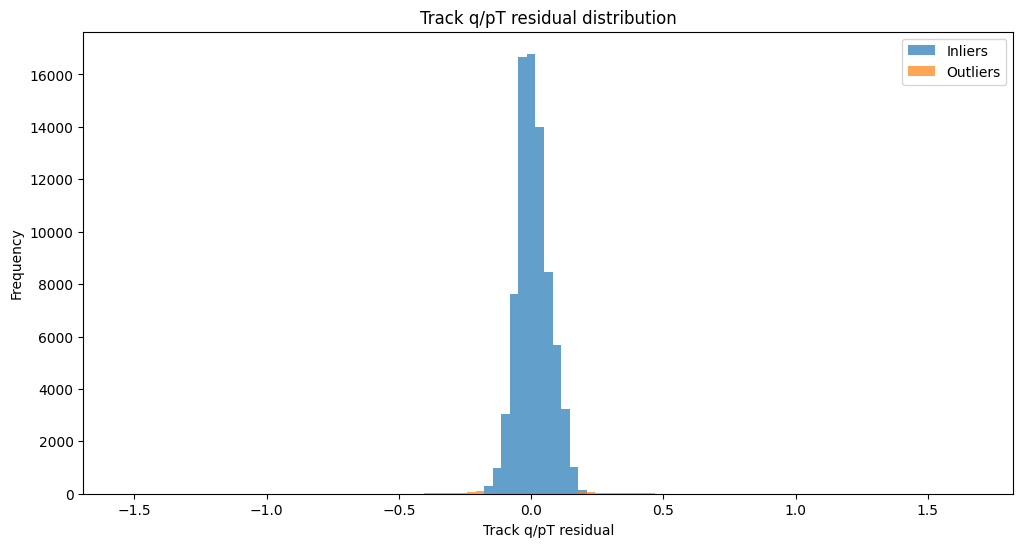

In [ ]:
import numpy as np


def compute_track_resolution(true_values, measured_values, max_iterations=100):
    """
    Compute the resolution of track parameters by iteratively removing outliers beyond 3 standard deviations.

    Parameters:
        true_values (numpy array): Array of true track parameters from simulation.
        measured_values (numpy array): Array of reconstructed track parameters.
        max_iterations (int): Maximum number of iterations to achieve convergence.

    Returns:
        tuple: (Filtered track residuals, removed outliers)
    """
    residuals = np.array(measured_values) - np.array(true_values)
    removed_outliers = np.array([])

    for iteration in range(max_iterations):
        mean_residual = np.mean(residuals)
        std_residual = np.std(residuals)

        # Identify inliers within 3 standard deviations
        inlier_mask = np.abs(residuals - mean_residual) <= 3 * std_residual
        filtered_residuals = residuals[inlier_mask]
        removed_outliers = np.concatenate((removed_outliers, residuals[~inlier_mask]))

        # Check for convergence
        if len(filtered_residuals) == len(residuals):
            break

        residuals = filtered_residuals

    if iteration == max_iterations - 1:
        print(f"Warning: Maximum iterations reached before convergence.")

    return filtered_residuals, removed_outliers

In [11]:
def view_trajectory(inputs, mask=None):
    """
    Plots the trajectory of a particle in 3D.
    """

    if mask is None:
        # Filter out zero rows
        inputs = inputs[(inputs != 0).any(dim=1)]

    else:
        inputs = inputs[mask]

    x = inputs[:, 0].numpy()
    y = inputs[:, 1].numpy()
    z = inputs[:, 2].numpy()

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=x,
                y=y,
                z=z,
                mode="lines+markers",
                marker=dict(size=4, color="blue", opacity=0.8),
                line=dict(color="blue", width=2),
            )
        ]
    )

    fig.update_layout(
        scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
        title="Particle Trajectory",
    )

    fig.show()

In [ ]:
i = 5
view_trajectory(bad_tracks_q[i][1])

In [ ]:
thing = bad_tracks_q[i][1][(bad_tracks_q[i][1] != 0).any(dim=1)][:, :2]

In [ ]:
plt.scatter(thing[:, 0], thing[:, 1])

In [ ]:
from src.my_model.benchmarks import CircleFit


cf = CircleFit()


# f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true{}"
f"circle pred: {cf.fit(thing.unsqueeze(0)).item():5.3f} \t true"

In [ ]:
bad_tracks_q[i][0][1]

In [19]:
def sync_plot_limits():
    # Use the same axis limits for both plots
    left, right = None, None
    bottom, top = None, None

    for i in range(1, 3):
        plt.subplot(1, 2, i)
        left_, right_ = plt.xlim()
        bottom_, top_ = plt.ylim()

        if left is None or left_ < left:
            left = left_
        if right is None or right_ > right:
            right = right_
        if bottom is None or bottom_ < bottom:
            bottom = bottom_
        if top is None or top_ > top:
            top = top_

    # Apply the same limits to the subplots
    for i in range(1, 3):
        plt.subplot(1, 2, i)
        plt.xlim(left, right)
        plt.ylim(bottom, top)

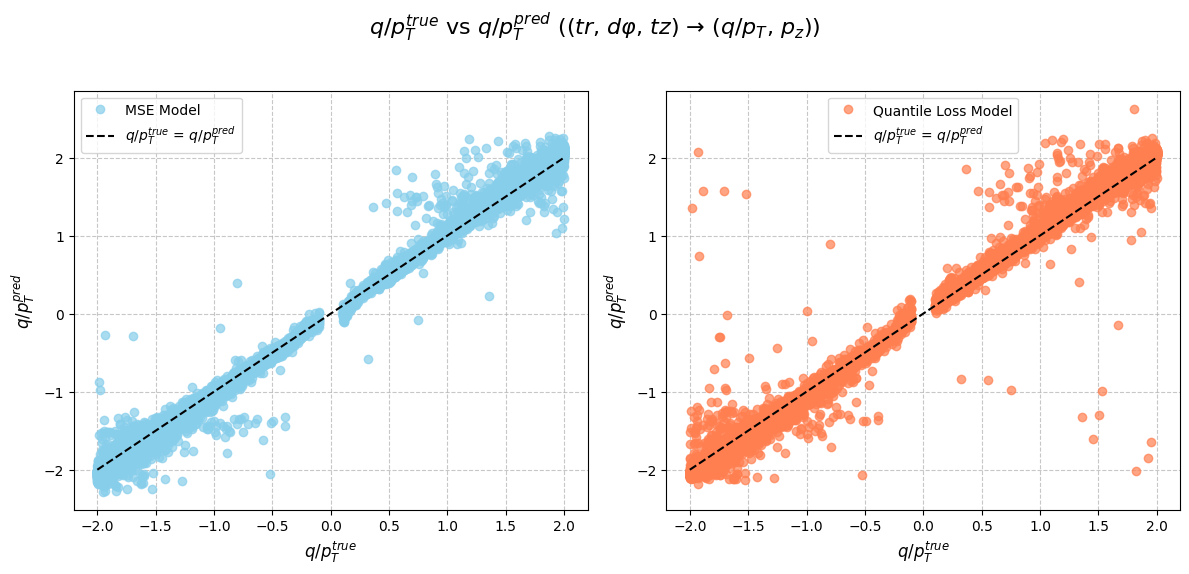

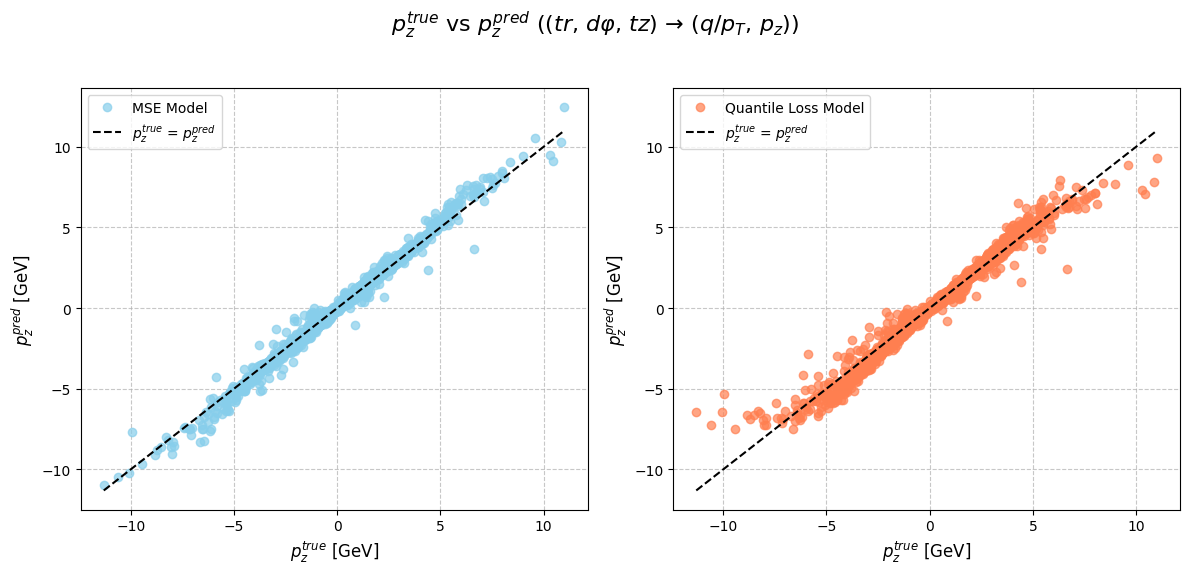

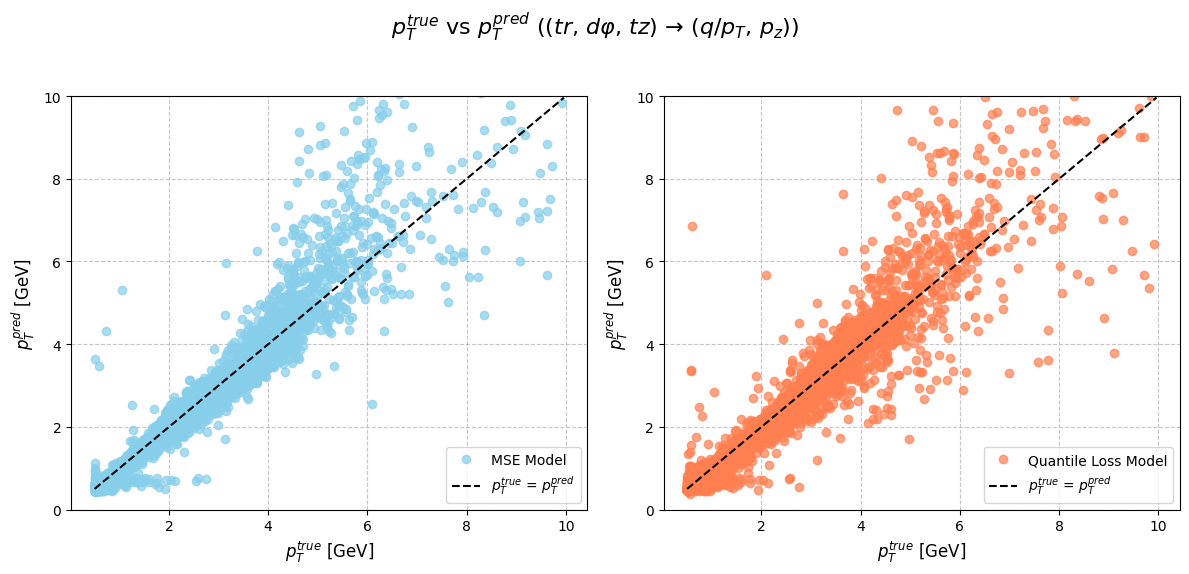

In [20]:
def plot_pi_true_vs_pred(target_labels, low_pt=False):
    for var_index, var in enumerate(target_labels):
        # Get the true values for the current variable.
        pi_true_values = np.array(p_true_list)[:, var_index]
        qopT_to_pT = (var == "p_T" and "qopT" in config["output_variables"]) and config[
            "output_variables"
        ].index("qopT") == var_index
        if qopT_to_pT:
            pi_true_values = 1 / np.abs(pi_true_values)

        title = f"${var}^{{true}}$ vs ${var}^{{pred}}$"
        if low_pt:
            title += " ($p_T$ < 10 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        ylabel = pred_label + (" [GeV]" if var.startswith("p") else "")
        filename = f"{variable_filenames[var]}_true_vs_{variable_filenames[var]}_pred_square.png"
        if low_pt:
            filename = filename.replace(".", "_low_pt.")
        filename = output_dir / filename

        if low_pt:
            assert any(v in config["output_variables"] for v in ["pT", "qopT"])
            if "pT" in config["output_variables"]:
                pt_true = np.array(p_true_list)[
                    :, config["output_variables"].index("pT")
                ]
            elif "qopT" in config["output_variables"]:
                qopt_true = np.array(p_true_list)[
                    :, config["output_variables"].index("qopT")
                ]
                pt_true = 1 / np.abs(qopt_true)

            # Select only events with p_T < 10 GeV.
            mask = pt_true < 10

            # Apply the pT mask.
            pi_true_values = pi_true_values[mask]

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        min_pi_true = min(pi_true_values)
        max_pi_true = max(pi_true_values)

        # Loop over each model.
        for model_index, model_info in enumerate(models.values(), start=1):
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if qopT_to_pT:
                pi_pred_values = 1 / np.abs(pi_pred_values)

            if low_pt:
                # Apply the same pT mask.
                pi_pred_values = pi_pred_values[mask]

            plt.subplot(1, len(models), model_index)
            plt.plot(
                pi_true_values,
                pi_pred_values,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=f"{model_info['color']}",
                marker="o",
                linestyle="None",
            )

            # Add x = y line
            plt.plot(
                [min_pi_true, max_pi_true],
                [min_pi_true, max_pi_true],
                color="black",
                linestyle="--",
                label=f"{true_label} = {pred_label}",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()
            if qopT_to_pT:
                plt.ylim(0, 10)

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_true_vs_pred(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_true_vs_pred(target_labels=["p_T"])

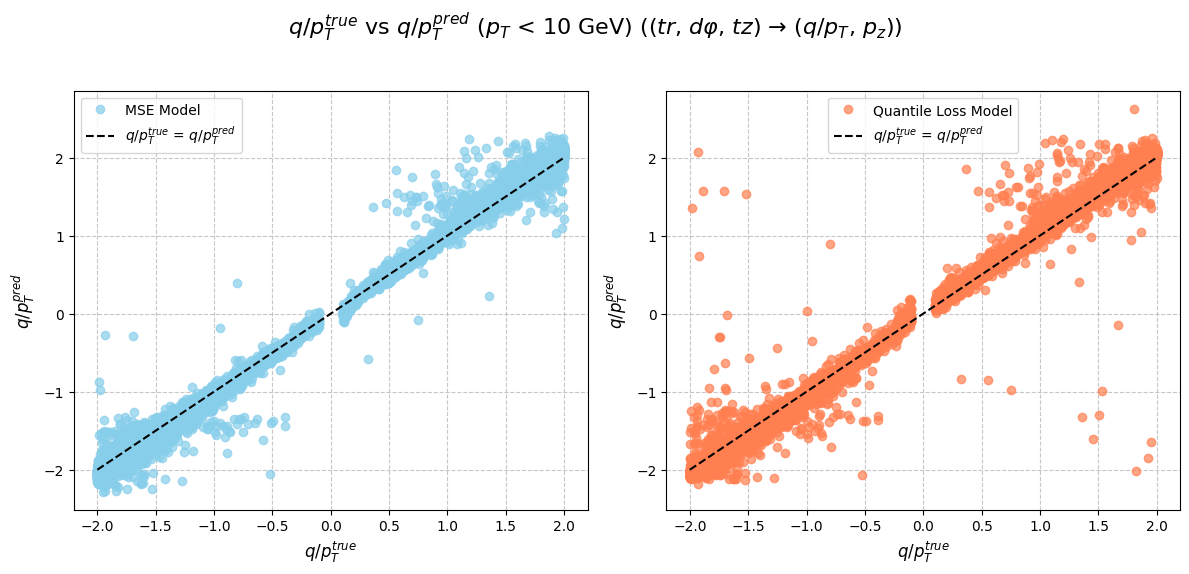

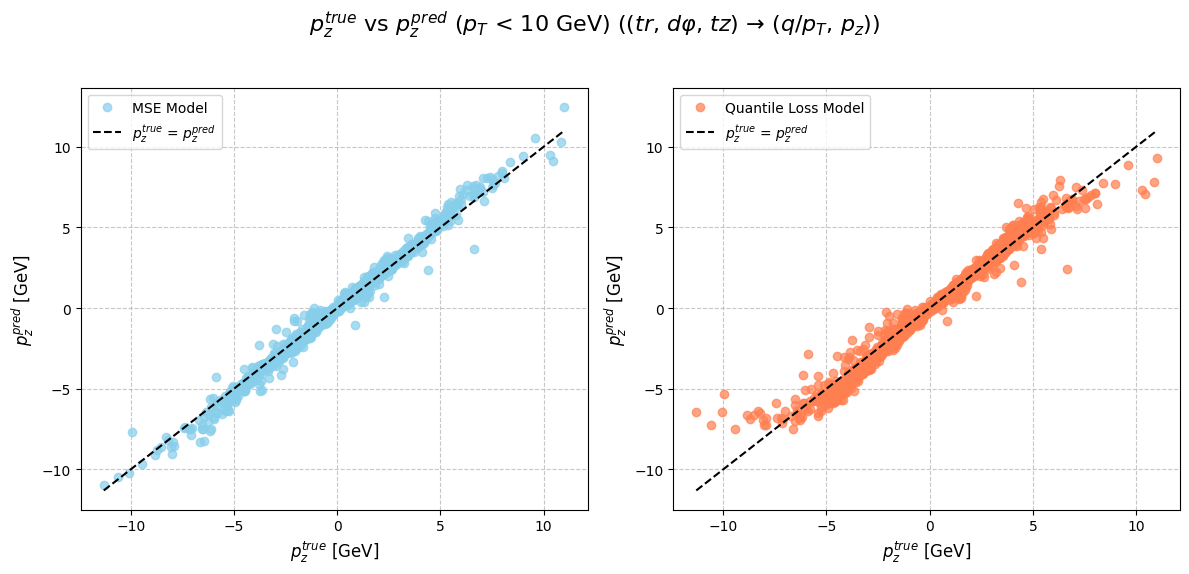

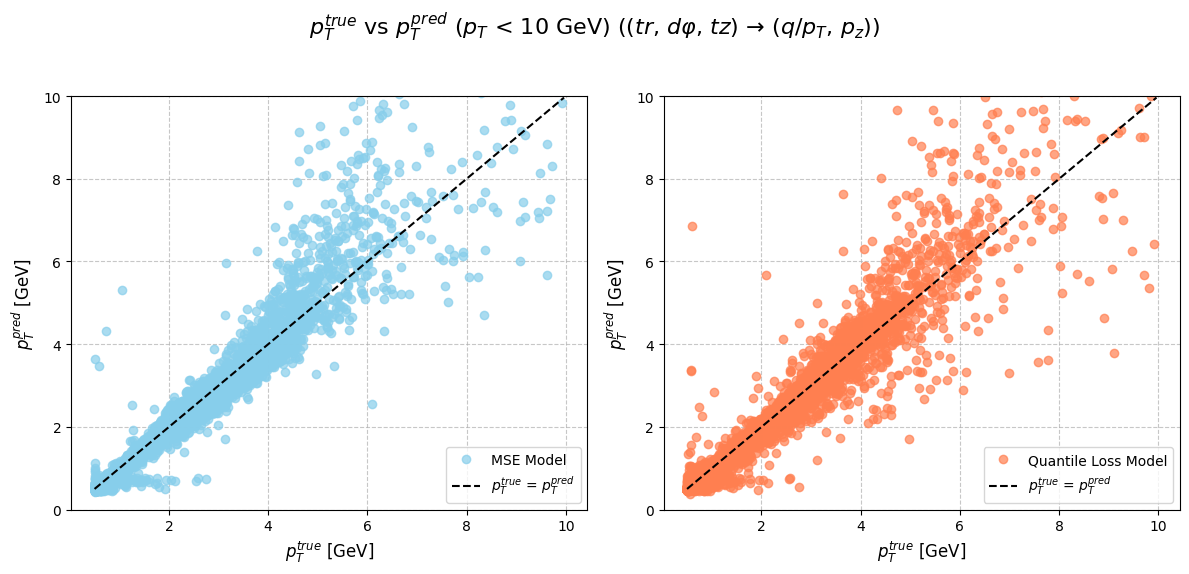

In [21]:
plot_pi_true_vs_pred(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    low_pt=True,
)
if config["output_variables"][0] == "qopT":
    plot_pi_true_vs_pred(target_labels=["p_T"], low_pt=True)

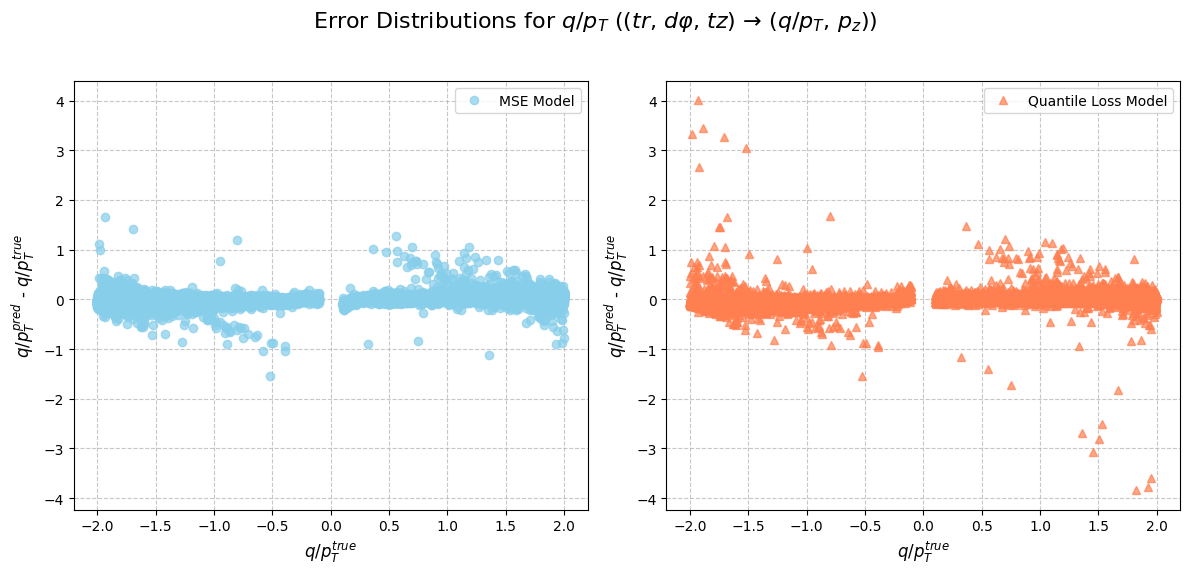

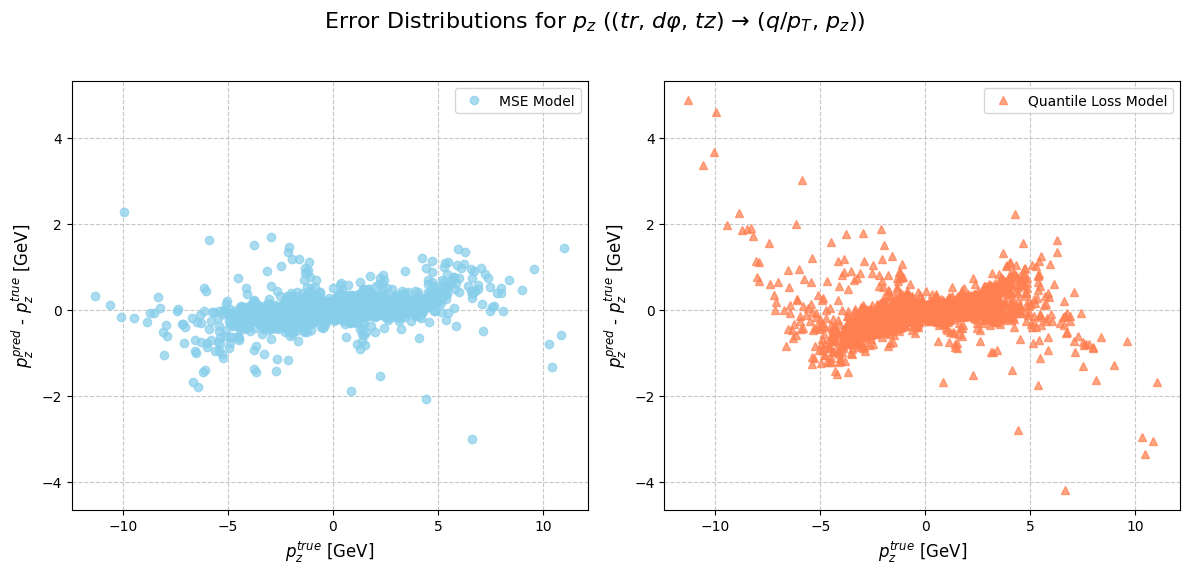

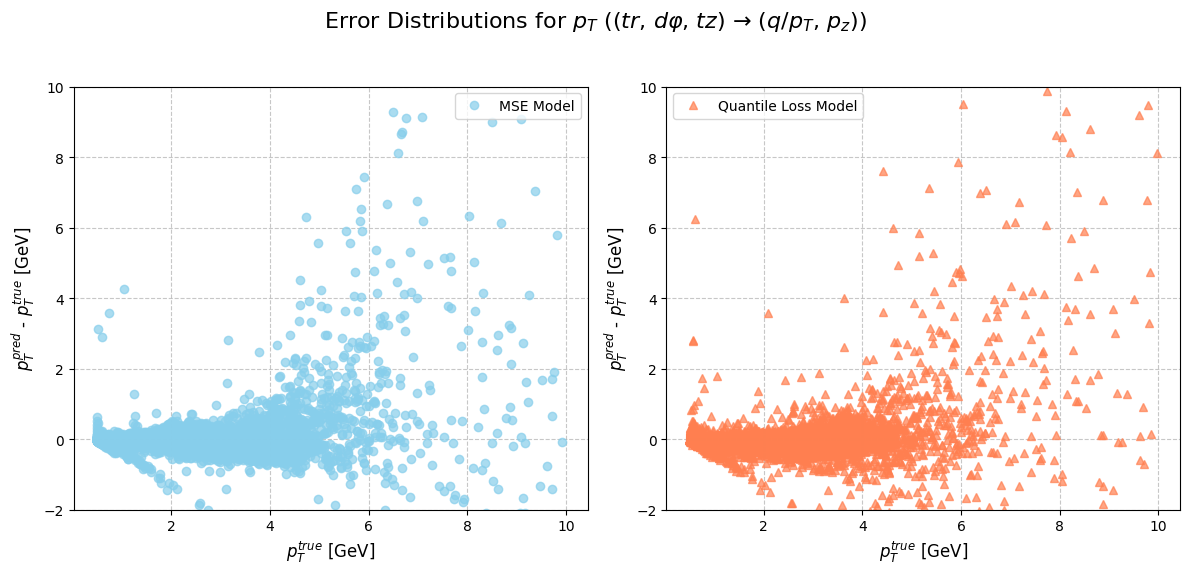

In [22]:
def plot_pi_error_distributions(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        title = f"Error Distributions for ${var}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        ylabel = f"{pred_label} - {true_label}" + (
            " [GeV]" if var.startswith("p") else ""
        )
        filename = f"error_distributions_{variable_filenames[var]}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # Loop over each model.
        for model_index, model_info in enumerate(models.values(), start=1):
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            errors = pi_pred_values - pi_true_values

            plt.subplot(1, len(models), model_index)
            plt.plot(
                pi_true_values,
                errors,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()
            if var == "p_T" and config["output_variables"][0] == "qopT":
                plt.ylim(-2, 10)

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_error_distributions(target_labels=["p_T"])

/tmp/ipykernel_102638/2764684698.py:28: RuntimeWarning: invalid value encountered in log10
  np.log10(min(pi_true_values)), np.log10(max(pi_true_values)), 15
/tmp/ipykernel_102638/2764684698.py:30: RuntimeWarning: invalid value encountered in log10
  bins = np.logspace(np.log10(min(pi_true_values)), np.log10(50), 10)
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: inv

[ 0  1  2  4  6  8 10]


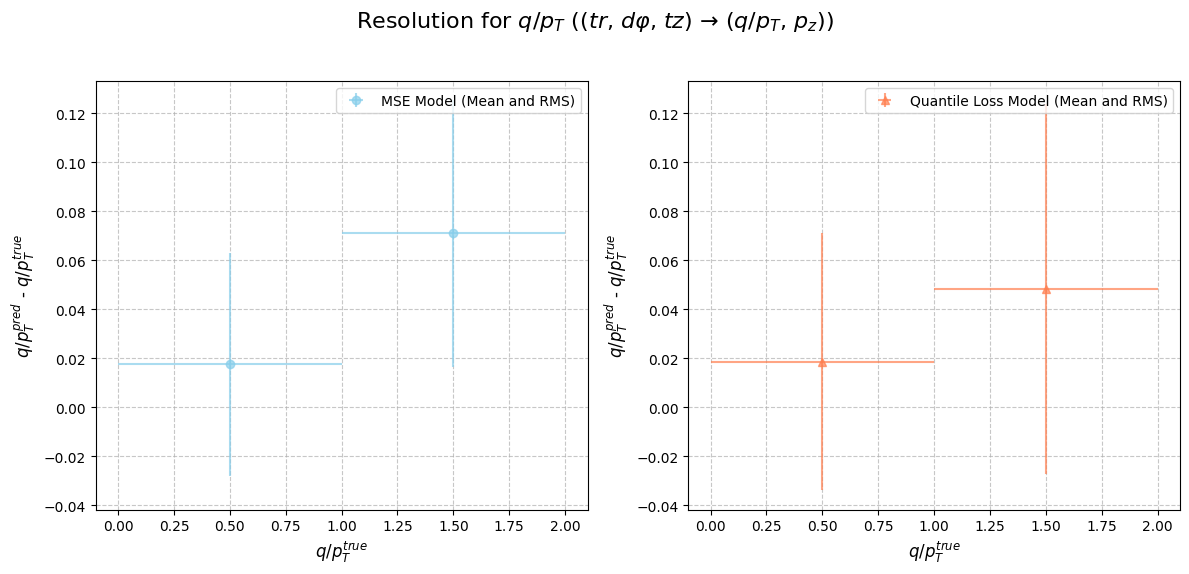

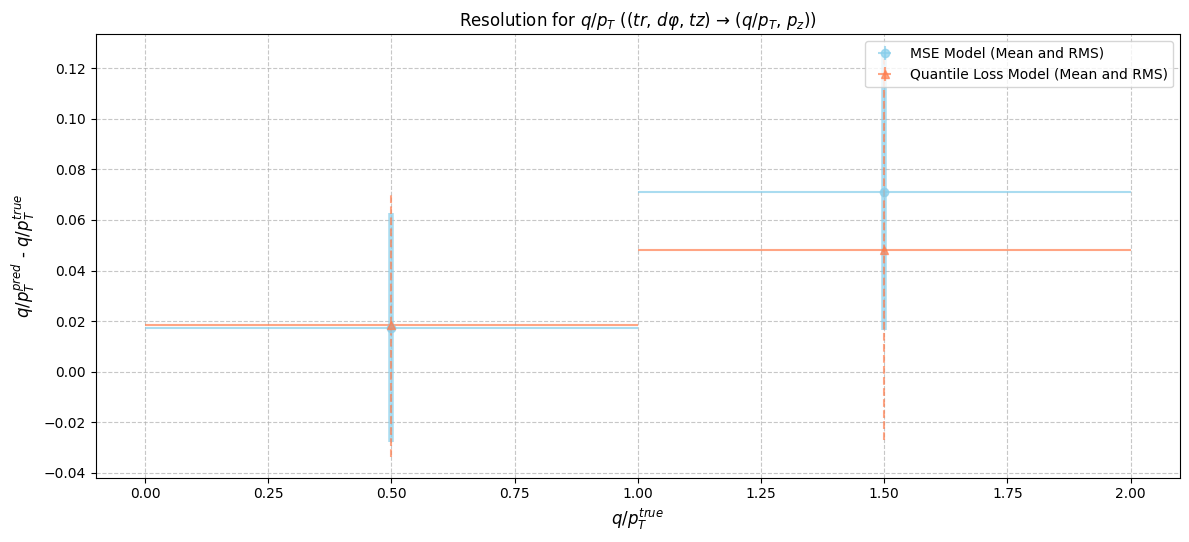

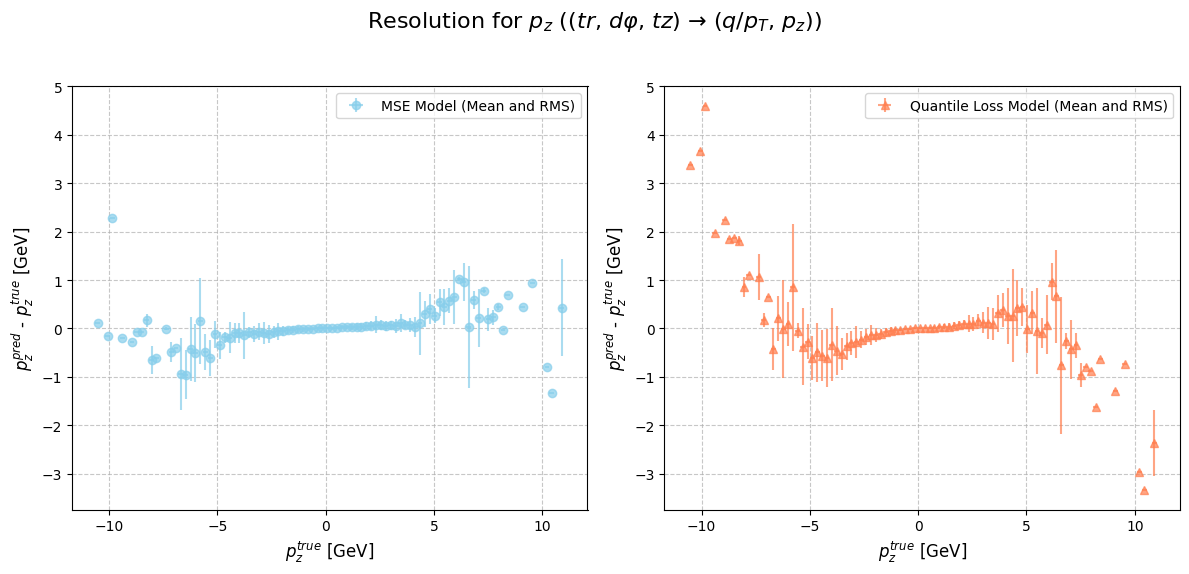

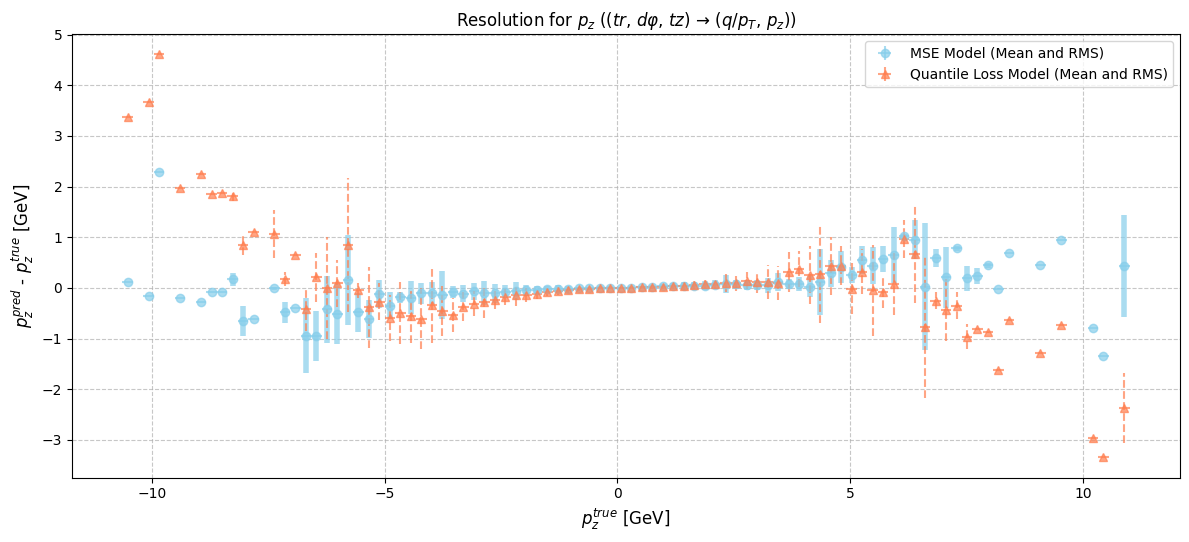

[ 0  1  2  4  6  8 10]


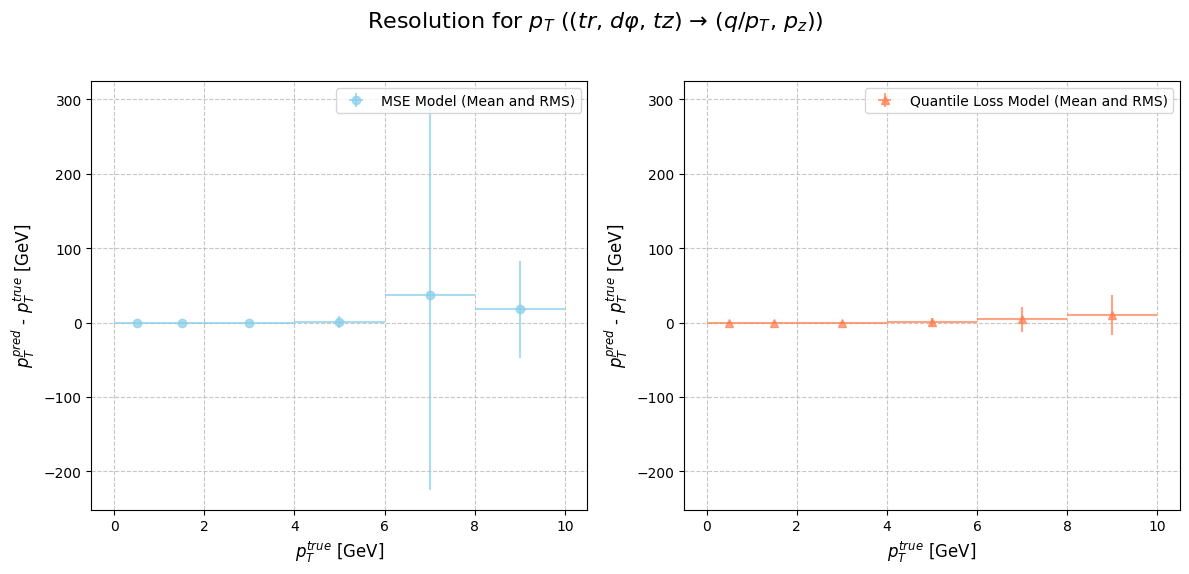

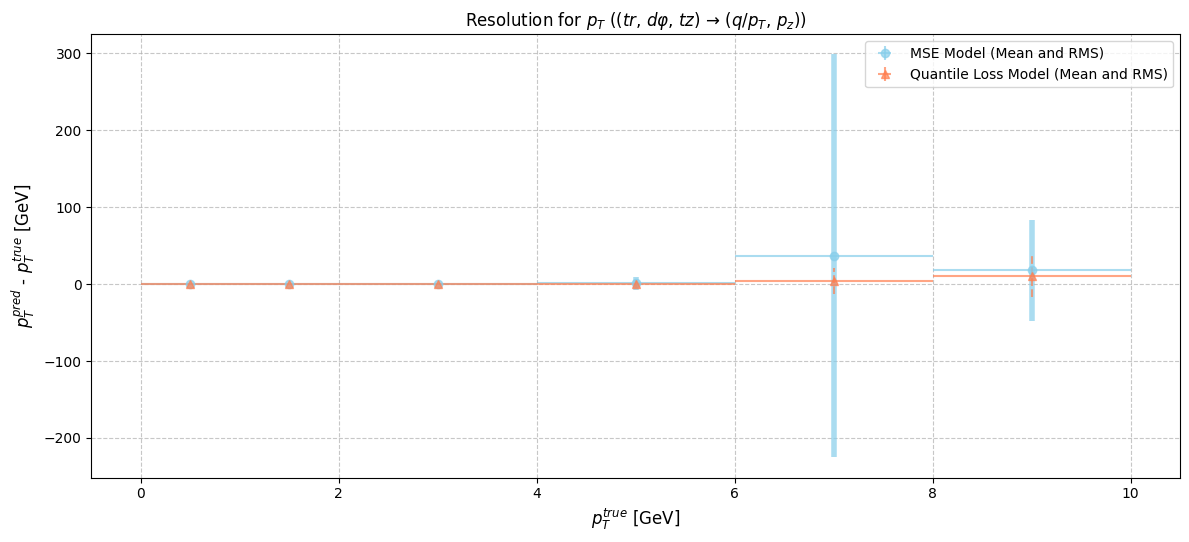

In [23]:
def plot_pi_resolutions(target_labels, pruning=False):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        title = f"Resolution for ${var}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        ylabel = f"{pred_label} - {true_label}" + (
            " [GeV]" if var.startswith("p") else ""
        )
        filename = f"resolution_{variable_filenames[var]}.png"
        if pruning:
            filename = filename.replace(".", "_pruning.")
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(min(pi_true_values), max(pi_true_values), 100)
        if var_index == 0:
            bins = np.logspace(
                np.log10(min(pi_true_values)), np.log10(max(pi_true_values)), 15
            )
            bins = np.logspace(np.log10(min(pi_true_values)), np.log10(50), 10)
            bins = np.array([0, 1, 2, 4, 6, 8, 12, 16, 20, 24, 28, 34, 40, 50])
            bins = np.array([0, 1, 2, 4, 6, 8, 10])
            print(bins)

        # Loop over each model.
        model_data = {}
        for model_name, model_info in models.items():
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            errors = pi_pred_values - pi_true_values
            model_data[model_name] = errors

        # Loop over each model.
        model_bins = {}
        for bin_index in range(len(bins)):
            if bin_index == 0:
                lower_bound = -np.inf
                continue
            else:
                lower_bound = bins[bin_index - 1]
            upper_bound = bins[bin_index]

            sel = (lower_bound < pi_true_values) & (pi_true_values <= upper_bound)
            for model_name, model_info in models.items():
                if not pruning:
                    errors_bin = model_data[model_name][sel]
                    model_bin_mean, model_bin_std = np.mean(errors_bin), np.std(errors_bin)
                else:
                    pi_pred_values = np.array(model_info["data_list"])[:, var_index]
                    if config["output_variables"][0] == "qopT" and var == "p_T":
                        pi_pred_values = 1 / np.abs(pi_pred_values)

                    errors_bin_pruned, removed_outliers_bin = compute_track_resolution(
                        pi_true_values[sel], pi_pred_values[sel]
                    )

                    if len(pi_true_values[sel]) == 0:
                        outlier_ratio = np.inf
                    else:
                        outlier_ratio = len(removed_outliers_bin) / len(pi_true_values[sel])

                    print(f"Fraction of tracks identified as outliers by model {model_name}: {outlier_ratio:.4%} for bin {(lower_bound, upper_bound)}")

                    model_bin_mean, model_bin_std = np.mean(errors_bin_pruned), np.std(errors_bin_pruned)


                model_bins.setdefault(model_name, []).append(
                    (model_bin_mean, model_bin_std)
                )

        bin_centers = (bins[1:] + bins[:-1]) / 2

        # Loop over each model.
        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            bin_counts = np.array(model_bins[model_name])[..., 0]
            bin_std = np.array(model_bins[model_name])[..., 1]

            plt.subplot(1, len(models), model_index)

            plt.errorbar(
                bin_centers,
                bin_counts,
                yerr=bin_std,
                xerr=(bins[1:] - bins[:-1]) / 2,
                alpha=0.7,
                label=f"{model_info['label']} Model (Mean and RMS)",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()

        # One figure
        filename = f"resolution_{variable_filenames[var]}_one_plot.png"
        if pruning:
            filename = filename.replace(".", "_pruning.")
        filename = output_dir / filename
        bin_sizes = bins[1:] - bins[:-1]
        plt.figure(figsize=(12, 6))

        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            bin_counts = np.array(model_bins[model_name])[..., 0]
            bin_std = np.array(model_bins[model_name])[..., 1]
            if model_index == 1:
                xerr = (bins[1:] - bins[:-1]) / 2
                x = bin_centers
            elif model_index == 2:
                shift = bin_sizes * 0.0
                xerr_low = bin_sizes / 2 + shift
                xerr_high = bin_sizes / 2 - shift
                xerr_high[xerr_high < 0] = 0
                xerr = [xerr_low, xerr_high]
                x = bin_centers + shift

            errorbar_obj = plt.errorbar(
                x,
                bin_counts,
                yerr=bin_std,
                xerr=xerr,
                alpha=0.7,
                label=f"{model_info['label']} Model (Mean and RMS)",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            if model_index == 1:
                errorbar_obj[-1][1].set_linewidth(
                    4
                )  # errorbar_obj[-1][0] is the LineCollection objects of the errorbar lines
            elif model_index == 2:
                # Use dashed lines for y error bars
                # https://stackoverflow.com/questions/22995797/can-matplotlib-errorbars-have-a-linestyle-set
                errorbar_obj[-1][1].set_linestyle(
                    "--"
                )  # errorbar_obj[-1][0] is the LineCollection objects of the errorbar lines

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title(title)
        # Specify in the legend that vertical error bars are rms of the distribution
        plt.legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_resolutions(target_labels=["p_T"])

/tmp/ipykernel_102638/2764684698.py:28: RuntimeWarning: invalid value encountered in log10
  np.log10(min(pi_true_values)), np.log10(max(pi_true_values)), 15
/tmp/ipykernel_102638/2764684698.py:30: RuntimeWarning: invalid value encountered in log10
  bins = np.logspace(np.log10(min(pi_true_values)), np.log10(50), 10)


[ 0  1  2  4  6  8 10]
Fraction of tracks identified as outliers by model MSE: 3.1172% for bin (0, 1)
Fraction of tracks identified as outliers by model QLoss: 3.2633% for bin (0, 1)
Fraction of tracks identified as outliers by model MSE: 1.7324% for bin (1, 2)
Fraction of tracks identified as outliers by model QLoss: 2.2631% for bin (1, 2)
Fraction of tracks identified as outliers by model MSE: inf% for bin (2, 4)
Fraction of tracks identified as outliers by model QLoss: inf% for bin (2, 4)
Fraction of tracks identified as outliers by model MSE: inf% for bin (4, 6)
Fraction of tracks identified as outliers by model QLoss: inf% for bin (4, 6)
Fraction of tracks identified as outliers by model MSE: inf% for bin (6, 8)
Fraction of tracks identified as outliers by model QLoss: inf% for bin (6, 8)
Fraction of tracks identified as outliers by model MSE: inf% for bin (8, 10)
Fraction of tracks identified as outliers by model QLoss: inf% for bin (8, 10)


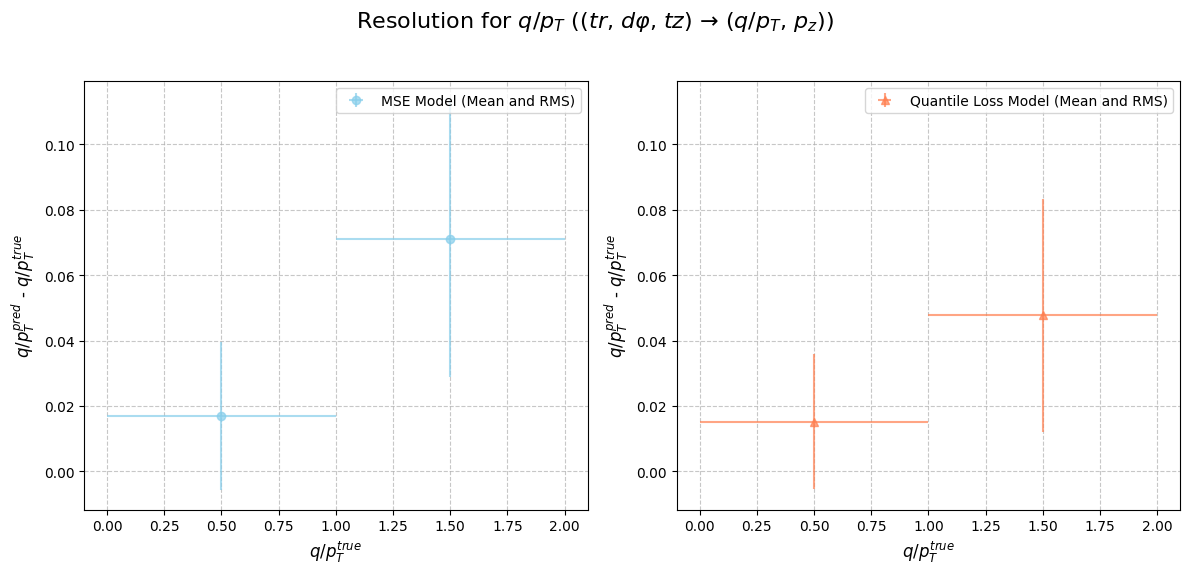

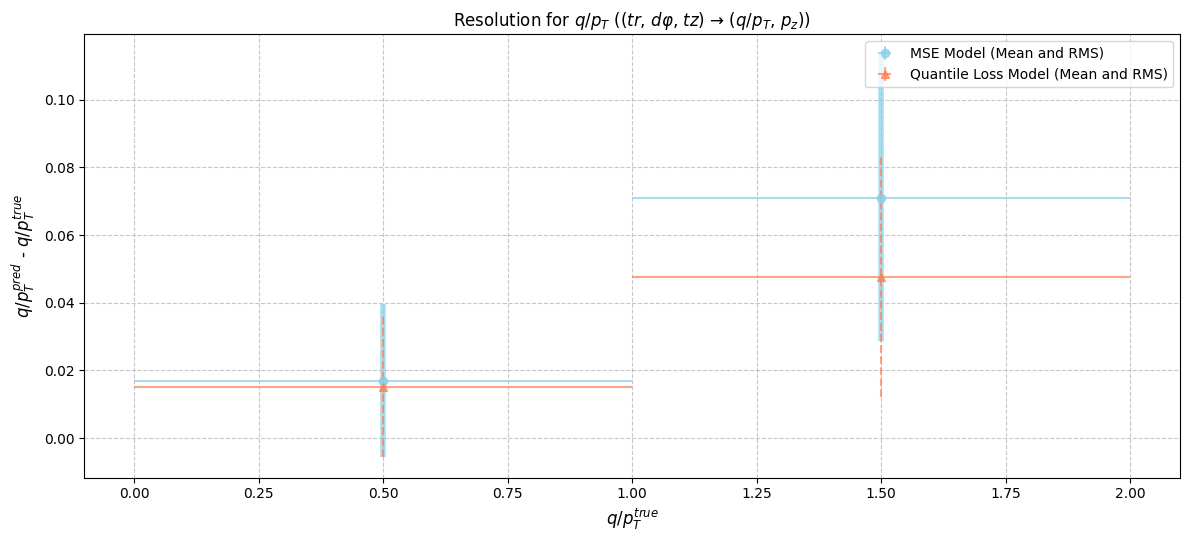

Fraction of tracks identified as outliers by model MSE: inf% for bin (-11.307600021362305, -11.082214162807272)
Fraction of tracks identified as outliers by model QLoss: inf% for bin (-11.307600021362305, -11.082214162807272)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-11.082214162807272, -10.85682830425224)
Fraction of tracks identified as outliers by model QLoss: inf% for bin (-11.082214162807272, -10.85682830425224)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-10.85682830425224, -10.631442445697207)
Fraction of tracks identified as outliers by model QLoss: inf% for bin (-10.85682830425224, -10.631442445697207)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-10.631442445697207, -10.406056587142174)
Fraction of tracks identified as outliers by model QLoss: 0.0000% for bin (-10.631442445697207, -10.406056587142174)
Fraction of tracks identified as outliers by model MSE: inf% for bin (-10.406056587142174, -10

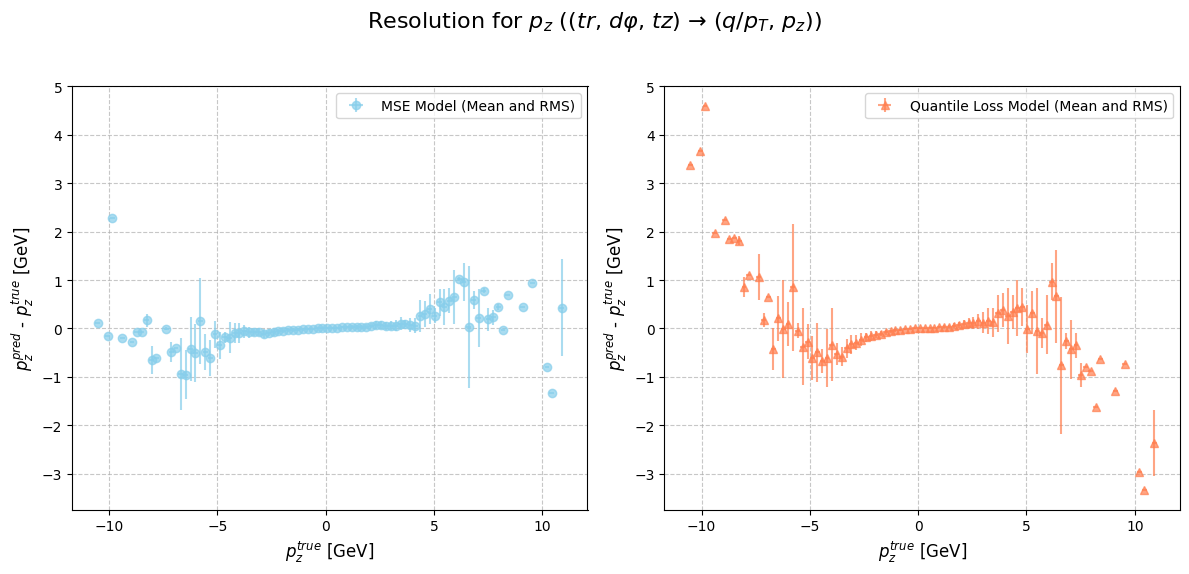

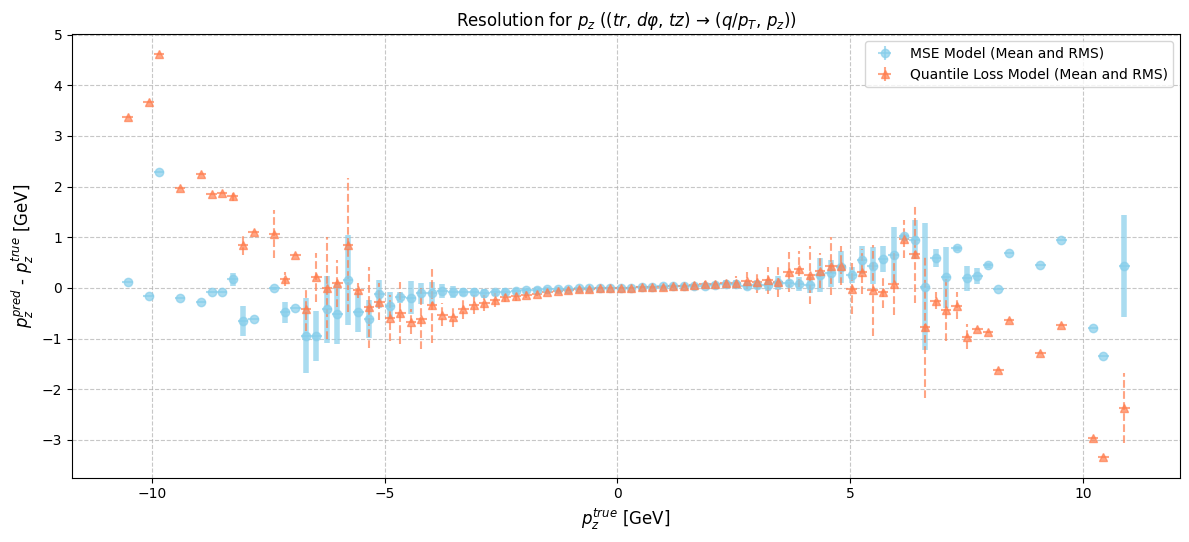

[ 0  1  2  4  6  8 10]
Fraction of tracks identified as outliers by model MSE: 2.7387% for bin (0, 1)
Fraction of tracks identified as outliers by model QLoss: 3.3955% for bin (0, 1)
Fraction of tracks identified as outliers by model MSE: 4.6764% for bin (1, 2)
Fraction of tracks identified as outliers by model QLoss: 3.3670% for bin (1, 2)
Fraction of tracks identified as outliers by model MSE: 2.9456% for bin (2, 4)
Fraction of tracks identified as outliers by model QLoss: 6.7085% for bin (2, 4)
Fraction of tracks identified as outliers by model MSE: 6.3683% for bin (4, 6)
Fraction of tracks identified as outliers by model QLoss: 8.2616% for bin (4, 6)
Fraction of tracks identified as outliers by model MSE: 15.4930% for bin (6, 8)
Fraction of tracks identified as outliers by model QLoss: 9.1549% for bin (6, 8)
Fraction of tracks identified as outliers by model MSE: 15.5844% for bin (8, 10)
Fraction of tracks identified as outliers by model QLoss: 10.3896% for bin (8, 10)


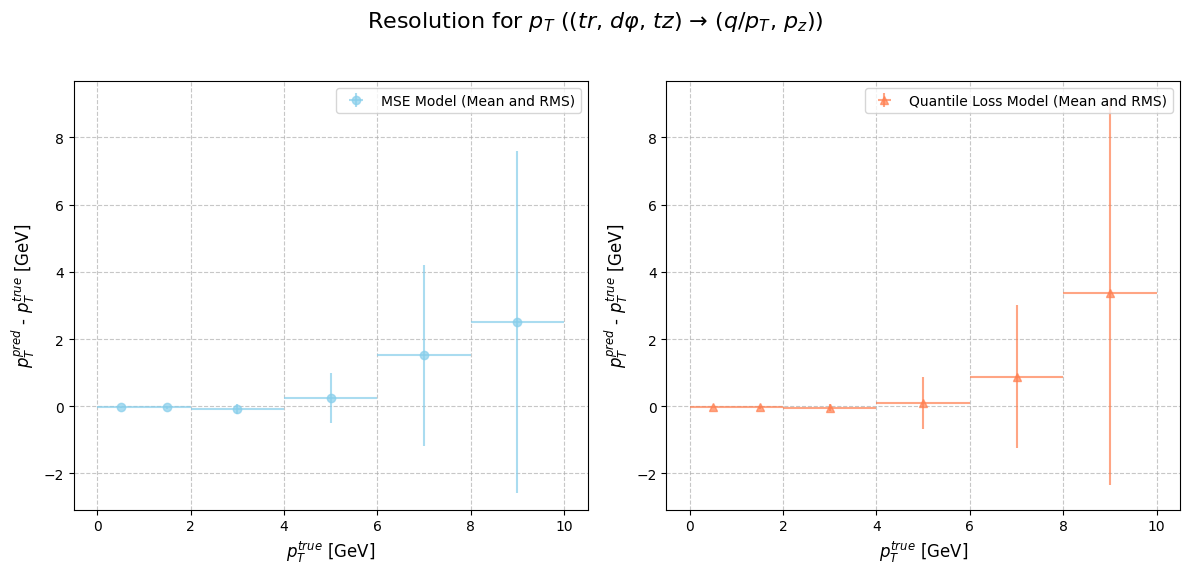

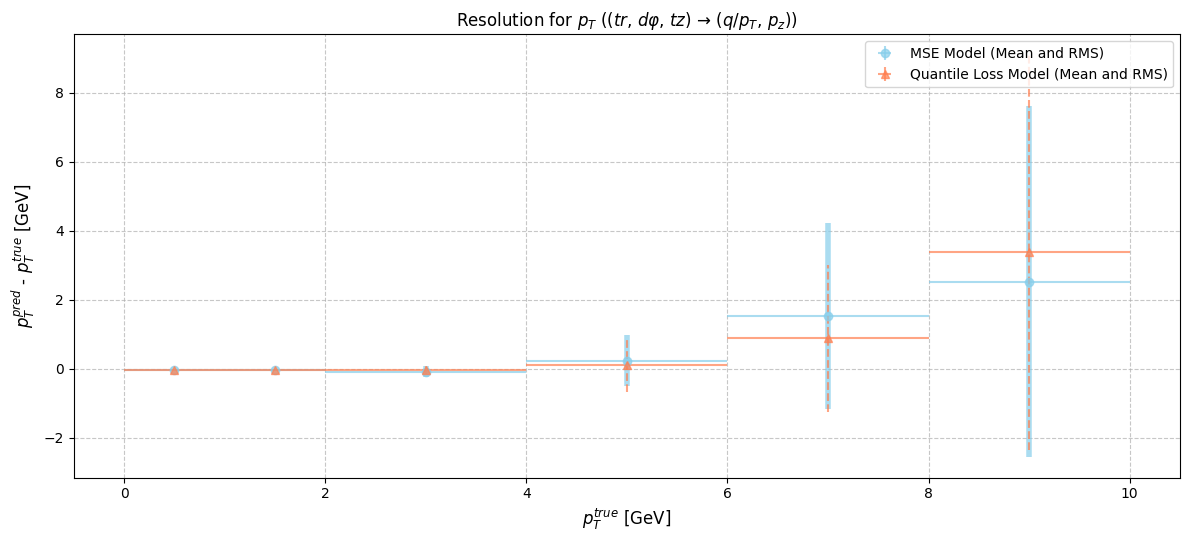

In [24]:
plot_pi_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    pruning=True,
)
if config["output_variables"][0] == "qopT":
    plot_pi_resolutions(target_labels=["p_T"], pruning=True)

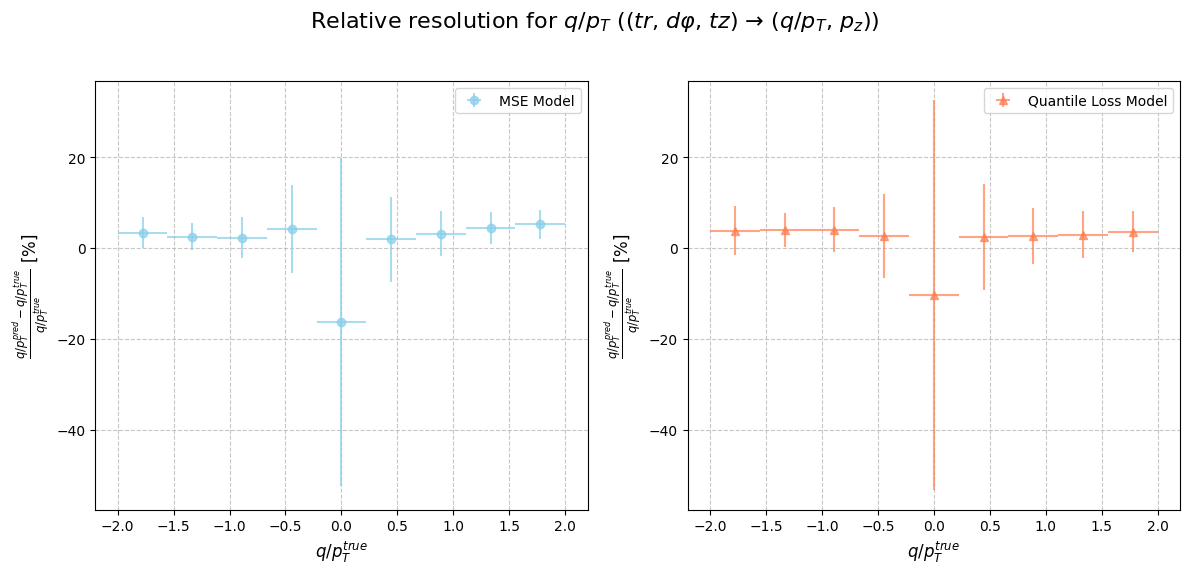

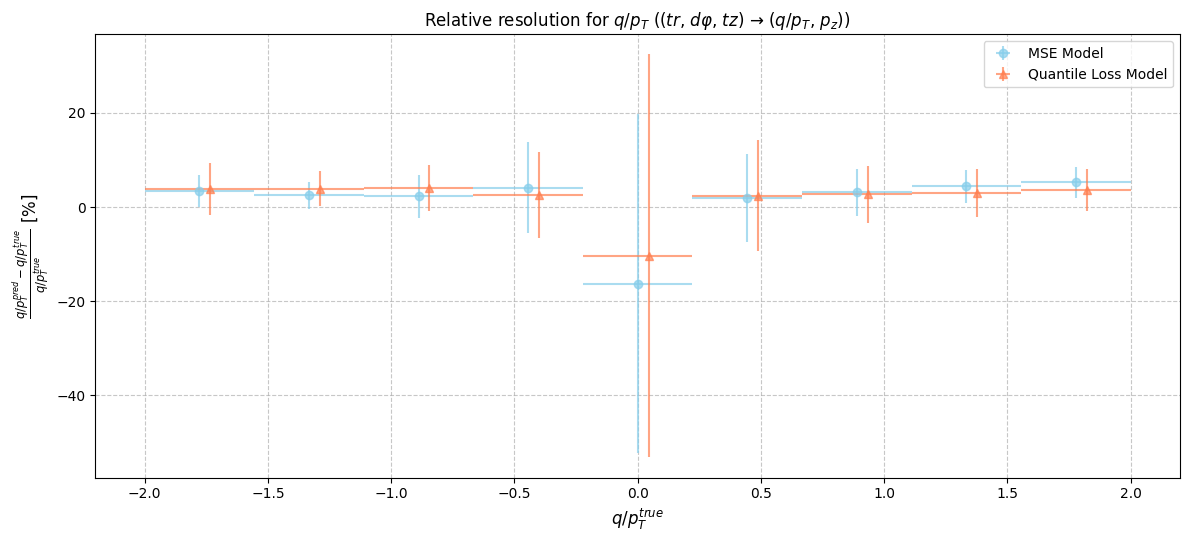

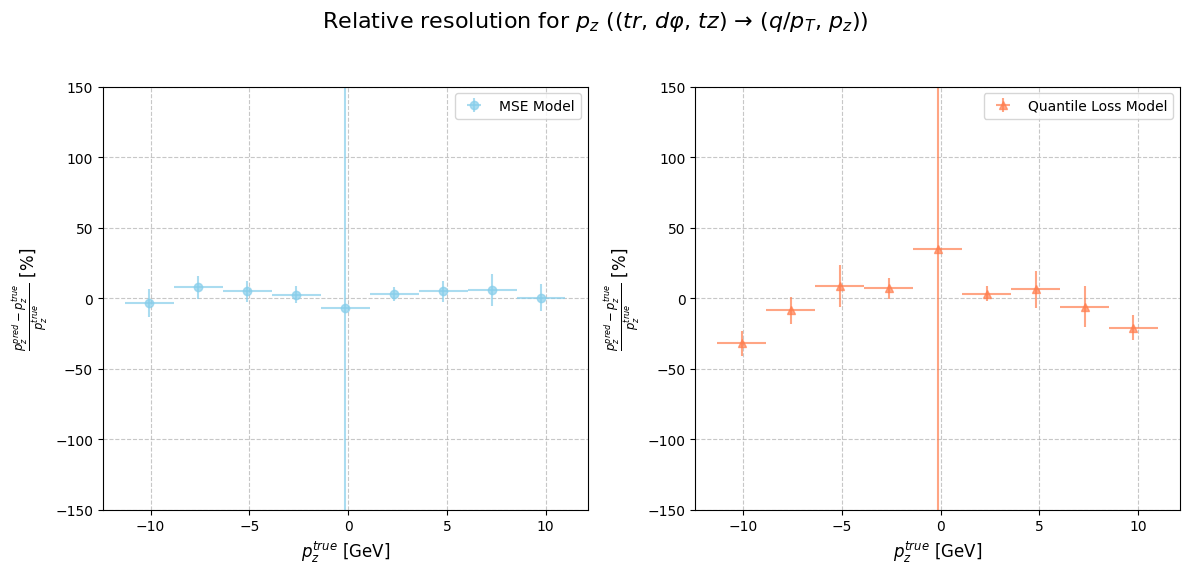

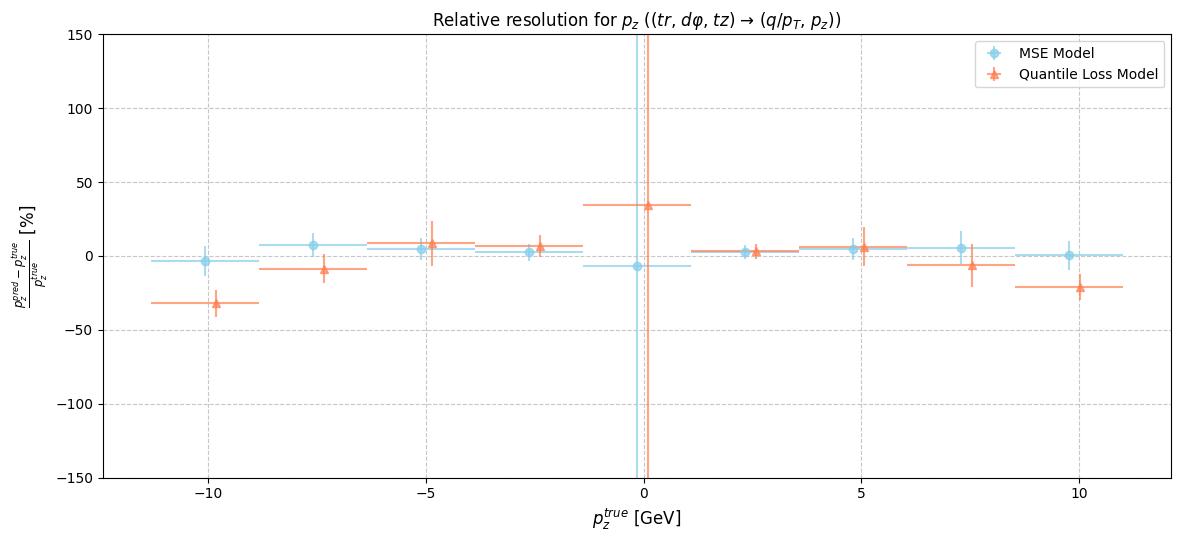

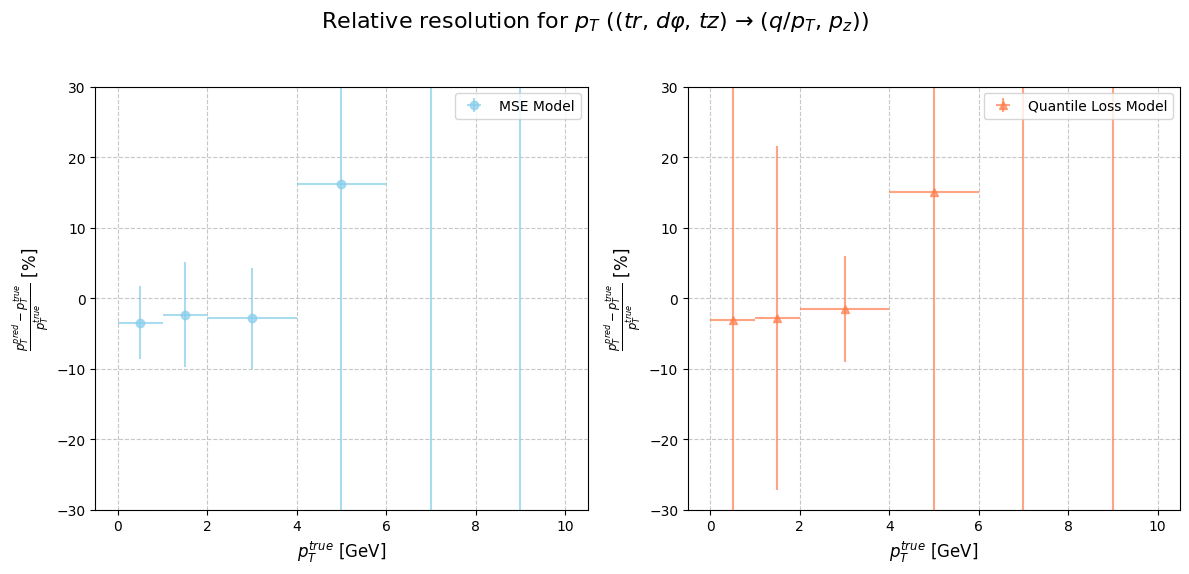

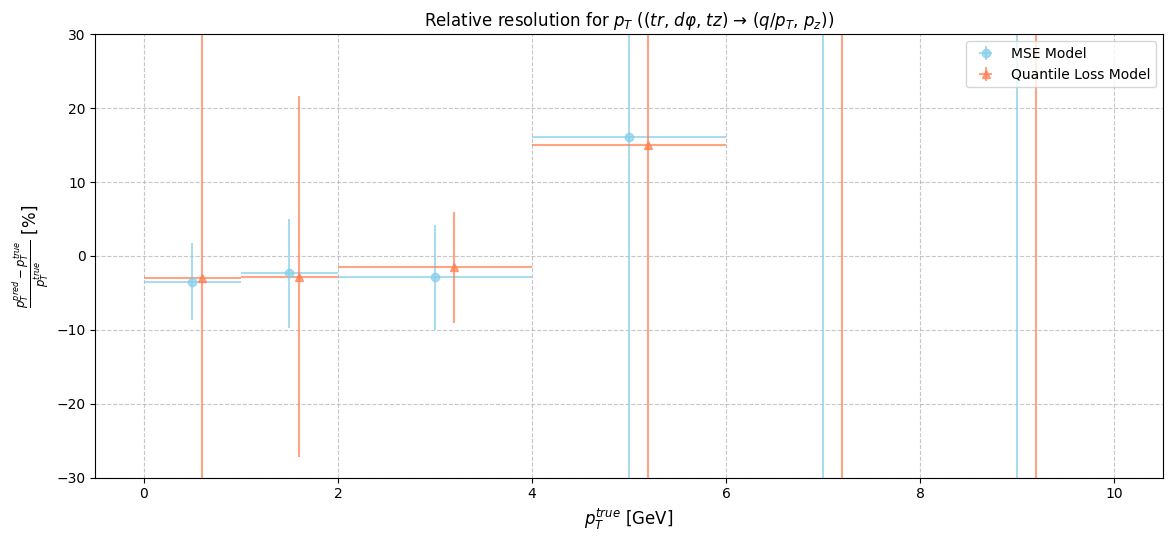

In [25]:
def plot_pi_rel_resolutions(target_labels, pruning=False, low_pt=False):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        title = f"Relative resolution for ${var}$"
        if low_pt:
            title += " ($p_T$ < 10 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        ylabel = (
            r"$\frac{"
            + f"{pred_label} - {true_label}".replace("$", "")
            + "}{"
            + f"{true_label}".replace("$", "")
            + "}$"
            + " [%]"
        )
        filename = f"rel_resolution_{variable_filenames[var]}.png"
        if low_pt:
            filename = filename.replace(".", "_low_pt.")
        if pruning:
            filename = filename.replace(".", "_pruning.")
        filename = output_dir / filename

        if low_pt:
            assert any(v in config["output_variables"] for v in ["pT", "qopT"])
            if "pT" in config["output_variables"]:
                pt_true = np.array(p_true_list)[
                    :, config["output_variables"].index("pT")
                ]
            elif "qopT" in config["output_variables"]:
                qopt_true = np.array(p_true_list)[
                    :, config["output_variables"].index("qopT")
                ]
                pt_true = 1 / np.abs(qopt_true)

            # Select only events with p_T < 10 GeV.
            mask = pt_true < 10

            # Apply the pT mask.
            pi_true_values = pi_true_values[mask]

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(min(pi_true_values), max(pi_true_values), 10)
        if var == "p_T":
            bins = np.logspace(
                np.log10(min(pi_true_values)), np.log10(max(pi_true_values)), 15
            )
            bins = np.logspace(np.log10(min(pi_true_values)), np.log10(50), 10)
            bins = np.array([0, 1, 2, 4, 6, 8, 12, 16, 20, 24, 28, 34, 40, 50])
            bins = np.array([0, 1, 2, 4, 6, 8, 10])
            # print(bins)

        # Loop over each model.
        model_data = {}
        for model_name, model_info in models.items():
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            if low_pt:
                # Apply the same pT mask.
                pi_pred_values = pi_pred_values[mask]

            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values

            # Make it percentage
            relative_errors_per = 100 * relative_errors
            model_data[model_name] = relative_errors_per

        # Loop over each model.
        model_bins = {}
        for bin_index in range(len(bins)):
            if bin_index == 0:
                lower_bound = -np.inf
                continue
            else:
                lower_bound = bins[bin_index - 1]
            upper_bound = bins[bin_index]

            sel = (lower_bound < pi_true_values) & (pi_true_values <= upper_bound)
            for model_name, model_info in models.items():
                if not pruning:
                    relative_errors_bin = model_data[model_name][sel]
                    model_bin_mean, model_bin_std = np.mean(relative_errors_bin), np.std(
                        relative_errors_bin
                    )
                else:
                    pi_pred_values = np.array(model_info["data_list"])[:, var_index]
                    if config["output_variables"][0] == "qopT" and var == "p_T":
                        pi_pred_values = 1 / np.abs(pi_pred_values)

                    if low_pt:
                        # Apply the same pT mask.
                        pi_pred_values = pi_pred_values[mask]

                    relative_errors_bin_pruned, removed_outliers_bin = compute_track_resolution(
                        (pi_true_values[sel] / pi_true_values[sel]),
                        pi_pred_values[sel] / pi_true_values[sel],
                    )
                    # Make it percentage
                    relative_errors_bin_pruned = 100 * relative_errors_bin_pruned

                    if len(pi_true_values[sel]) == 0:
                        outlier_ratio = np.inf
                    else:
                        outlier_ratio = len(removed_outliers_bin) / len(pi_true_values[sel])

                    print(f"Fraction of tracks identified as outliers by model {model_name}: {outlier_ratio:.4%} for bin {(lower_bound, upper_bound)}")

                    model_bin_mean, model_bin_std = np.mean(
                        relative_errors_bin_pruned
                    ), np.std(relative_errors_bin_pruned)

                model_bins.setdefault(model_name, []).append(
                    (model_bin_mean, model_bin_std)
                )

        bin_centers = (bins[1:] + bins[:-1]) / 2

        # Loop over each model.
        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            bin_counts = np.array(model_bins[model_name])[..., 0]
            bin_std = np.array(model_bins[model_name])[..., 1]

            plt.subplot(1, len(models), model_index)

            plt.errorbar(
                bin_centers,
                bin_counts,
                yerr=bin_std,
                xerr=(bins[1:] - bins[:-1]) / 2,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()
            if var == "p_T":
                if config["output_variables"][0] == "qopT":
                    plt.ylim(-30, 30)
                else:
                    plt.ylim(-10, 10)
            if var == "p_z" and not pruning:
                plt.ylim(-1.5 * 100, 1.5 * 100)

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()

        # One figure
        filename = f"rel_resolution_{variable_filenames[var]}_one_plot.png"
        if low_pt:
            filename = filename.replace(".", "_low_pt.")
        if pruning:
            filename = filename.replace(".", "_pruning.")
        filename = output_dir / filename
        bin_sizes = bin_sizes = bins[1:] - bins[:-1]
        plt.figure(figsize=(12, 6))

        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            bin_counts = np.array(model_bins[model_name])[..., 0]
            bin_std = np.array(model_bins[model_name])[..., 1]
            if model_index == 1:
                xerr = (bins[1:] - bins[:-1]) / 2
                x = bin_centers
            elif model_index == 2:
                shift = bin_sizes * 0.1
                xerr_low = bin_sizes / 2 + shift
                xerr_high = bin_sizes / 2 - shift
                xerr_high[xerr_high < 0] = 0
                xerr = [xerr_low, xerr_high]
                x = bin_centers + shift

            plt.errorbar(
                x,
                bin_counts,
                yerr=bin_std,
                xerr=xerr,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        plt.title(title)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        if var == "p_T":
            if config["output_variables"][0] == "qopT":
                plt.ylim(-30, 30)
            else:
                plt.ylim(-10, 10)
        if var == "p_z":
            plt.ylim(-1.5 * 100, 1.5 * 100)
            if pruning:
                plt.ylim(-20, 20)
        # if var == "p_T":
        #     plt.xscale("log")
        #     # plt.yscale("log")
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_rel_resolutions(target_labels=["p_T"])

Fraction of tracks identified as outliers by model MSE: 3.3388% for bin (-1.9999938011169434, -1.5555542310078938)
Fraction of tracks identified as outliers by model QLoss: 3.0187% for bin (-1.9999938011169434, -1.5555542310078938)
Fraction of tracks identified as outliers by model MSE: 2.9622% for bin (-1.5555542310078938, -1.1111146608988443)
Fraction of tracks identified as outliers by model QLoss: 2.7013% for bin (-1.5555542310078938, -1.1111146608988443)
Fraction of tracks identified as outliers by model MSE: 2.6008% for bin (-1.1111146608988443, -0.6666750907897949)
Fraction of tracks identified as outliers by model QLoss: 2.6583% for bin (-1.1111146608988443, -0.6666750907897949)
Fraction of tracks identified as outliers by model MSE: 2.8938% for bin (-0.6666750907897949, -0.22223552068074537)
Fraction of tracks identified as outliers by model QLoss: 4.5053% for bin (-0.6666750907897949, -0.22223552068074537)
Fraction of tracks identified as outliers by model MSE: 6.6308% for bi

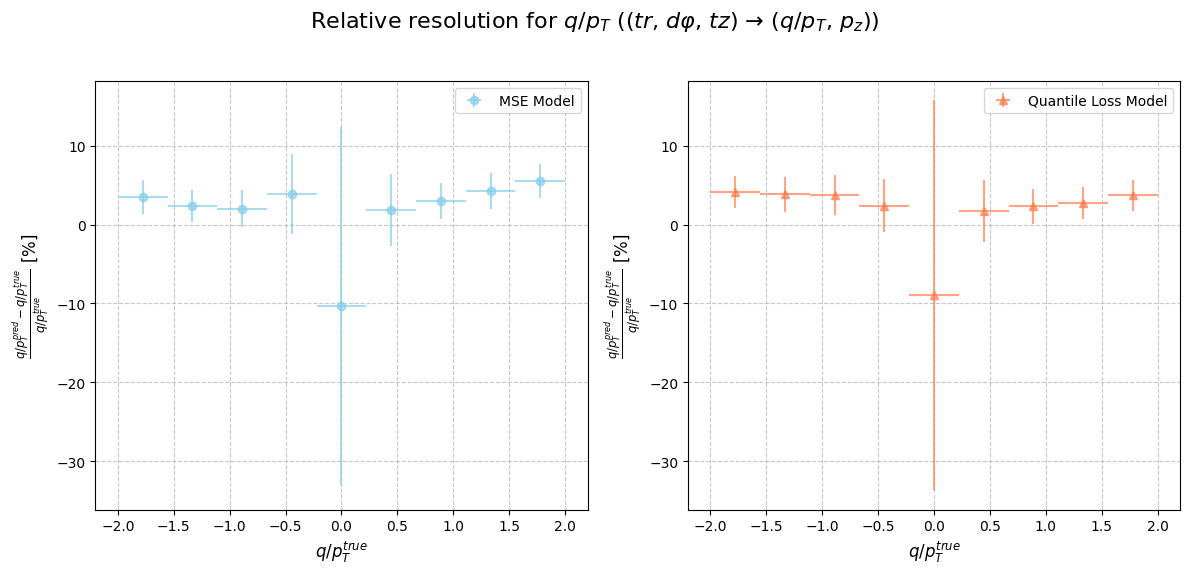

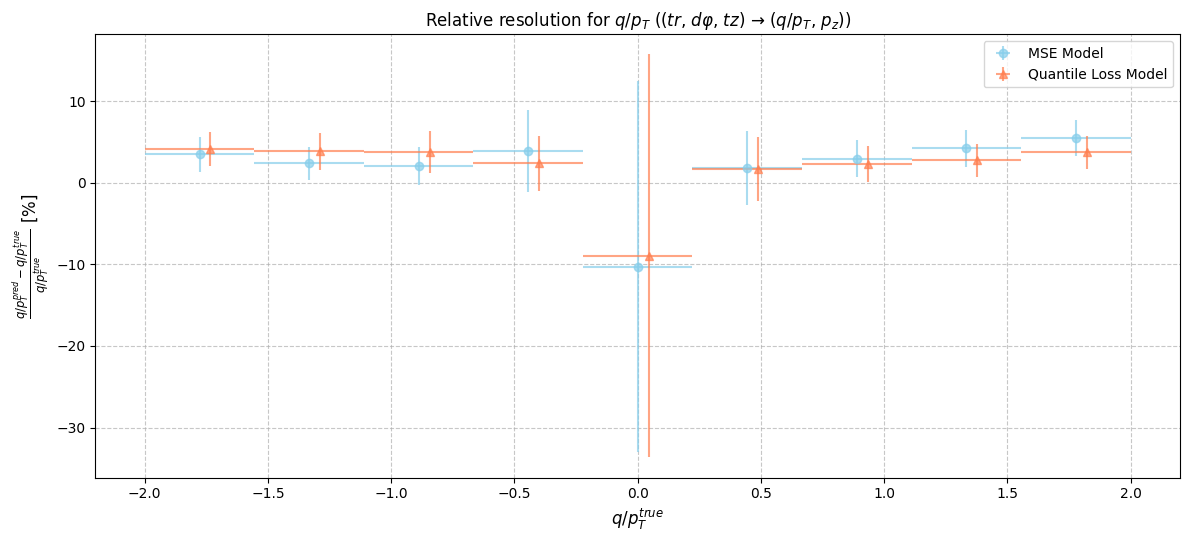

Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-11.307600021362305, -8.828355577256945)
Fraction of tracks identified as outliers by model QLoss: 0.0000% for bin (-11.307600021362305, -8.828355577256945)
Fraction of tracks identified as outliers by model MSE: 0.0000% for bin (-8.828355577256945, -6.349111133151585)
Fraction of tracks identified as outliers by model QLoss: 0.0000% for bin (-8.828355577256945, -6.349111133151585)
Fraction of tracks identified as outliers by model MSE: 1.7699% for bin (-6.349111133151585, -3.8698666890462246)
Fraction of tracks identified as outliers by model QLoss: 4.4248% for bin (-6.349111133151585, -3.8698666890462246)
Fraction of tracks identified as outliers by model MSE: 4.2658% for bin (-3.8698666890462246, -1.3906222449408645)
Fraction of tracks identified as outliers by model QLoss: 5.7424% for bin (-3.8698666890462246, -1.3906222449408645)
Fraction of tracks identified as outliers by model MSE: 14.1249% for bin (-1.390

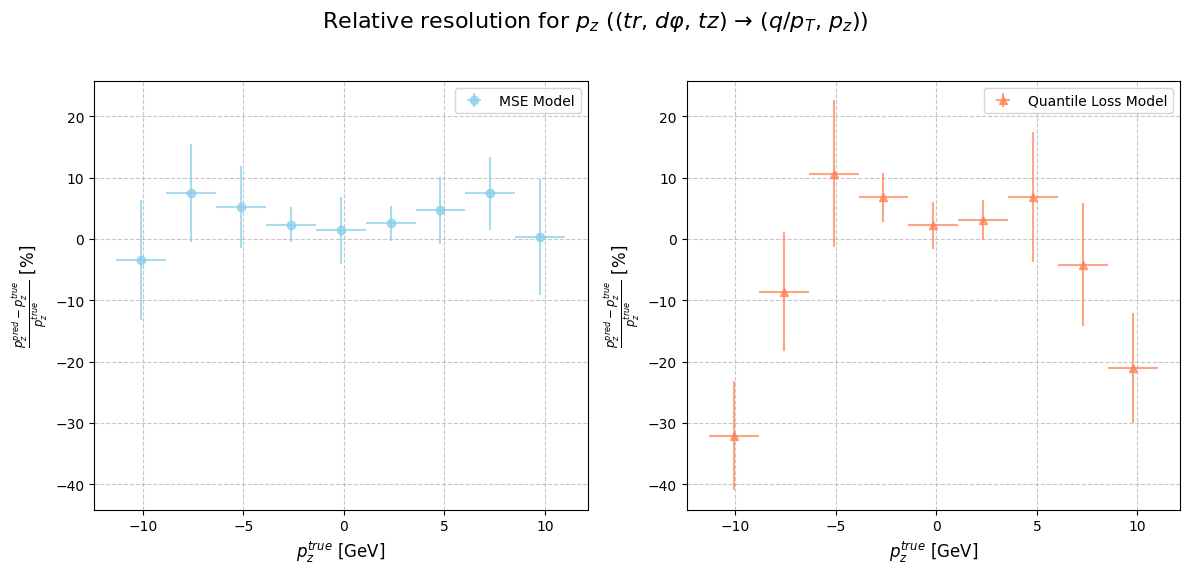

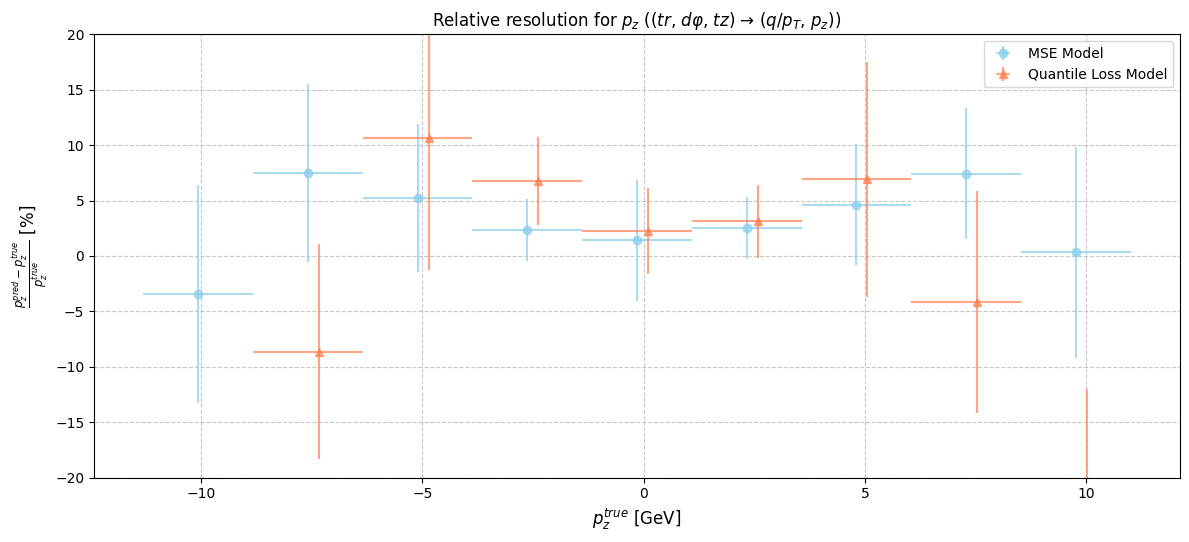

Fraction of tracks identified as outliers by model MSE: 2.2187% for bin (0, 1)
Fraction of tracks identified as outliers by model QLoss: 2.6527% for bin (0, 1)
Fraction of tracks identified as outliers by model MSE: 3.2267% for bin (1, 2)
Fraction of tracks identified as outliers by model QLoss: 2.8994% for bin (1, 2)
Fraction of tracks identified as outliers by model MSE: 2.4325% for bin (2, 4)
Fraction of tracks identified as outliers by model QLoss: 5.2071% for bin (2, 4)
Fraction of tracks identified as outliers by model MSE: 4.8193% for bin (4, 6)
Fraction of tracks identified as outliers by model QLoss: 5.1635% for bin (4, 6)
Fraction of tracks identified as outliers by model MSE: 15.4930% for bin (6, 8)
Fraction of tracks identified as outliers by model QLoss: 10.5634% for bin (6, 8)
Fraction of tracks identified as outliers by model MSE: 15.5844% for bin (8, 10)
Fraction of tracks identified as outliers by model QLoss: 10.3896% for bin (8, 10)


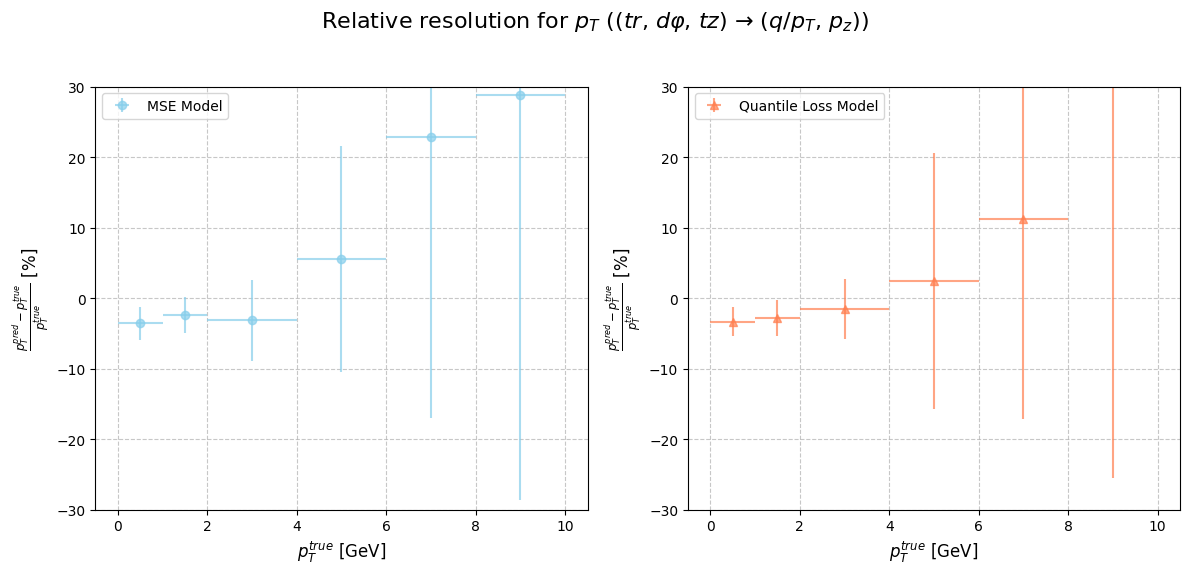

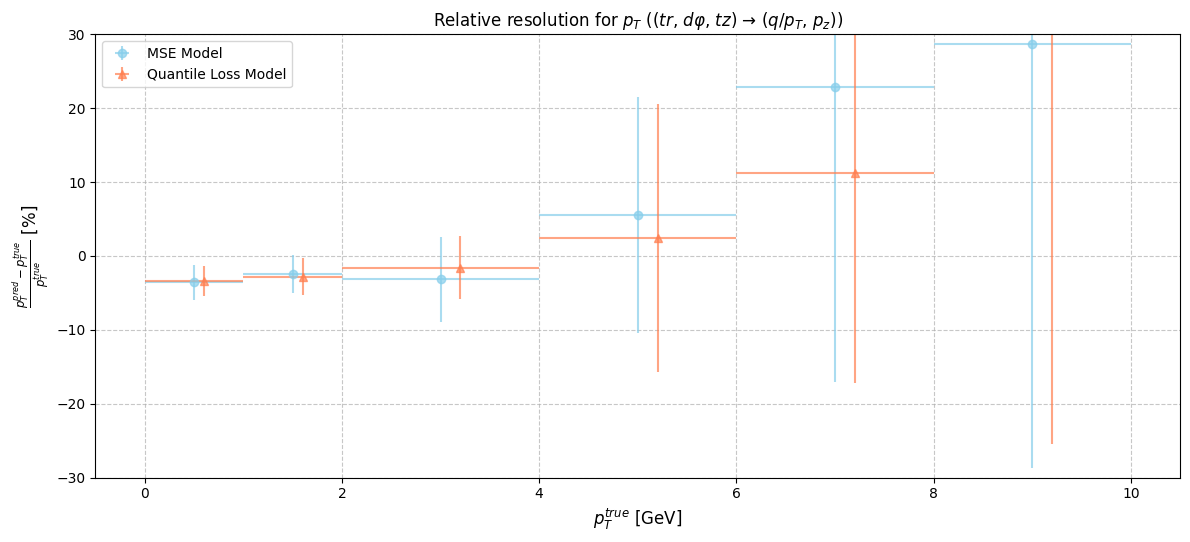

In [26]:
plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    pruning=True,
)
if config["output_variables"][0] == "qopT":
    plot_pi_rel_resolutions(target_labels=["p_T"], pruning=True)

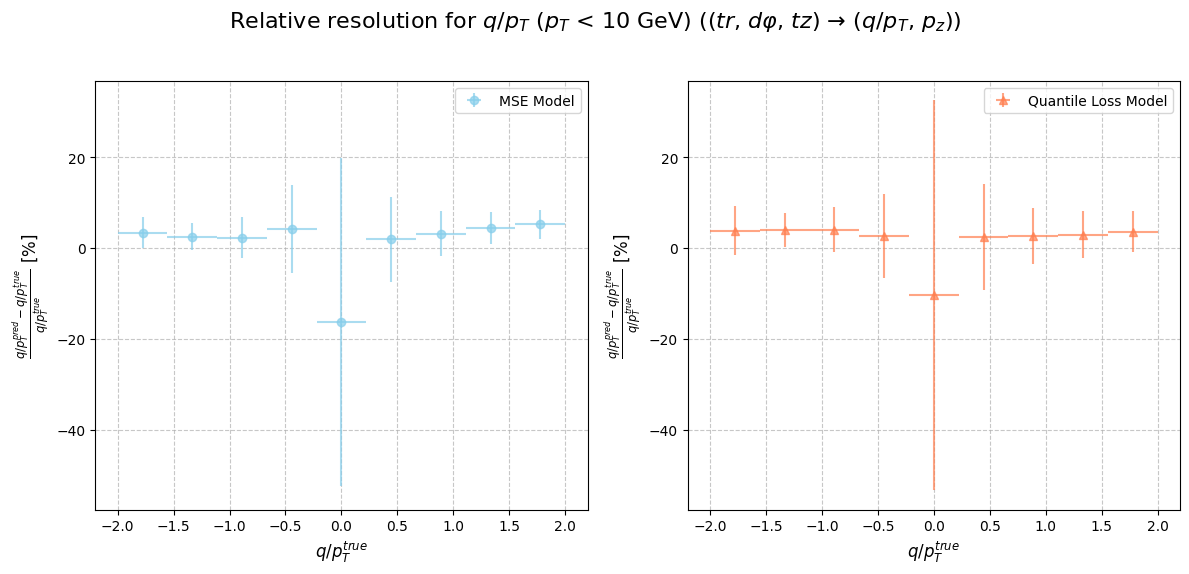

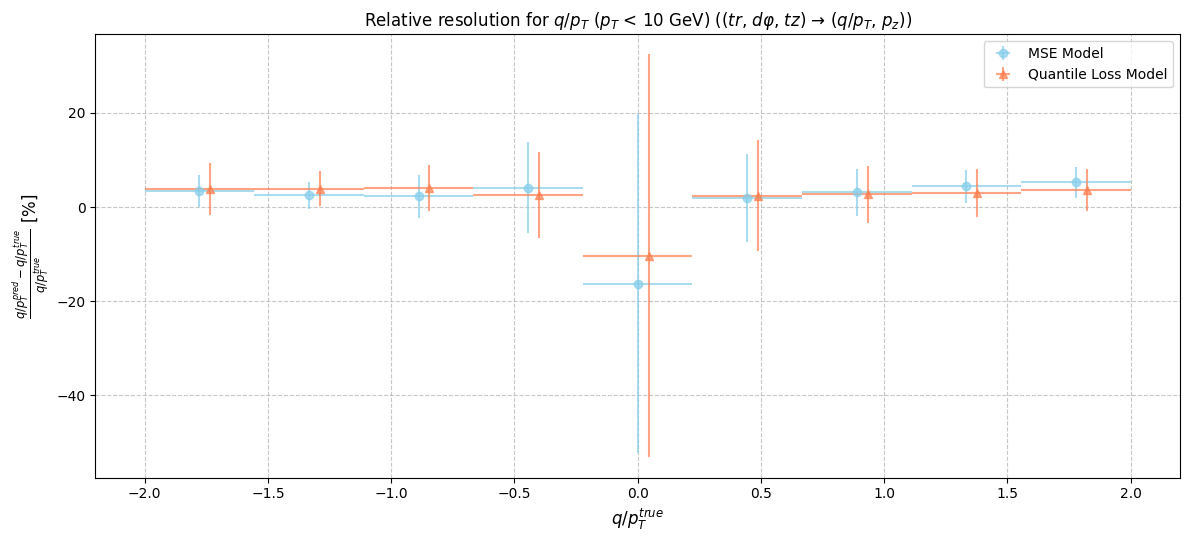

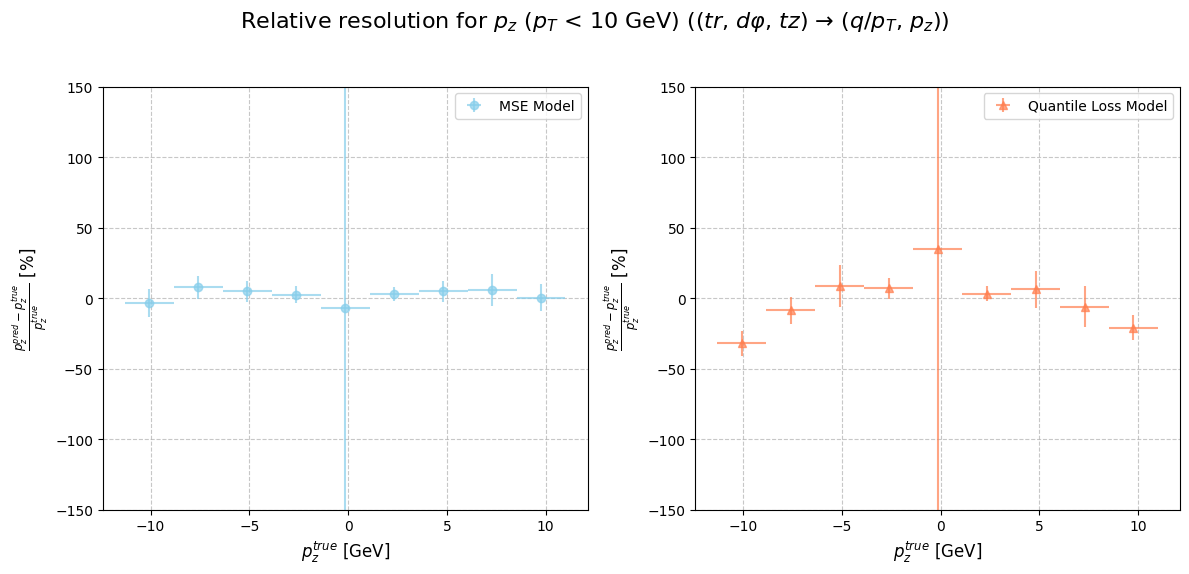

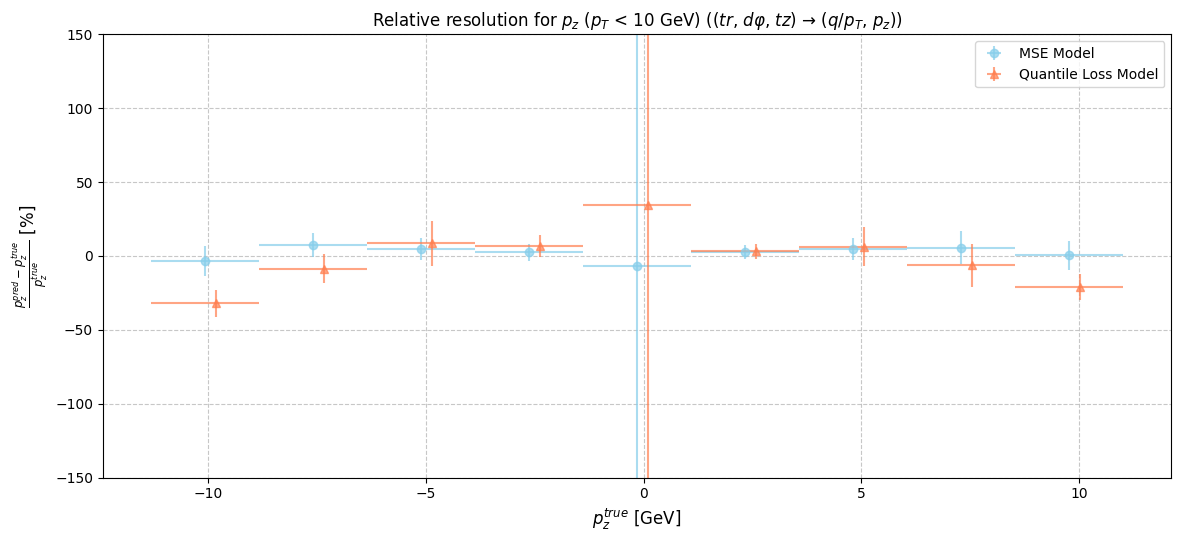

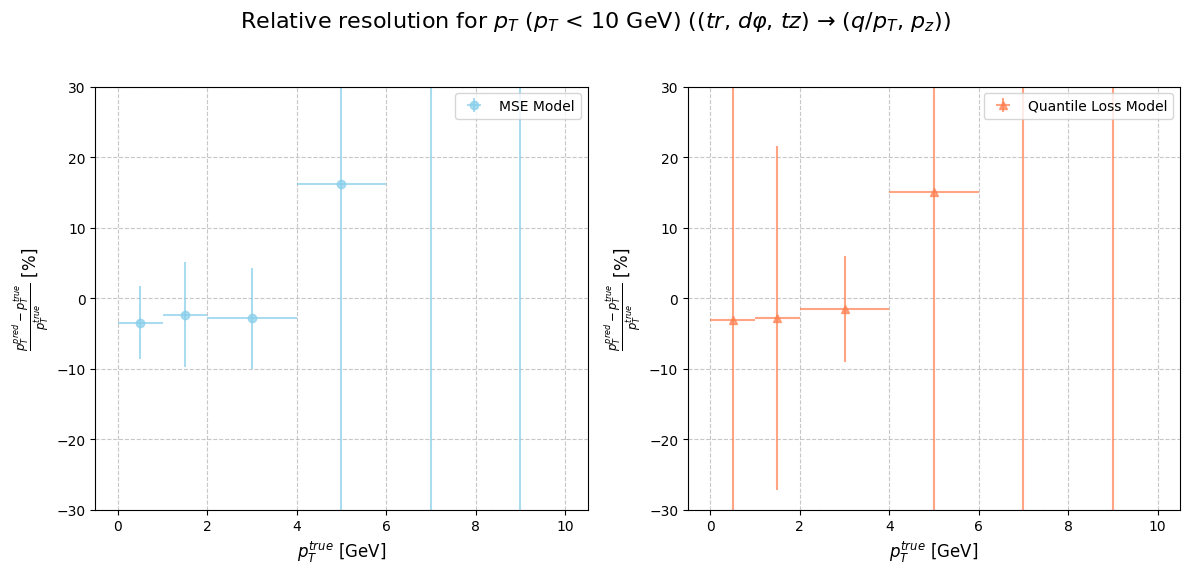

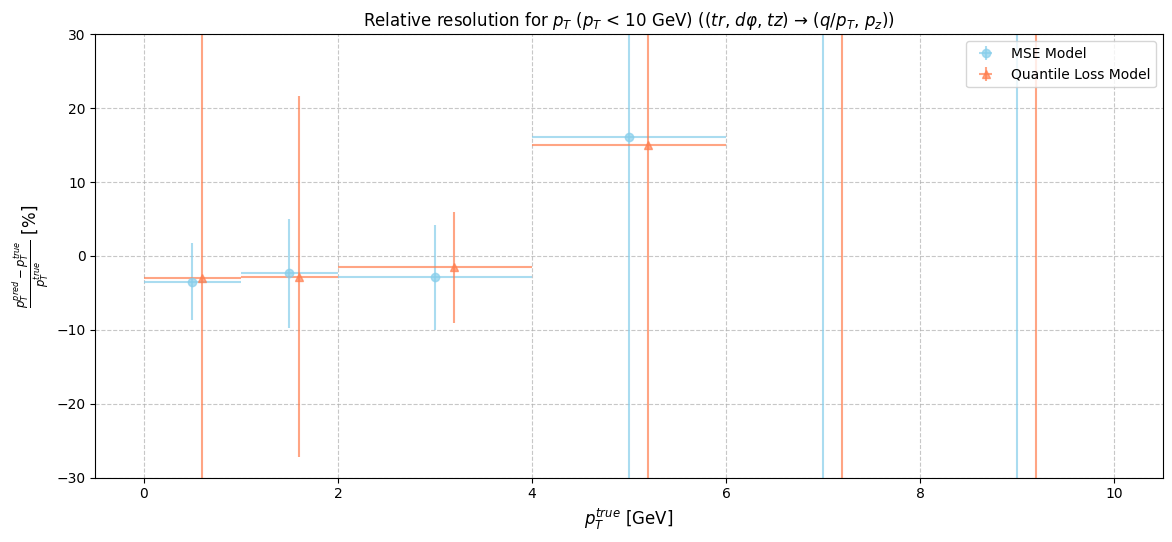

In [27]:
plot_pi_rel_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]],
    low_pt=True,
)
if config["output_variables"][0] == "qopT":
    plot_pi_rel_resolutions(target_labels=["p_T"], low_pt=True)

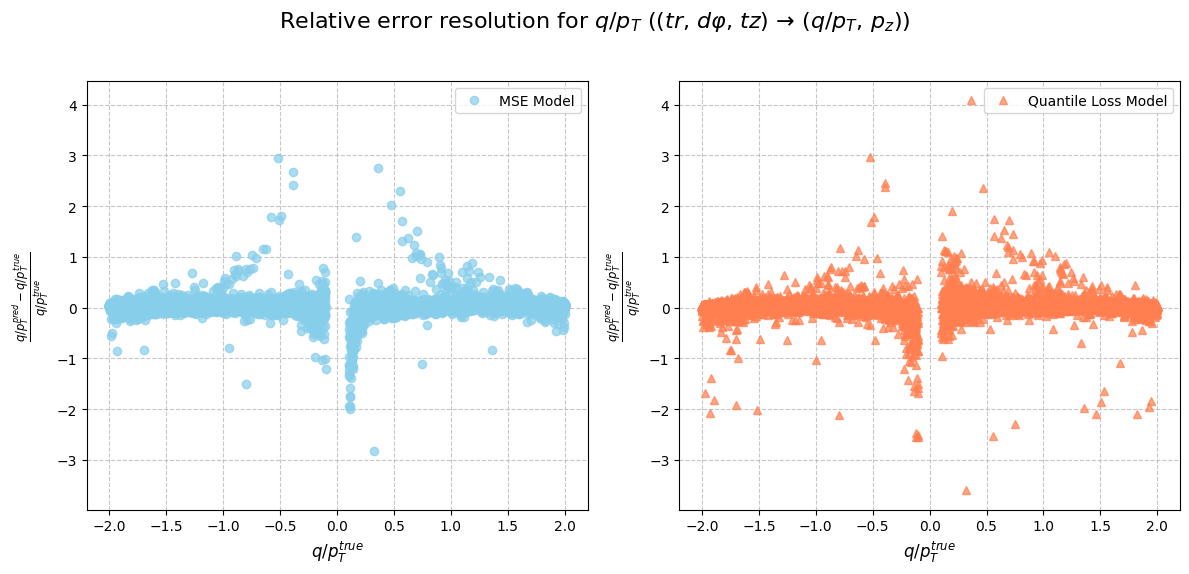

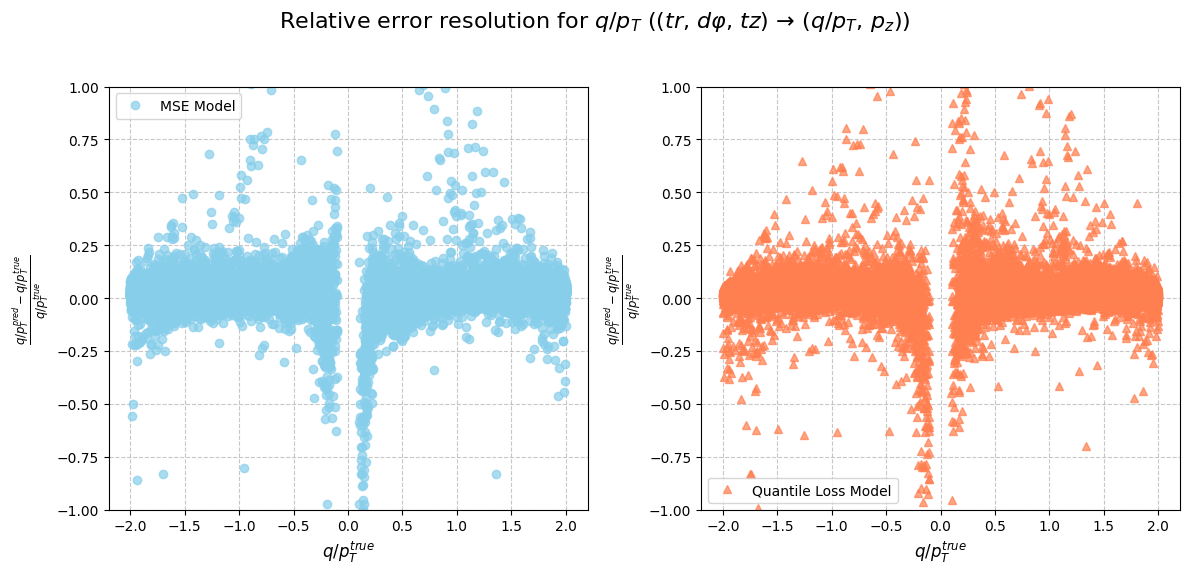

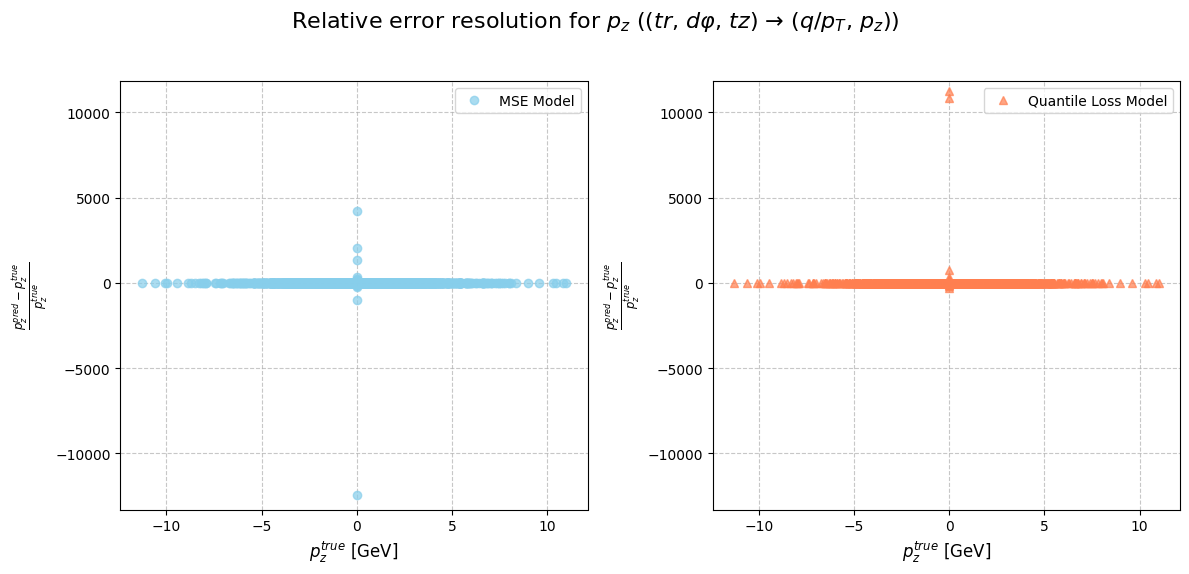

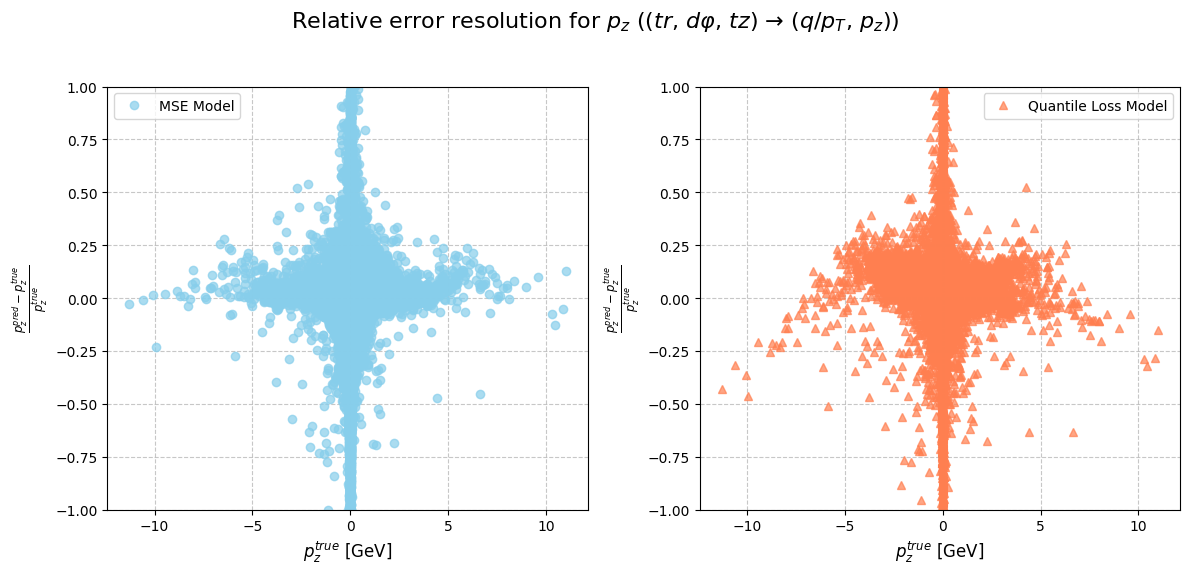

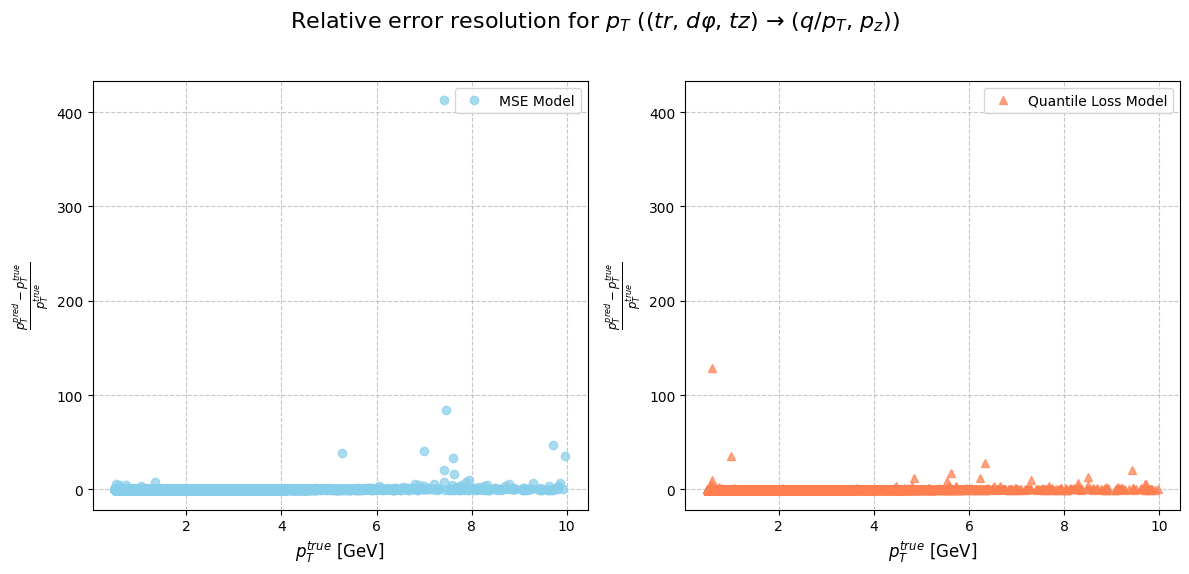

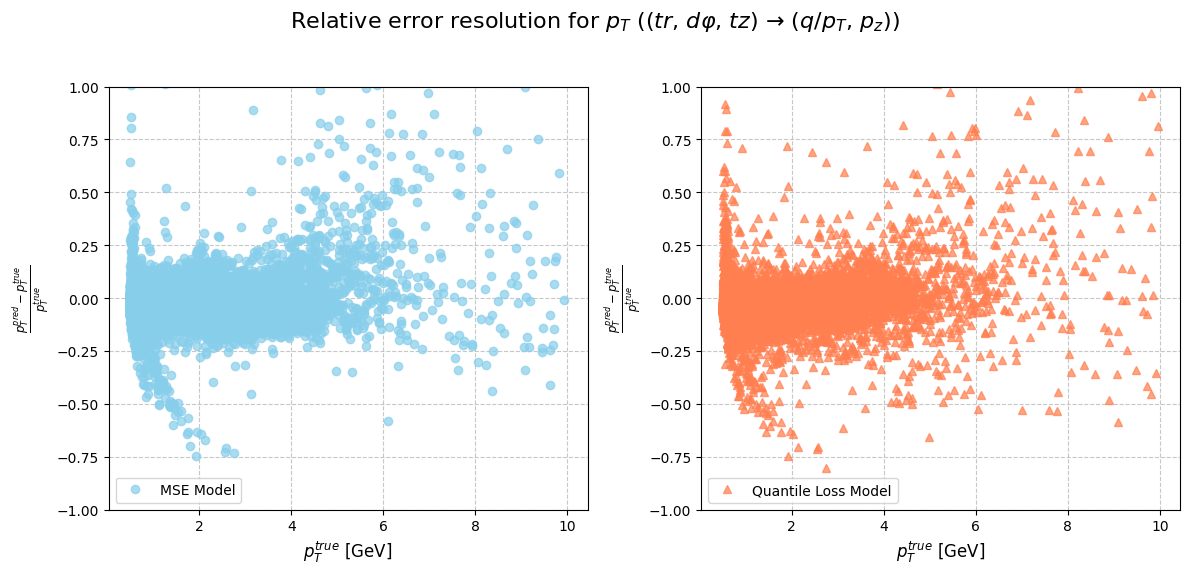

In [28]:
def plot_pi_rel_error_resolutions(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        title = f"Relative error resolution for ${var}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        ylabel = (
            r"$\frac{"
            + f"{pred_label} - {true_label}".replace("$", "")
            + "}{"
            + f"{true_label}".replace("$", "")
            + "}$"
        )
        filename = f"rel_error_resolution_{variable_filenames[var]}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # Loop over each model.
        for model_index, model_info in enumerate(models.values(), start=1):
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values

            plt.subplot(1, len(models), model_index)
            plt.plot(
                pi_true_values,
                relative_errors,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # Loop over each model.
        for model_index, model_info in enumerate(models.values(), start=1):
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values

            plt.subplot(1, len(models), model_index)
            plt.plot(
                pi_true_values,
                relative_errors,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=f"{model_info['color']}",
                marker=model_info["marker"],
                linestyle="None",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.ylim(-1, 1)
            plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(str(filename).replace(".", "_limited."), format="png")
        plt.show()


plot_pi_rel_error_resolutions(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_rel_error_resolutions(target_labels=["p_T"])

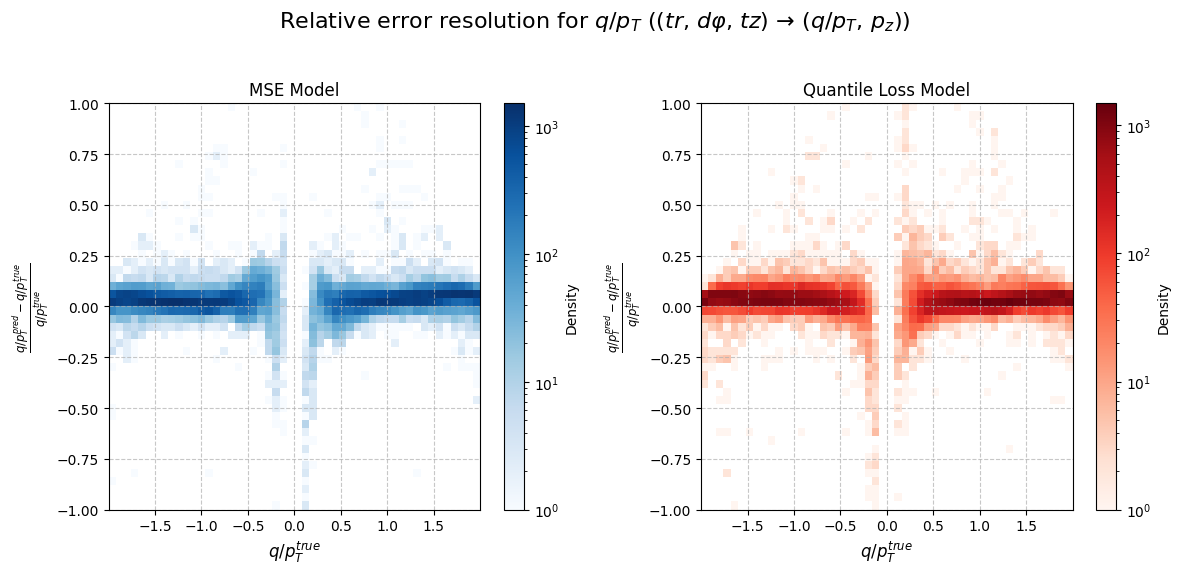

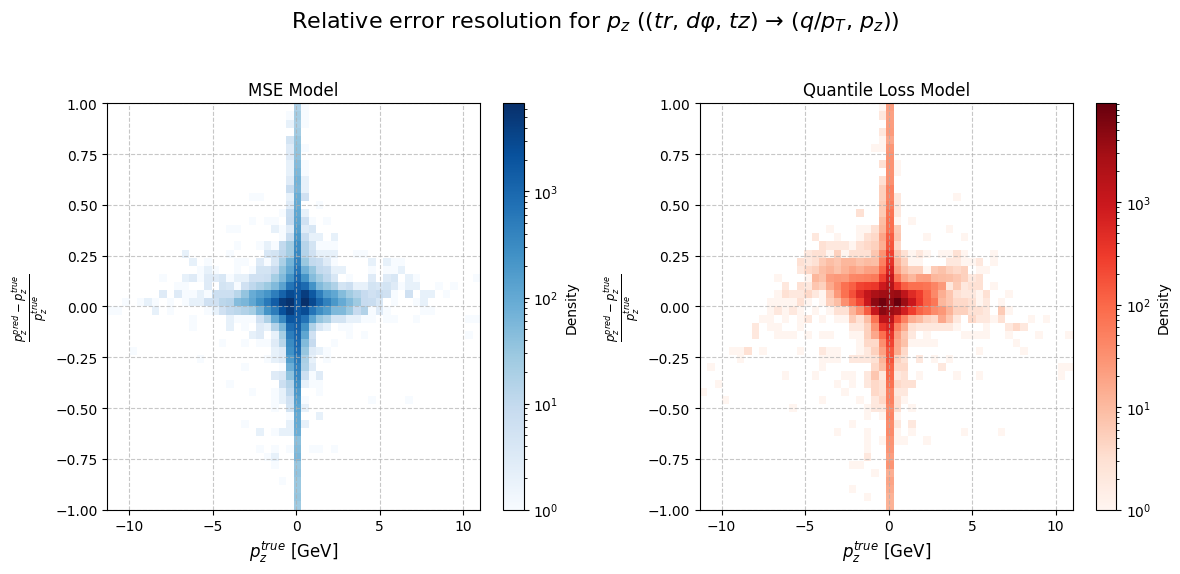

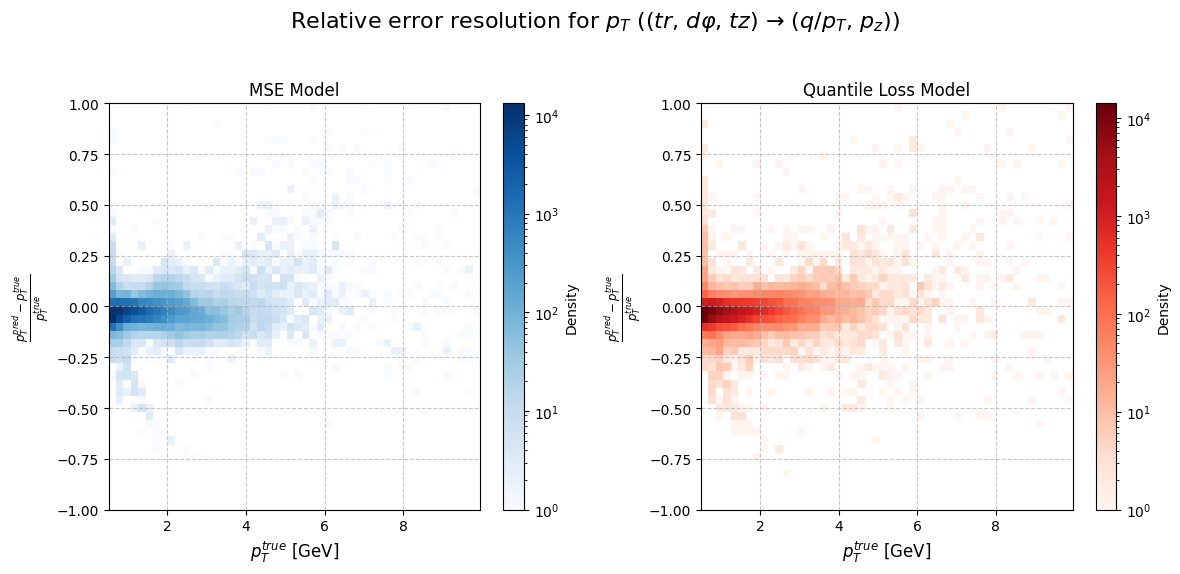

In [29]:
import numpy as np
import matplotlib.pyplot as plt


def plot_2d_histogram(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        title = f"Relative error resolution for ${var}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        ylabel = (
            r"$\frac{"
            + f"{pred_label} - {true_label}".replace("$", "")
            + "}{"
            + f"{true_label}".replace("$", "")
            + "}$"
        )

        filename = f"rel_error_histogram_{variable_filenames[var]}.png"
        filename = output_dir / filename

        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = (50, 50)
        from matplotlib import colors

        # Loop over each model.
        y_range = (-1, 1)
        for model_index, model_info in enumerate(models.values(), start=1):
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values

            plt.subplot(1, len(models), model_index)
            plt.hist2d(
                pi_true_values,
                relative_errors,
                bins=bins,
                cmap=model_info["cmap"],
                density=False,
                norm=colors.LogNorm(),
                range=[(min(pi_true_values), max(pi_true_values)), y_range],
            )
            plt.colorbar(label="Density")
            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.title(f"{model_info['label']} Model")
            plt.grid(True, linestyle="--", alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_2d_histogram(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_2d_histogram(target_labels=["p_T"])

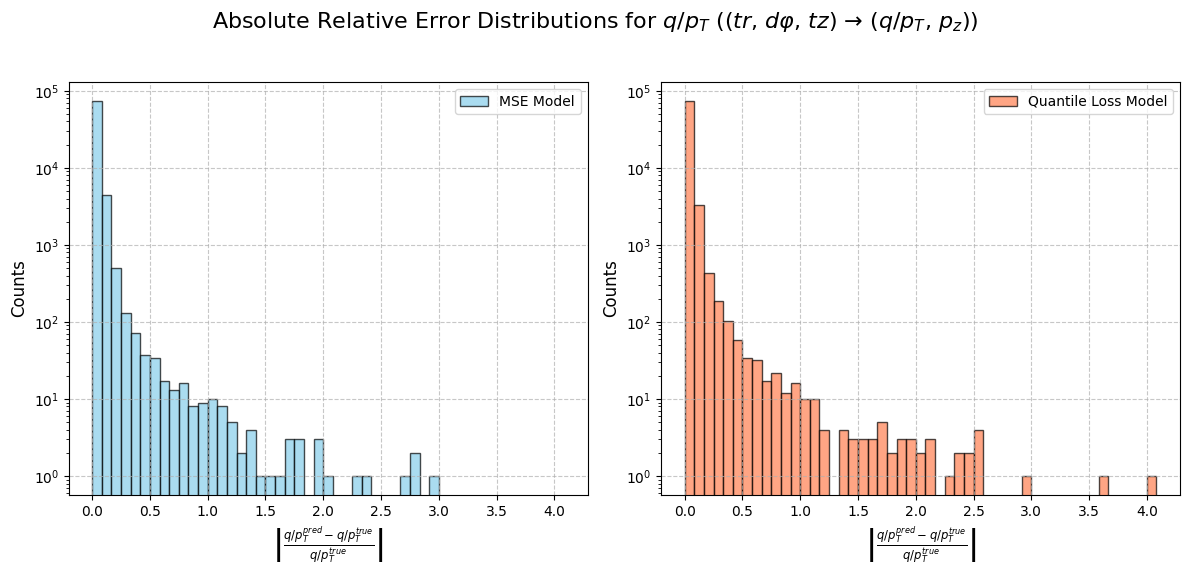

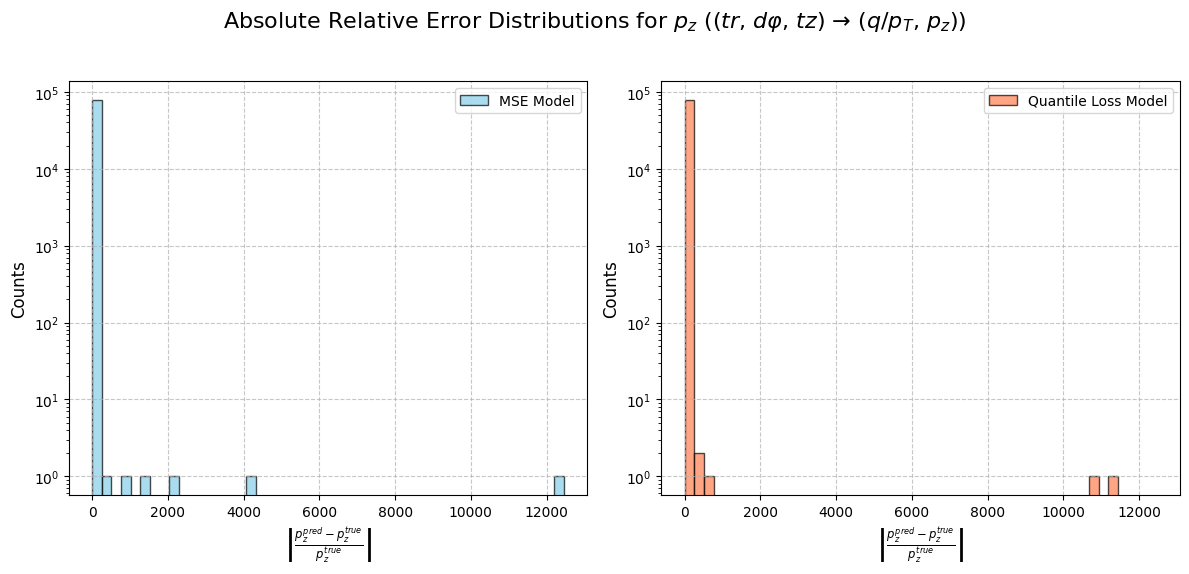

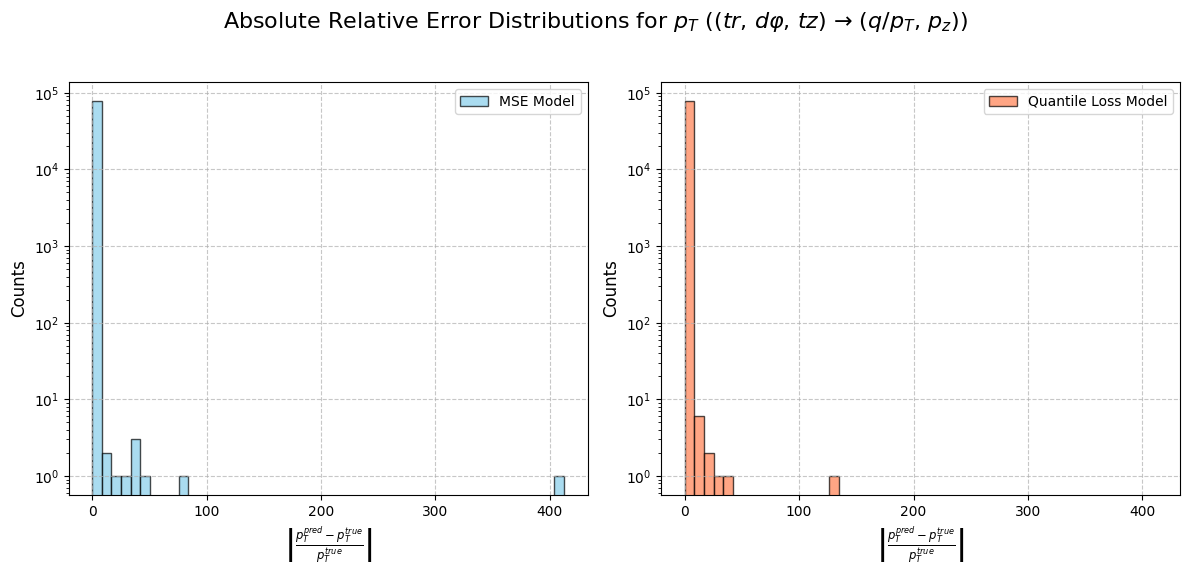

In [30]:
def plot_pi_absolute_relative_error_distributions(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        title = f"Absolute Relative Error Distributions for ${var}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\left|\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}\\right|$"
        ylabel = "Counts"
        filename = (
            f"absolute_relative_error_distributions_{variable_filenames[var]}.png"
        )
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # Loop over each model.
        model_data = {}
        for model_name, model_info in models.items():
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values
            abs_relative_errors = np.abs(relative_errors)
            model_data[model_name] = abs_relative_errors

        bins = np.linspace(0, max([max(v) for v in model_data.values()]), 50)

        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            abs_relative_errors = model_data[model_name]

            plt.subplot(1, len(models), model_index)
            plt.hist(
                abs_relative_errors,
                bins=bins,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=model_info["color"],
                edgecolor="black",
            )
            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.yscale("log")
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_absolute_relative_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_absolute_relative_error_distributions(target_labels=["p_T"])

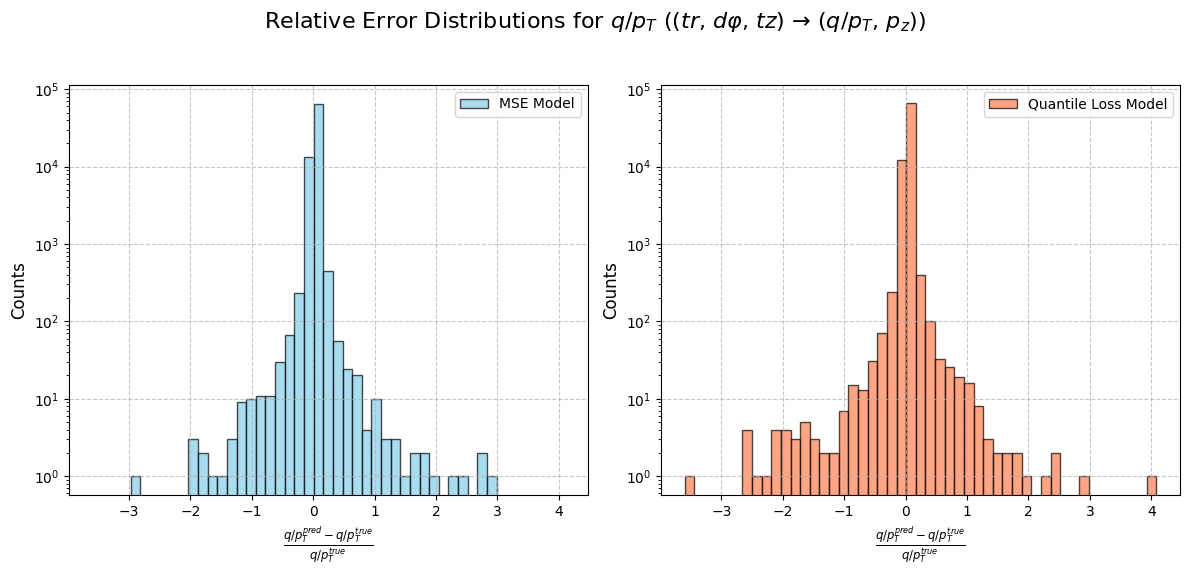

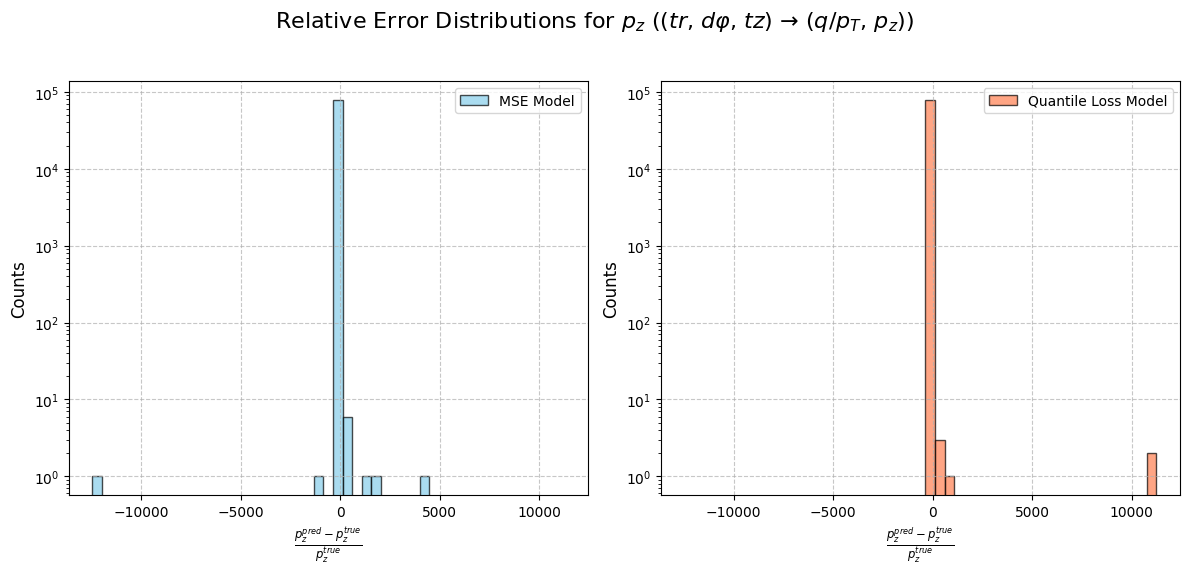

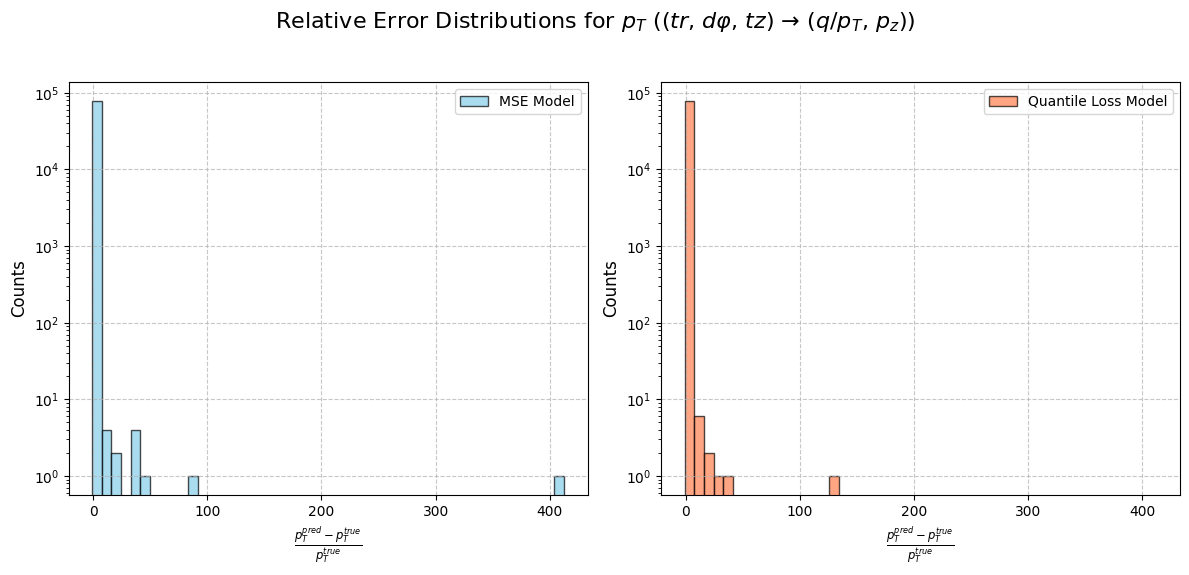

In [31]:
def plot_pi_relative_error_distributions(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        title = f"Relative Error Distributions for ${var}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Counts"
        filename = f"relative_error_distributions_{variable_filenames[var]}.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # Loop over each model.
        model_data = {}
        for model_name, model_info in models.items():
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values
            model_data[model_name] = relative_errors

        bins = np.linspace(
            min([min(v) for v in model_data.values()]),
            max([max(v) for v in model_data.values()]),
            50,
        )

        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            abs_relative_errors = model_data[model_name]

            plt.subplot(1, len(models), model_index)
            plt.hist(
                abs_relative_errors,
                bins=bins,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=model_info["color"],
                edgecolor="black",
            )
            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.yscale("log")
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_relative_error_distributions(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_relative_error_distributions(target_labels=["p_T"])

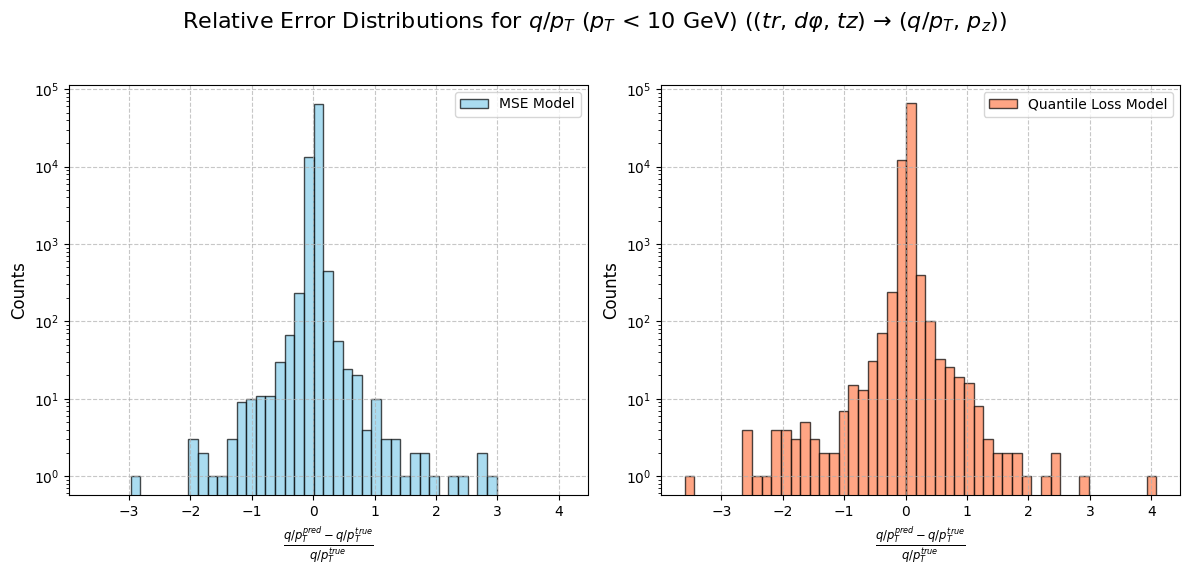

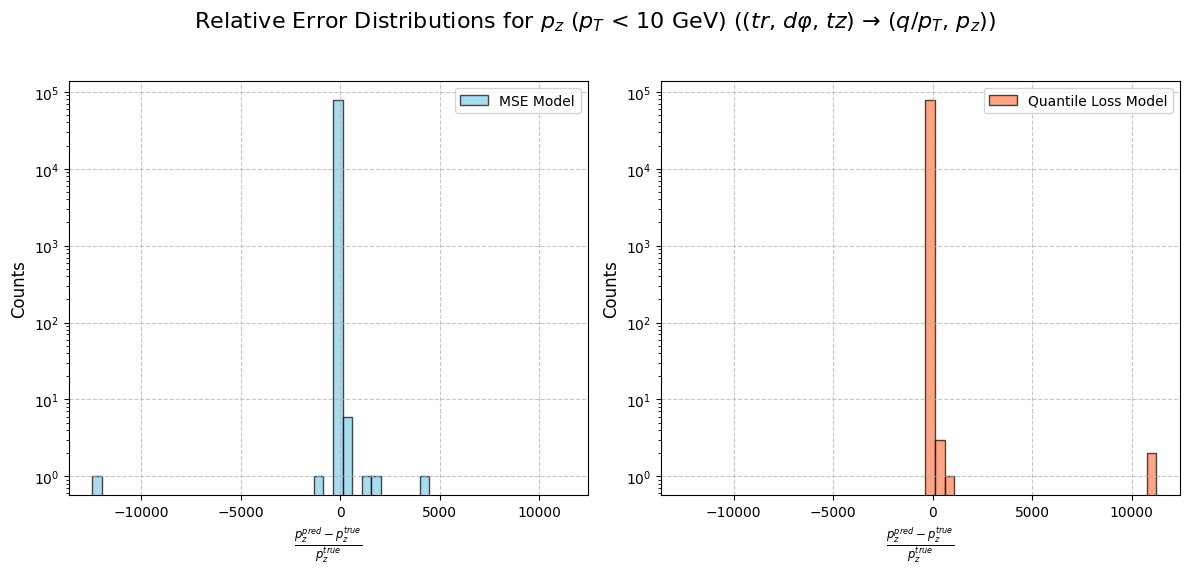

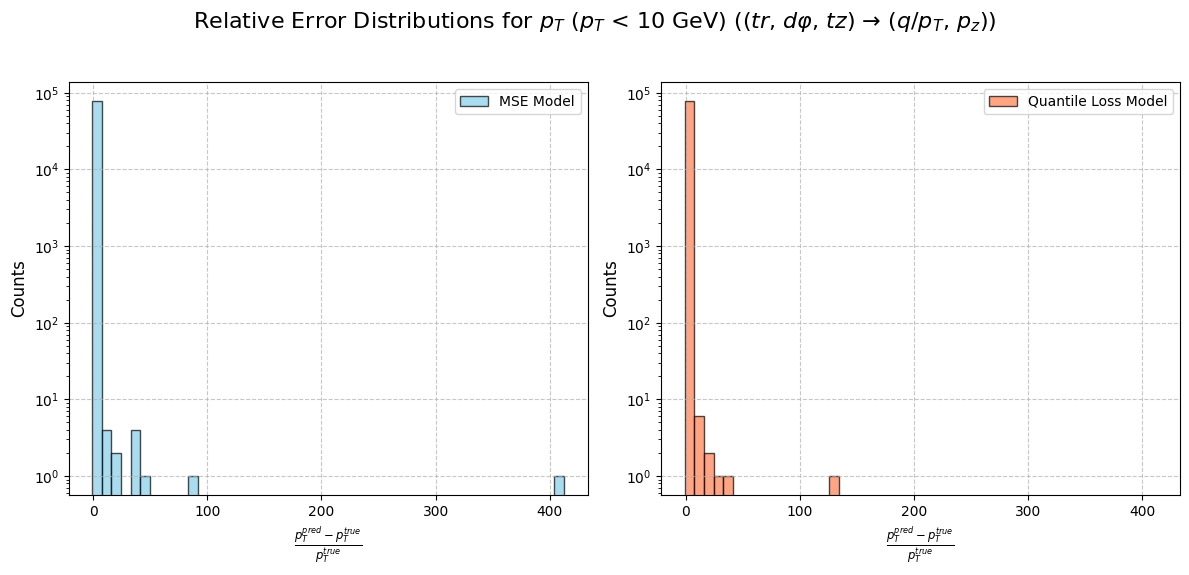

In [32]:
def plot_pi_relative_error_distributions_low_pt(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        pt_true = np.array(p_true_list)[:, 0]
        if config["output_variables"][0] == "qopT":
            pt_true = 1 / np.abs(pt_true)
        mask = pt_true < 10

        title = f"Relative Error Distributions for ${var}$ ($p_T$ < 10 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Counts"
        filename = f"relative_error_distributions_{variable_filenames[var]}_low_pt.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)
        # Loop over each model.
        model_data = {}
        for model_name, model_info in models.items():
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)

            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values
            # Apply mask
            relative_errors = relative_errors[mask]
            model_data[model_name] = relative_errors

        bins = np.linspace(
            min([min(v) for v in model_data.values()]),
            max([max(v) for v in model_data.values()]),
            50,
        )

        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            abs_relative_errors = model_data[model_name]

            plt.subplot(1, len(models), model_index)
            plt.hist(
                abs_relative_errors,
                bins=bins,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=model_info["color"],
                edgecolor="black",
            )
            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            plt.yscale("log")
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi_relative_error_distributions_low_pt(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_relative_error_distributions_low_pt(target_labels=["p_T"])

99.99994266968912% quantile for MSE: 2.938128708297957
99.99994266968912% quantile for Qloss: 2.9636603490578386
5.733031088084317e-05% quantile for MSE: -1.4920388323117952
5.733031088084317e-05% quantile for Qloss: -2.5307671652669046


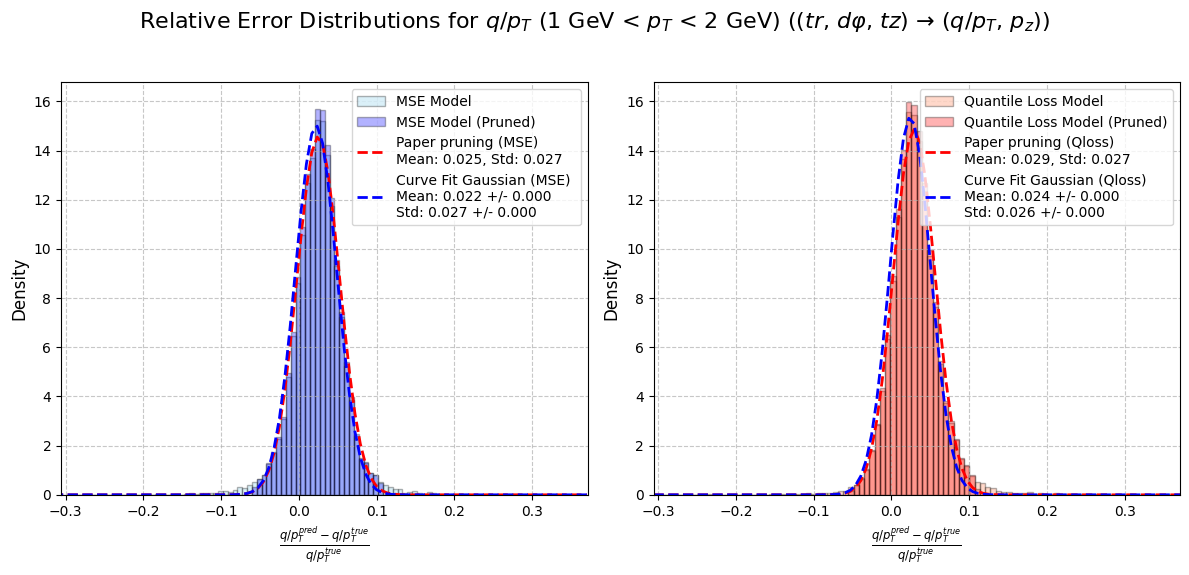

/tmp/ipykernel_102638/593455117.py:4: RuntimeWarning: divide by zero encountered in log
  return np.sum(-2 * np.log(likelyhood))


Likely hood def: inf
Likely hood def: inf
Likely hood def: inf
99.99994266968912% quantile for MSE: 4164.539597102474
99.99994266968912% quantile for Qloss: 10697.404711777499
5.733031088084317e-05% quantile for MSE: -47.11400379746722
5.733031088084317e-05% quantile for Qloss: -33.884859455008716


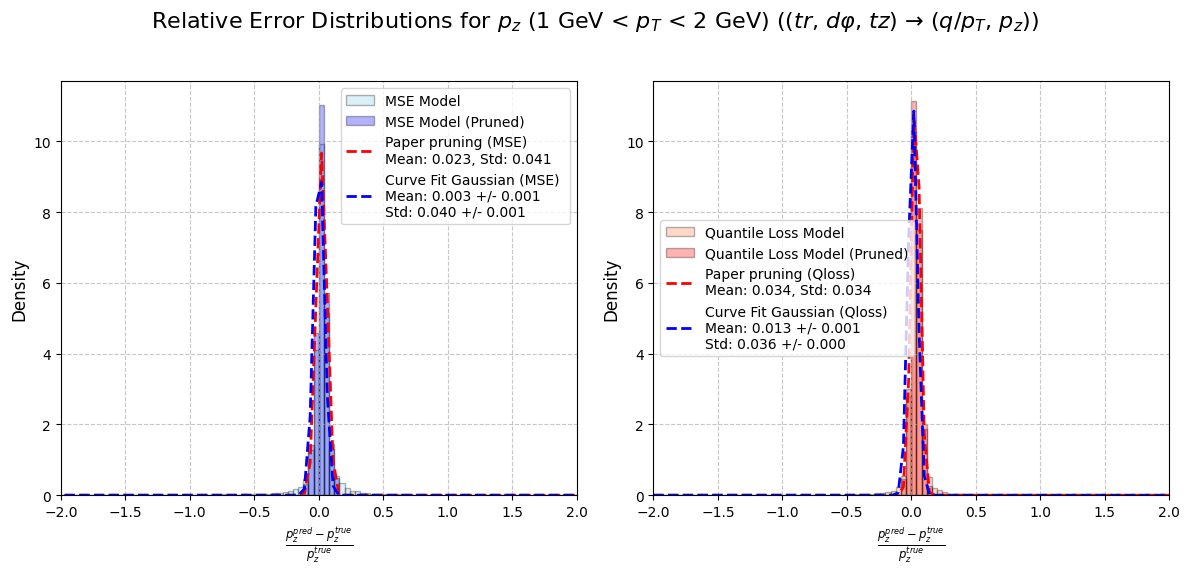

Likely hood def: inf
Likely hood def: inf
Likely hood def: inf
99.99994266968912% quantile for MSE: 8.081099708119146
99.99994266968912% quantile for Qloss: 34.77890443297859
5.733031088084317e-05% quantile for MSE: -0.7459745265893899
5.733031088084317e-05% quantile for Qloss: -0.7472763849233701


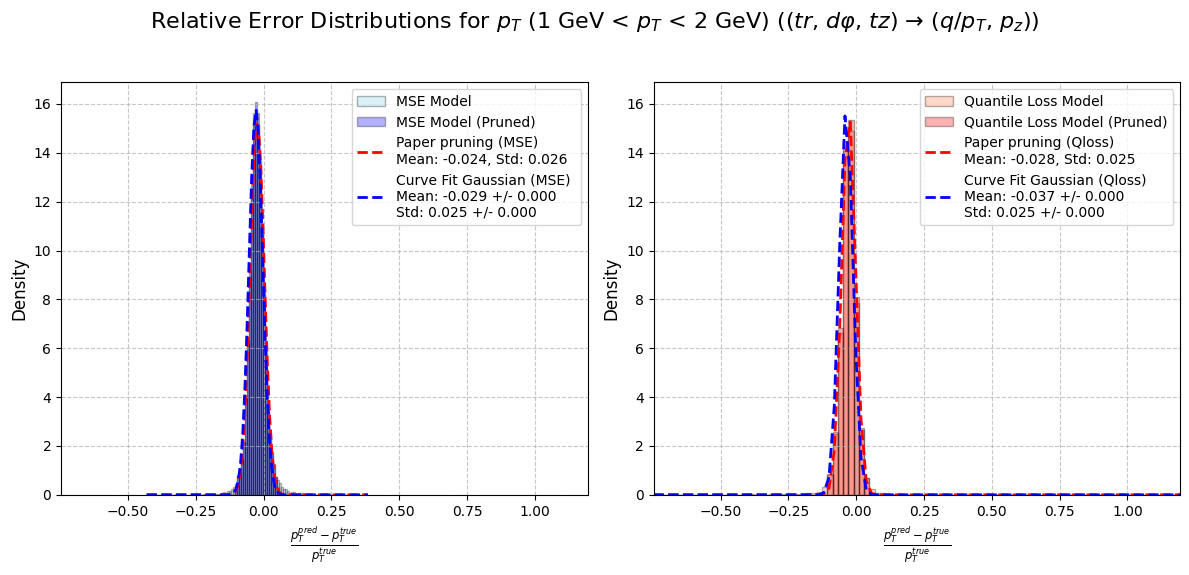

Likely hood def: inf
Likely hood def: inf
Likely hood def: inf


In [52]:
def plot_pi_relative_error_distributions_low_pt_1_2__(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)
            pi_pred_mse_list = 1 / np.abs(pi_pred_mse_list)
            pi_pred_qloss_list = 1 / np.abs(pi_pred_qloss_list)

        errors_mse_var = pi_pred_mse_list - pi_true_values
        errors_qloss_var = pi_pred_qloss_list - pi_true_values

        relative_errors_mse_var = errors_mse_var / pi_true_values
        relative_errors_qloss_var = errors_qloss_var / pi_true_values

        pt_true = np.array(p_true_list)[:, 0]
        if config["output_variables"][0] == "qopT":
            pt_true = 1 / np.abs(pt_true)
        mask = pt_true < 2
        mask = mask & (pt_true > 1)
        relative_errors_mse_var = relative_errors_mse_var[mask]
        relative_errors_qloss_var = relative_errors_qloss_var[mask]

        title = f"Relative Error Distributions for ${var}$ (1 GeV < $p_T$ < 2 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Density"
        filename = (
            f"relative_error_distributions_{variable_filenames[var]}_low_pt_1_2.png"
        )
        filename = output_dir / filename

        # Add a gaussian with mean and std of the distribution
        from scipy.stats import norm

        mean_mse_, std_mse_ = norm.fit(relative_errors_mse_var)
        mean_qloss_, std_qloss_ = norm.fit(relative_errors_qloss_var)

        relative_errors_mse_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_mse_list[mask] / pi_true_values[mask],
        )
        relative_errors_qloss_var_pruned, _ = compute_track_resolution(
            pi_true_values[mask] / pi_true_values[mask],
            pi_pred_qloss_list[mask] / pi_true_values[mask],
        )

        mean_mse, std_mse = np.mean(relative_errors_mse_var_pruned), np.std(
            relative_errors_mse_var_pruned
        )
        mean_qloss, std_qloss = np.mean(relative_errors_qloss_var_pruned), np.std(
            relative_errors_qloss_var_pruned
        )

        # Add a real gaussian fit
        from scipy.stats import norm
        from scipy.optimize import curve_fit

        def gaussian(x, amplitude, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def gaussian(x, mean, stddev):
            # Normalized Gaussian
            amplitude = 1 / (stddev * np.sqrt(2 * np.pi))
            return amplitude * np.exp(-(((x - mean) / 4 / stddev) ** 2))

        def fit_gaussian(y, x, p0=[0, 0.4]):
            # Remove extra x value
            x = x[:-1]
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 1], bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=[1, 0, 0.1], bounds=([0, -3, 0], [np.inf, 3, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-3, 0], [3, 1]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-2, 0], [np.inf, np.inf]))
            # popt, _ = curve_fit(gaussian, x, y, p0=p0, bounds=([-1.5, 0], [1.5, 35]))
            popt, pcov = curve_fit(
                norm.pdf, x, y, p0=p0, bounds=([-np.inf, 0], [np.inf, np.inf])
            )
            perr = np.sqrt(np.diag(pcov))
            return popt, perr

        # Get the 82% quantile
        from scipy.stats import scoreatpercentile

        quantile_target = (1 - (1 / 1744278)) * 100
        # quantile_target = (1-(1 / 370.398)) * 100
        # quantile_target = (1-(1 / 3.1514872)) * 100
        q_mse = scoreatpercentile(relative_errors_mse_var, quantile_target)
        q_qloss = scoreatpercentile(relative_errors_qloss_var, quantile_target)

        print(f"{quantile_target}% quantile for MSE: {q_mse}")
        print(f"{quantile_target}% quantile for Qloss: {q_qloss}")

        # Same with lower quantile
        low_quantile_target = 100 - quantile_target
        q_low_mse = scoreatpercentile(relative_errors_mse_var, low_quantile_target)
        q_low_qloss = scoreatpercentile(relative_errors_qloss_var, low_quantile_target)

        print(f"{low_quantile_target}% quantile for MSE: {q_low_mse}")
        print(f"{low_quantile_target}% quantile for Qloss: {q_low_qloss}")

        n_sig = 5
        # q_low_qloss = (q_low_qloss-mean_qloss)*n_sig + mean_qloss
        # q_qloss = (q_qloss-mean_qloss)*n_sig + mean_qloss
        # q_low_mse = (q_low_mse-mean_mse)*n_sig + mean_mse
        # q_mse = (q_mse-mean_mse)*n_sig + mean_mse

        q_low_mse = max(q_low_mse, -n_sig * std_mse_ + mean_mse_)
        q_low_qloss = max(q_low_qloss, -n_sig * std_qloss_ + mean_qloss_)
        q_mse = min(q_mse, n_sig * std_mse_ + mean_mse_)
        q_qloss = min(q_qloss, n_sig * std_qloss_ + mean_qloss_)

        if var == "p_z":
            q_low_mse = -2
            q_low_qloss = -2
            q_mse = 2
            q_qloss = 2

        bins = 100
        mse_bins, mse_edges = np.histogram(
            relative_errors_mse_var, bins=bins, density=True, range=(q_low_mse, q_mse)
        )
        qloss_bins, qloss_edges = np.histogram(
            relative_errors_qloss_var,
            bins=bins,
            density=True,
            range=(q_low_qloss, q_qloss),
        )

        mse_fit, mse_fit_err = fit_gaussian(
            mse_bins, mse_edges, p0=[mean_mse_, std_mse_]
        )
        qloss_fit, qloss_fit_err = fit_gaussian(
            qloss_bins, qloss_edges, p0=[mean_qloss_, std_qloss_]
        )

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            relative_errors_mse_var,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model",
            color="skyblue",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_mse_var_pruned,
            bins=mse_edges,
            alpha=0.3,
            label="MSE Model (Pruned)",
            color="blue",
            edgecolor="black",
            density=True,
        )

        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_mse, std_mse)
        p_fit = norm.pdf(x, *mse_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (MSE) \nMean: {mean_mse:5.3f}, Std: {std_mse:5.3f}",
        )
        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (MSE) \nMean: {mse_fit[0]:5.3f} +/- {mse_fit_err[0]:5.3f}\nStd: {mse_fit[1]:5.3f} +/- {mse_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # Limit at 5 sigma
        plt.xlim(q_low_mse, q_mse)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            relative_errors_qloss_var,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model",
            color="coral",
            edgecolor="black",
            density=True,
        )
        # Plot the pruned version
        plt.hist(
            relative_errors_qloss_var_pruned,
            bins=qloss_edges,
            alpha=0.3,
            label="Quantile Loss Model (Pruned)",
            color="red",
            edgecolor="black",
            density=True,
        )

        # Limit at 5 sigma
        plt.xlim(q_low_qloss, q_qloss)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean_qloss, std_qloss)
        p_fit = norm.pdf(x, *qloss_fit)
        plt.plot(
            x,
            p,
            "r",
            linewidth=2,
            linestyle="--",
            label=f"Paper pruning (Qloss) \nMean: {mean_qloss:5.3f}, Std: {std_qloss:5.3f}",
        )
        plt.plot(
            x,
            p_fit,
            "b",
            linewidth=2,
            linestyle="--",
            label=f"Curve Fit Gaussian (Qloss) \nMean: {qloss_fit[0]:5.3f} +/- {qloss_fit_err[0]:5.3f}\nStd: {qloss_fit[1]:5.3f} +/- {qloss_fit_err[1]:5.3f}",
        )

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        # plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse, std_mse), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, mean_mse_, std_mse_), neglog=True)}"
        )
        print(
            f"Likely hood def: {compute_likelyhood(relative_errors_mse_var, lambda x: norm.pdf(x, *mse_fit), neglog=True)}"
        )


plot_pi_relative_error_distributions_low_pt_1_2__(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_relative_error_distributions_low_pt_1_2__(target_labels=["p_T"])

In [34]:
import ROOT
%jsroot on

In [35]:
import ROOT
import numpy as np


def plot_pi_relative_error_distributions_low_pt_1_2_(target_labels):
    # Set ROOT to batch mode so no GUI windows are opened.
    ROOT.gROOT.SetBatch(True)

    # Try to load and set ATLAS style (make sure AtlasStyle.C is in your working directory or adjust the path).
    try:
        ROOT.gROOT.LoadMacro("AtlasStyle.C")
        ROOT.SetAtlasStyle()
    except Exception as e:
        print("AtlasStyle.C not found. Proceeding with default ROOT style.")
        ROOT.gROOT.SetStyle("ATLAS")

    # Loop over each variable (assumed that target_labels is a list of variable names).
    for var_index, var in enumerate(target_labels):
        # Get the true values for the current variable.
        pi_true_values = np.array(p_true_list)[:, var_index]

        # Get the transverse momentum values (assumed to be the first column).
        pt_true = np.array(p_true_list)[:, 0]
        if config["output_variables"][0] == "qopT":
            pt_true = 1 / np.abs(pt_true)

        # Apply the pT mask: only select events with 1 < p_T < 2 GeV.
        mask = (pt_true > 1) & (pt_true < 2)

        # Loop over each model.
        for model_name, model_info in models.items():
            # Create a separate canvas for this variable and model.
            canvas = ROOT.TCanvas(
                f"canvas_{model_name}_{var}",
                f"Relative Error Distribution for {var} with {model_name} (1 < p_T < 2 GeV)",
                800,
                600,
            )

            # Compute the relative error: (prediction - true)/true.
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values
            # Apply the same pT mask.
            relative_errors = relative_errors[mask]

            # Create the histogram.
            bins = 50
            hist = ROOT.TH1F(
                f"hist_{model_name}_{var}",
                f"{model_name} Model: Relative Error Distribution for {var} (1 < p_T < 2 GeV)",
                bins,
                np.min(relative_errors),
                np.max(relative_errors),
            )
            # Fill the histogram.
            for err in relative_errors:
                hist.Fill(err)
            # Normalize the histogram if there are entries.
            if hist.Integral() > 0:
                hist.Scale(1.0 / hist.Integral())

            # Set histogram style.
            hist.SetLineColor(model_info["color"])
            hist.SetFillColorAlpha(model_info["color"], 0.3)
            hist.Draw("HIST")

            # Fit a Gaussian to the histogram.
            fit = ROOT.TF1(
                f"fit_{model_name}_{var}",
                "gaus",
                np.min(relative_errors),
                np.max(relative_errors),
            )
            hist.Fit(fit, "R")
            fit.SetLineColor(ROOT.kBlack)
            fit.Draw("SAME")

            # Retrieve the fit parameters.
            mean_fit = fit.GetParameter(1)
            sigma_fit = fit.GetParameter(2)

            # Create a legend to display the fit parameters.
            legend = ROOT.TLegend(0.60, 0.70, 0.90, 0.85)
            legend.SetBorderSize(0)
            legend.SetFillStyle(0)
            # Add the fit function as an entry with a label showing the fit parameters.
            legend.AddEntry(
                fit, f"Fit: Mean = {mean_fit:.3f}, #sigma = {sigma_fit:.3f}", "l"
            )
            legend.Draw("SAME")

            # Update the canvas and save the image.
            canvas.Modified()
            canvas.Update()
            filename = f"relative_error_distribution_{model_name}_{variable_filenames[var]}_low_pt_1_2.png"
            canvas.SaveAs(filename)


# Call the function to generate and save the plots.
# plot_pi_relative_error_distributions_low_pt_1_2_(target_labels=[variable_labels[var] for var in config['output_variables']])

AtlasStyle.C not found. Proceeding with default ROOT style.
99.99994266968912% quantile for MSE: 2.938128708297957
5.733031088084317e-05% quantile for MSE: -1.4920388323117952
Pruned fit for MSE: (0.02493031756809291, 0.033899731314829123)
MSE fit: mean_fit = 0.024849801988265897 +/- mean_fit_err = 0.0001920376052793544 sigma_fit = 0.02750926011051645 +/- sigma_fit_err = 0.00017846613414987562
99.99994266968912% quantile for QLoss: 2.9636603490578386
5.733031088084317e-05% quantile for QLoss: -2.5307671652669046
Pruned fit for QLoss: (0.030594455154174024, 0.034424694426665466)
QLoss fit: mean_fit = 0.028674281038874472 +/- mean_fit_err = 0.00019267806877673108 sigma_fit = 0.027048293341893175 +/- sigma_fit_err = 0.0001738722649649218


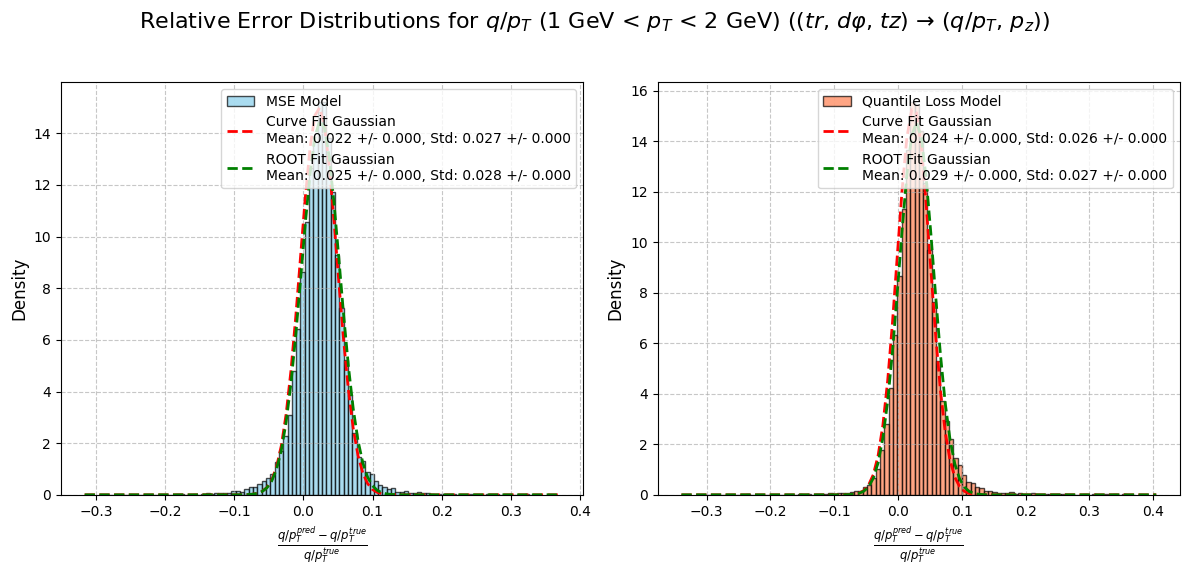

/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/couthures/anaconda3/envs/ML/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Likely hood Curve Fit MSE: nan
Likely hood ROOT Fit MSE: nan
Likely hood Curve Fit QLoss: nan
Likely hood ROOT Fit QLoss: nan
99.99994266968912% quantile for MSE: 4164.539597102474
5.733031088084317e-05% quantile for MSE: -47.11400379746722
Pruned fit for MSE: (0.02158128192900645, 0.1477571987975646)
MSE fit: mean_fit = 0.022644652786647058 +/- mean_fit_err = 0.0003093898072985637 sigma_fit = 0.04193080674775631 +/- sigma_fit_err = 0.0003506644594493541
99.99994266968912% quantile for QLoss: 10697.404711777499
5.733031088084317e-05% quantile for QLoss: -33.884859455008716
Pruned fit for QLoss: (0.03295960799015057, 0.1198901716557266)
QLoss fit: mean_fit = 0.03443016663664643 +/- mean_fit_err = 0.00026217512788007926 sigma_fit = 0.03651016955679348 +/- sigma_fit_err = 0.0002597661075640495


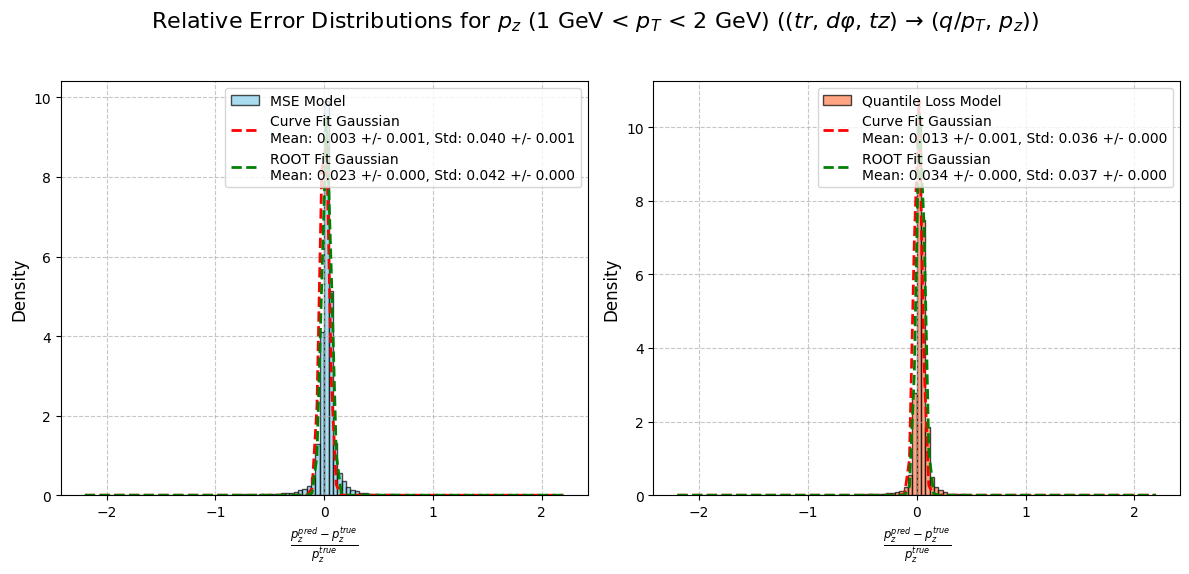

Likely hood Curve Fit MSE: 0.0
Likely hood ROOT Fit MSE: 0.0
Likely hood Curve Fit QLoss: 0.0
Likely hood ROOT Fit QLoss: 0.0
AtlasStyle.C not found. Proceeding with default ROOT style.
99.99994266968912% quantile for MSE: 8.081099708119146
5.733031088084317e-05% quantile for MSE: -0.7459745265893899
Pruned fit for MSE: (-0.023573844284171405, 0.033780333641589125)
MSE fit: mean_fit = -0.02414084903697226 +/- mean_fit_err = 0.00018426237348325136 sigma_fit = 0.026211109736503924 +/- sigma_fit_err = 0.00017200910231729948
99.99994266968912% quantile for QLoss: 34.77890443297859
5.733031088084317e-05% quantile for QLoss: -0.7472763849233701
Pruned fit for QLoss: (-0.02979386481976846, 0.03966960551587524)
QLoss fit: mean_fit = -0.02794520702435545 +/- mean_fit_err = 0.00018546949618882406 sigma_fit = 0.026520274391507875 +/- sigma_fit_err = 0.00016754637566187246


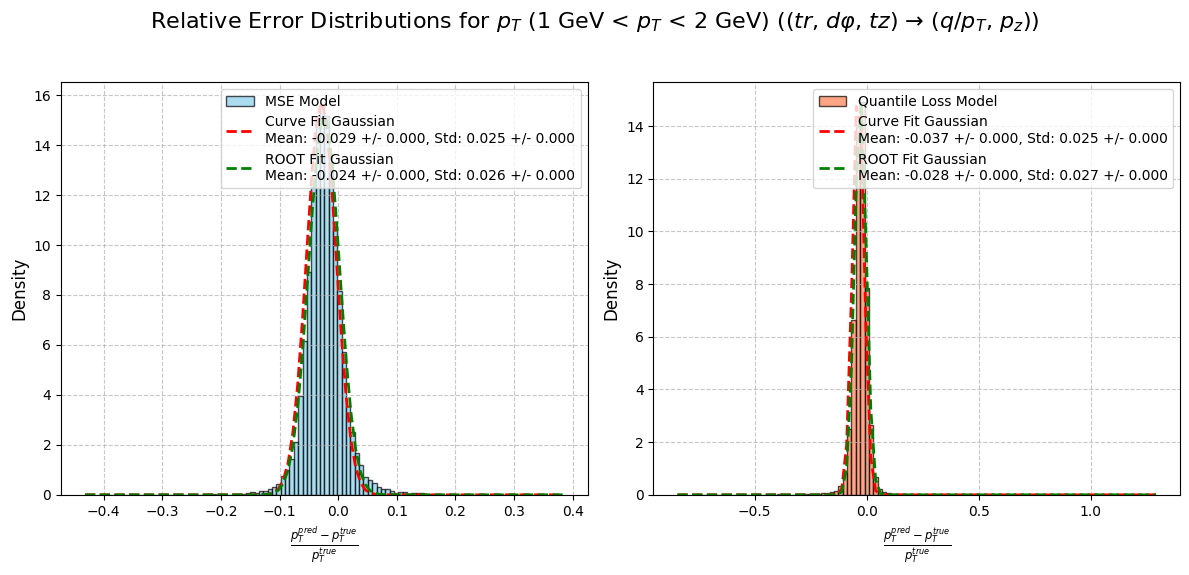

Likely hood Curve Fit MSE: nan
Likely hood ROOT Fit MSE: nan
Likely hood Curve Fit QLoss: nan
Likely hood ROOT Fit QLoss: nan
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      753.793
NDf                       =           74
Edm                       =  6.42394e-06
NCalls                    =           63
Constant                  =    0.0872871   +/-   0.000831411 
Mean                      =    0.0248498   +/-   0.000192038 
Sigma                     =    0.0275093   +/-   0.000178466  	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      738.002
NDf                       =           80
Edm                       =  1.06379e-06
NCalls                    =           72
Constant                  =    0.0963443   +/-   0.00091384  
Mean                      =    0.0286743   +/-   0.000192678 
Sigma                     =    0.0270483   +/-   0.000173872  	 (limited)
********

Error in <TROOT::LoadMacro>: macro AtlasStyle.C not found in path .:/home/couthures/anaconda3/envs/ML/macros
Error in <TROOT::LoadMacro>: macro AtlasStyle.C not found in path .:/home/couthures/anaconda3/envs/ML/macros


In [49]:
import ROOT
import numpy as np


def plot_pi_relative_error_distributions_low_pt_1_2(target_labels):
    # Set ROOT to batch mode so no GUI windows are opened.
    ROOT.gROOT.SetBatch(True)

    # Try to load and set ATLAS style (make sure AtlasStyle.C is in your working directory or adjust the path).
    try:
        ROOT.gROOT.LoadMacro("AtlasStyle.C")
        ROOT.SetAtlasStyle()
    except Exception as e:
        print("AtlasStyle.C not found. Proceeding with default ROOT style.")
        ROOT.gROOT.SetStyle("ATLAS")

    for var_index, var in enumerate(target_labels):
        title = f"Relative Error Distributions for ${var}$ (1 GeV < $p_T$ < 2 GeV)"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"$\\frac{{ {pred_label.replace('$', '')} - {true_label.replace('$', '')} }}{{ {true_label.replace('$', '')} }}$"
        ylabel = "Density"
        filename = (
            f"relative_error_distributions_{variable_filenames[var]}_low_pt_1_2.png"
        )
        filename = output_dir / filename

        # Get the transverse momentum values (assumed to be the first column).
        assert config["output_variables"][0] in ["pT", "qopT"]
        pt_true = np.array(p_true_list)[:, 0]
        if config["output_variables"][0] == "qopT":
            pt_true = 1 / np.abs(pt_true)

        # Apply the pT mask: only select events with 1 < p_T < 2 GeV.
        mask = (pt_true > 1) & (pt_true < 2)

        # Get the true values for the current variable.
        pi_true_values = np.array(p_true_list)[:, var_index]
        if config["output_variables"][0] == "qopT" and var == "p_T":
            pi_true_values = 1 / np.abs(pi_true_values)

        # Add a gaussian with mean and std of the distribution
        from scipy.stats import norm

        model_root_fits = {}
        norm_fits = {}
        model_quantiles = {}
        model_data = {}
        model_bins_dict = {}
        # Loop over each model.
        for model_name, model_info in models.items():
            # Compute the relative error: (prediction - true)/true.
            pi_pred_values = np.array(model_info["data_list"])[:, var_index]
            if config["output_variables"][0] == "qopT" and var == "p_T":
                pi_pred_values = 1 / np.abs(pi_pred_values)
            errors = pi_pred_values - pi_true_values
            relative_errors = errors / pi_true_values
            # Apply the same pT mask.
            relative_errors = relative_errors[mask]

            model_data[model_name] = relative_errors

            model_mean, model_std = norm.fit(
                relative_errors
            )  # that's a global fit, i.e. of all the data with MLE.

            norm_fits[model_name] = (model_mean, model_std)

            # Get the 82% quantile
            from scipy.stats import scoreatpercentile

            high_quantile_target = (1 - (1 / 1744278)) * 100
            # quantile_target = (1-(1 / 370.398)) * 100
            # quantile_target = (1-(1 / 3.1514872)) * 100
            q_high = scoreatpercentile(relative_errors, high_quantile_target)

            print(f"{high_quantile_target}% quantile for {model_name}: {q_high}")

            # Same with lower quantile
            low_quantile_target = 100 - high_quantile_target
            q_low = scoreatpercentile(relative_errors, low_quantile_target)
            print(f"{low_quantile_target}% quantile for {model_name}: {q_low}")

            model_quantiles[model_name] = (q_low, q_high)

            from scipy.optimize import curve_fit

            n_sig = 5
            q_low = max(q_low, -n_sig * model_std + model_mean)
            q_high = min(q_high, n_sig * model_std + model_mean)

            if var == "p_z":
                q_low = -2
                q_high = 2

            n_bins = 100

            fit_range = (q_low, q_high)
            # Prune the data
            relative_errors = relative_errors[
                (relative_errors > q_low) & (relative_errors < q_high)
            ]
            # Print norm fit of pruned data
            print(f"Pruned fit for {model_name}: {norm.fit(relative_errors)}")

            n, model_bins = np.histogram(
                relative_errors, bins=n_bins, density=True, range=fit_range
            )
            model_bins_dict[model_name] = model_bins
            param_model, cov_model = curve_fit(
                norm.pdf,
                model_bins[:-1],
                n,
                [model_mean, model_std],
                bounds=([-np.inf, 0], [np.inf, np.inf]),
            )
            perr_model = np.sqrt(np.diag(cov_model))
            model_mean, model_std = param_model
            model_mean_err, model_std_err = perr_model
            norm_fits[model_name] = (
                (model_mean, model_mean_err),
                (model_std, model_std_err),
            )

            # q_low = max(q_low, -n_sig*model_std + model_mean)
            # q_high = min(q_high, n_sig*model_std + model_mean)
            # model_quantiles[model_name] = (q_low, q_high)

            # Create the histogram.
            # Use model_bins_dict for the bins
            hist = ROOT.TH1F(
                f"hist_{model_name}_{var}",
                f"{model_name} Model: Relative Error Distribution for {var} (1 < p_T < 2 GeV)",
                len(model_bins) - 1,
                model_bins,
            )

            # Fill the histogram.
            for err in relative_errors:
                hist.Fill(err)
            # Normalize the histogram if there are entries.
            if hist.Integral() > 0:
                hist.Scale(1.0 / hist.Integral())

            # Fit a Gaussian to the histogram.
            fit = ROOT.TF1(
                f"fit_{model_name}_{var}",
                "gaus",
                np.min(relative_errors),
                np.max(relative_errors),
            )

            # Set the initial parameters (mean, std)
            fit.SetParameters(1e-2, 1e-1)

            # TODO: Use strategy 2 for the fit
            hist.Fit(fit, "R")

            # Retrieve the fit parameters.
            mean_fit = fit.GetParameter(1)
            sigma_fit = fit.GetParameter(2)
            mean_fit_err = fit.GetParError(1)
            sigma_fit_err = fit.GetParError(2)
            print(
                f"{model_name} fit: {mean_fit = } +/- {mean_fit_err = }",
                f"{sigma_fit = } +/- {sigma_fit_err = }",
            )
            # TODO: Show status of the fit
            # print(f"Fit status: {fit.GetStats()}")

            model_root_fits[model_name] = (
                (mean_fit, mean_fit_err),
                (sigma_fit, sigma_fit_err),
            )

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        for model_index, (model_name, model_info) in enumerate(models.items(), start=1):
            # MSE Model
            plt.subplot(1, len(models), model_index)
            bins = model_bins_dict[model_name]
            plt.hist(
                model_data[model_name],
                bins=bins,
                alpha=0.7,
                label=f"{model_info['label']} Model",
                color=f"{model_info['color']}",
                edgecolor="black",
                density=True,
            )

            model_mean, model_std = norm_fits[model_name]
            model_mean, model_mean_err = model_mean
            model_std, model_std_err = model_std

            model_root_mean, model_root_std = model_root_fits[model_name]
            model_root_mean, model_root_mean_err = model_root_mean
            model_root_std, model_root_std_err = model_root_std

            # # Limit at 5 sigma
            # plt.xlim(*model_quantiles[model_name])
            xmin, xmax = plt.xlim()
            x = np.linspace(xmin, xmax, 100)
            p_curve_fit = norm.pdf(x, model_mean, model_std)
            p_root_fit = norm.pdf(x, model_root_mean, model_root_std)
            plt.plot(
                x,
                p_curve_fit,
                "r",
                linewidth=2,
                linestyle="--",
                label=f"Curve Fit Gaussian\nMean: {model_mean:5.3f} +/- {model_mean_err:5.3f}, Std: {model_std:5.3f} +/- {model_std_err:5.3f}",
            )
            plt.plot(
                x,
                p_root_fit,
                "g",
                linewidth=2,
                linestyle="--",
                label=f"ROOT Fit Gaussian\nMean: {model_root_mean:5.3f} +/- {model_root_mean_err:5.3f}, Std: {model_root_std:5.3f} +/- {model_root_std_err:5.3f}",
            )

            plt.xlabel(xlabel, fontsize=12)
            plt.ylabel(ylabel, fontsize=12)
            # plt.yscale("log")
            plt.grid(True, linestyle="--", alpha=0.7)
            plt.legend()

        # sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()

        for model_name, model_info in models.items():
            model_mean, model_std = norm_fits[model_name]
            model_mean, model_mean_err = model_mean
            model_std, model_std_err = model_std
            print(
                f"Likely hood Curve Fit {model_name}: {compute_likelyhood(model_data[model_name], lambda x: norm.pdf(x, model_mean, model_std))}"
            )
            model_root_mean, model_root_std = model_root_fits[model_name]
            model_root_mean, model_root_mean_err = model_root_mean
            model_root_std, model_root_std_err = model_root_std
            print(
                f"Likely hood ROOT Fit {model_name}: {compute_likelyhood(model_data[model_name], lambda x: norm.pdf(x, model_root_mean, model_root_std))}"
            )


# Call the function to generate and save the plots.
plot_pi_relative_error_distributions_low_pt_1_2(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)
if config["output_variables"][0] == "qopT":
    plot_pi_relative_error_distributions_low_pt_1_2(target_labels=["p_T"])

In [35]:
bad_tracks_q[i][0]

IndexError: list index out of range

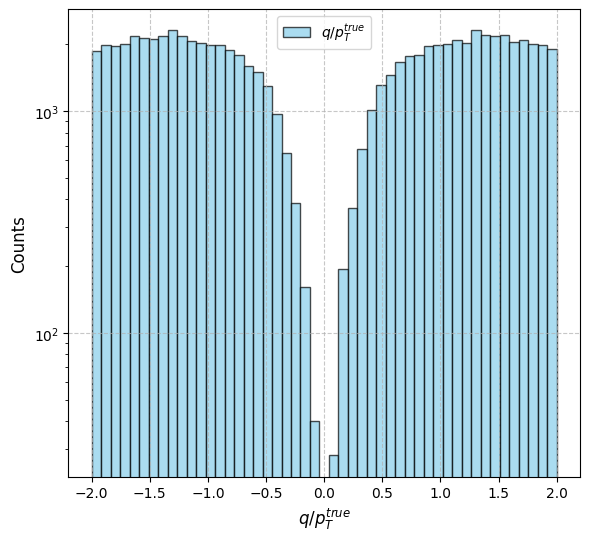

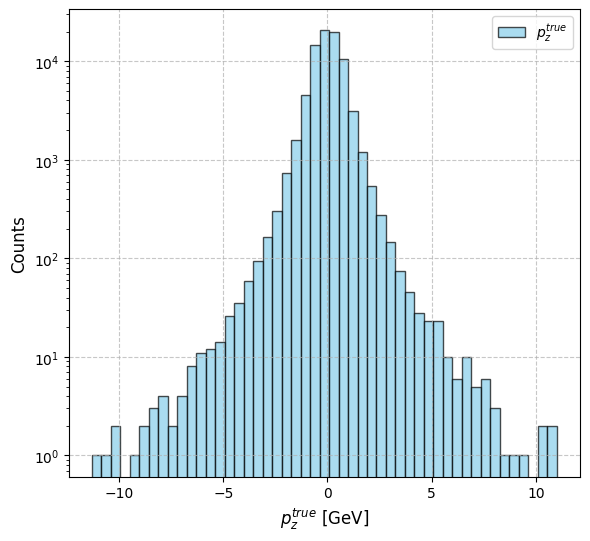

In [37]:
def plot_alone_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        title = f"${var}^{{true}}$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = true_label + (" [GeV]" if var.startswith("p") else "")
        filename = f"{variable_filenames[var]}_true.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(6, 6))

        bins = np.linspace(
            min(pi_true_values),
            max(pi_true_values),
            50,
        )

        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        # plt.title(title)
        plt.legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_alone_pi(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)

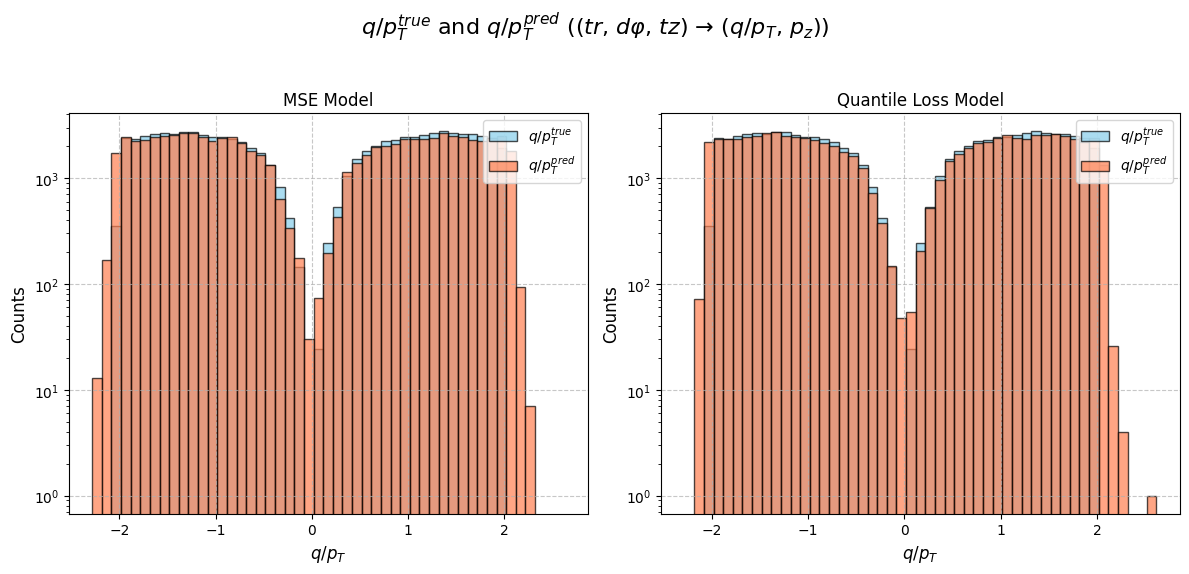

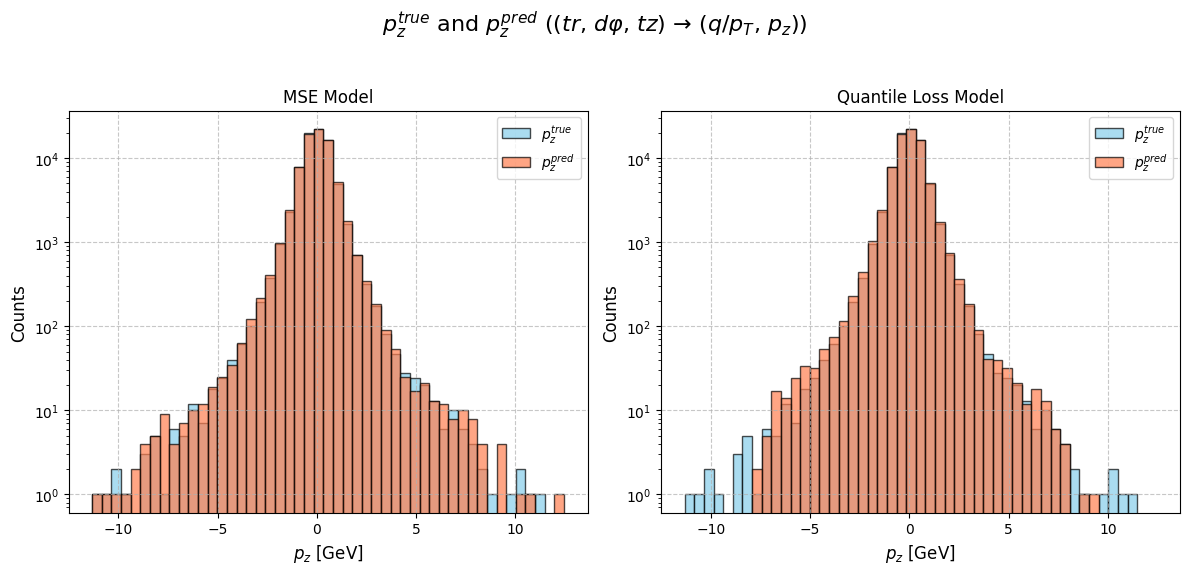

In [38]:
def plot_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"${var}^{{true}}$ and ${var}^{{pred}}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"${var}$" + (" [GeV]" if var.startswith("p") else "")
        filename = (
            f"{variable_filenames[var]}_true_and_{variable_filenames[var]}_pred.png"
        )
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(pi_true_values), min(pi_pred_mse_list), min(pi_pred_qloss_list)),
            max(
                max(pi_true_values),
                max(pi_pred_mse_list),
                max(pi_pred_qloss_list),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_mse_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_qloss_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_pi(target_labels=[variable_labels[var] for var in config["output_variables"]])

In [39]:
def plot_pi_cdf(target_labels):
    """Plot CDF of p_T and p_z"""
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"CDF of ${var}^{{true}}$ and ${var}^{{pred}}$"
        title += title_suffix

        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        xlabel = f"CDF of ${var}$"
        filename = (
            f"{variable_filenames[var]}_true_and_{variable_filenames[var]}_pred_cdf.png"
        )
        filename = output_dir / filename

        # Import necessary CDF function
        from scipy.stats import norm

        pi_true_values_cdf = np.sort(pi_true_values)
        pi_pred_mse_list_cdf = np.sort(pi_pred_mse_list)
        pi_pred_qloss_list_cdf = np.sort(pi_pred_qloss_list)

        pi_true_values_cdf_ = np.linspace(0, 1, len(pi_true_values_cdf))
        pi_pred_mse_list_cdf_ = np.linspace(0, 1, len(pi_pred_mse_list_cdf))
        pi_pred_qloss_list_cdf_ = np.linspace(0, 1, len(pi_pred_qloss_list_cdf))

        pi_true_values_cdf = norm.ppf(pi_true_values_cdf_)
        pi_pred_mse_list_cdf = norm.ppf(pi_pred_mse_list_cdf_)
        pi_pred_qloss_list_cdf = norm.ppf(pi_pred_qloss_list_cdf_)

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            min(min(pi_true_values), min(pi_pred_mse_list), min(pi_pred_qloss_list)),
            max(
                max(pi_true_values),
                max(pi_pred_mse_list),
                max(pi_pred_qloss_list),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_mse_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            pi_true_values,
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            pi_pred_qloss_list,
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


# plot_pi_cdf(target_labels=[variable_labels[var] for var in config['output_variables']])

/tmp/ipykernel_102638/3844298029.py:23: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_true_values)),
/tmp/ipykernel_102638/3844298029.py:24: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_pred_mse_list)),
/tmp/ipykernel_102638/3844298029.py:25: RuntimeWarning: invalid value encountered in log10
  max(np.log10(pi_pred_qloss_list)),
/tmp/ipykernel_102638/3844298029.py:33: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_true_values),
/tmp/ipykernel_102638/3844298029.py:41: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_pred_mse_list),
/tmp/ipykernel_102638/3844298029.py:58: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_true_values),
/tmp/ipykernel_102638/3844298029.py:66: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_pred_qloss_list),


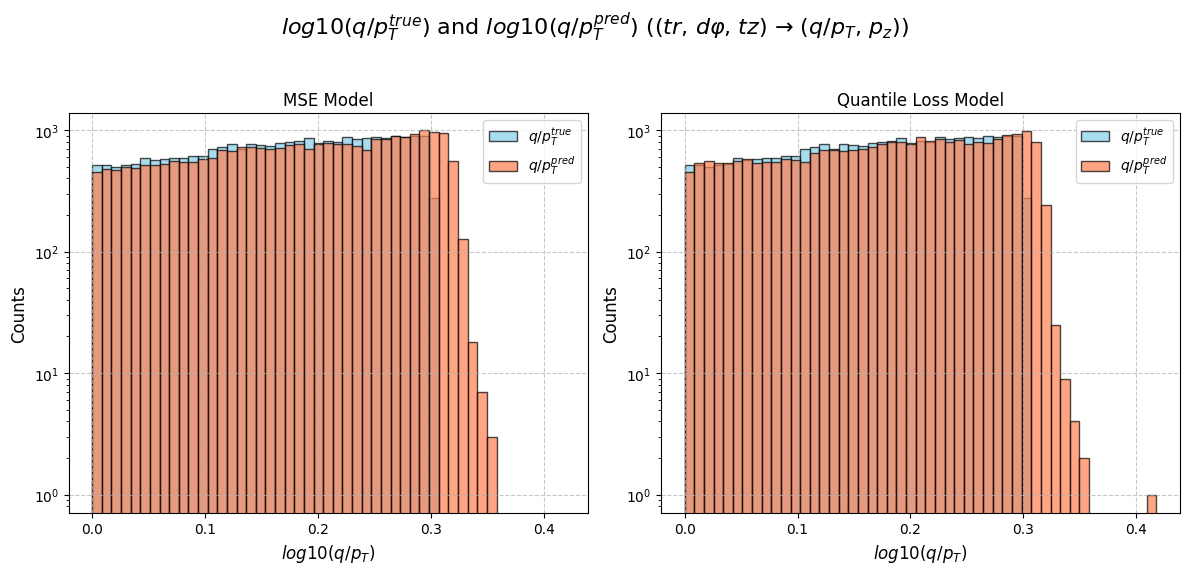

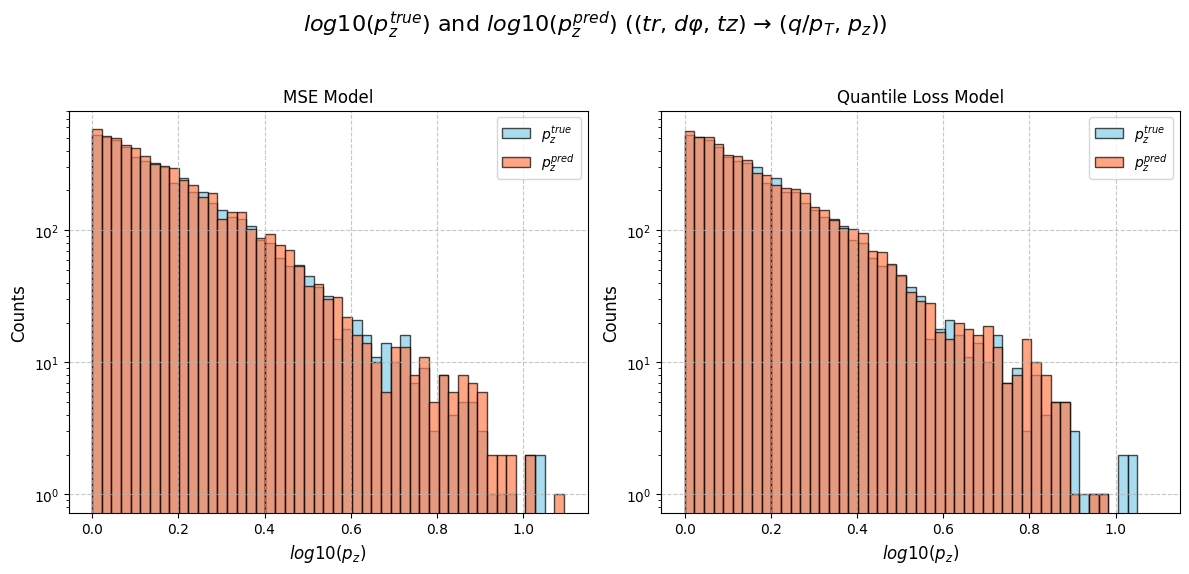

In [40]:
def plot_log10_pi(target_labels):
    for var_index, var in enumerate(target_labels):
        pi_true_values = np.array(p_true_list)[:, var_index]
        pi_pred_mse_list = np.array(p_pred_mse_list)[:, var_index]
        pi_pred_qloss_list = np.array(p_pred_qloss_list)[:, var_index]

        title = f"$log10({var}^{{true}})$ and $log10({var}^{{pred}})$"
        title += title_suffix

        xlabel = f"$log10({var})$"
        true_label = f"${var}^{{true}}$"
        pred_label = f"${var}^{{pred}}$"
        filename = f"log10_{variable_filenames[var]}_true_and_log10_{variable_filenames[var]}_pred.png"
        filename = output_dir / filename

        # Plot pt_true and pt_pred
        plt.figure(figsize=(12, 6))
        plt.suptitle(title, fontsize=16)

        bins = np.linspace(
            0,
            max(
                max(np.log10(pi_true_values)),
                max(np.log10(pi_pred_mse_list)),
                max(np.log10(pi_pred_qloss_list)),
            ),
            50,
        )

        # MSE Model
        plt.subplot(1, 2, 1)
        plt.hist(
            np.log10(pi_true_values),
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            np.log10(pi_pred_mse_list),
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("MSE Model")
        plt.legend()

        # Qloss
        plt.subplot(1, 2, 2)
        plt.hist(
            np.log10(pi_true_values),
            bins=bins,
            alpha=0.7,
            label=true_label,
            color="skyblue",
            edgecolor="black",
        )
        plt.hist(
            np.log10(pi_pred_qloss_list),
            bins=bins,
            alpha=0.7,
            label=pred_label,
            color="coral",
            edgecolor="black",
        )
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel("Counts", fontsize=12)
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.title("Quantile Loss Model")
        plt.legend()

        sync_plot_limits()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(filename, format="png")
        plt.show()


plot_log10_pi(
    target_labels=[variable_labels[var] for var in config["output_variables"]]
)

In [41]:
import torch.nn.functional as F
from sklearn.utils import resample
from scipy.stats import bootstrap


def evaluate_models():
    # Initialize lists to store the MAE values
    m_transf_mae_pt = []
    m_transf_mae_pz = []
    q_transf_mae_pt = []
    q_transf_mae_pz = []

    pt_conf_mae_list = []
    batch_limit = 10
    epochs = 1
    for epoch in tqdm(range(epochs)):
        with torch.no_grad():
            for i, (input, mask, target) in enumerate(tqdm(tl)):
                if i >= batch_limit:
                    break
                # Transformer MSE
                pred1 = transf_mse_model(input, mask=mask)
                pt_mae1 = F.l1_loss(pred1[:, 0], target[:, 0])
                pz_mae1 = F.l1_loss(pred1[:, 1], target[:, 1])

                m_transf_mae_pt.append(pt_mae1.item())
                m_transf_mae_pz.append(pz_mae1.item())

                # Transformer Qloss
                pred2 = qloss_transf_tt_model(input, mask=mask)
                pt_mae2 = F.l1_loss(pred2[:, 0], target[:, 0])
                pz_mae2 = F.l1_loss(pred2[:, 1], target[:, 1])

                q_transf_mae_pt.append(pt_mae2.item())
                q_transf_mae_pz.append(pz_mae2.item())

                # conformal fitt squares
                # pt_conf_mae = conformal_mae(input, target)
                # pt_conf_mae_list.append(pt_conf_mae.item())

    # Convert lists to numpy arrays
    m_transf_mae_pt = np.array(m_transf_mae_pt)
    q_transf_mae_pt = np.array(q_transf_mae_pt)
    m_transf_mae_pz = np.array(m_transf_mae_pz)
    q_transf_mae_pz = np.array(q_transf_mae_pz)
    # pt_conf_mae_list = np.array(pt_conf_mae_list)

    def calculate_ci(data, confidence=0.95, n_resamples=1000):
        res = bootstrap(
            (data,),
            np.mean,
            confidence_level=confidence,
            n_resamples=n_resamples,
            method="percentile",
            random_state=42,
        )
        mean = np.mean(data)
        ci_lower = res.confidence_interval.low
        ci_upper = res.confidence_interval.high
        delta = (ci_upper - mean) / 2
        return mean, delta

    # confidence intervals
    transf_mse_pt_mean, transf_mse_pt_delta = calculate_ci(m_transf_mae_pt)
    transf_q_pt_mean, transf_q_pt_delta = calculate_ci(q_transf_mae_pt)
    transf_mse_pz_mean, transf_mse_pz_delta = calculate_ci(m_transf_mae_pz)
    transf_q_pz_mean, transf_q_pz_delta = calculate_ci(q_transf_mae_pz)
    # pt_conf_mean, pt_conf_delta = calculate_ci(pt_conf_mae_list)

    print(
        f"Transformer MSE PT MAE: {transf_mse_pt_mean:.4f} ± {transf_mse_pt_delta:.4f}"
    )
    print(f"Transformer Qloss PT MAE: {transf_q_pt_mean:.4f} ± {transf_q_pt_delta:.4f}")
    print(
        f"Transformer MSE PZ MAE: {transf_mse_pz_mean:.4f} ± {transf_mse_pz_delta:.4f}"
    )
    print(f"Transformer Qloss PZ MAE: {transf_q_pz_mean:.4f} ± {transf_q_pz_delta:.4f}")
    # print(f"Conformal MAE: {pt_conf_mean:.4f} ± {pt_conf_delta:.4f}")

    # Save the results to a file
    results = {}
    results["p_T"] = {
        "mse": (transf_mse_pt_mean, transf_mse_pt_delta),
        "qloss": (transf_q_pt_mean, transf_q_pt_delta),
    }
    results["p_z"] = {
        "mse": (transf_mse_pz_mean, transf_mse_pz_delta),
        "qloss": (transf_q_pz_mean, transf_q_pz_delta),
    }
    # results["conformal"] = (pt_conf_mean, pt_conf_delta)

    with open(output_dir / "mae_results.json", "w") as f:
        json.dump(results, f)


evaluate_models()

  0%|          | 0/1 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Transformer MSE PT MAE: 0.0878 ± 0.0034
Transformer Qloss PT MAE: 0.0622 ± 0.0039
Transformer MSE PZ MAE: 0.0829 ± 0.0233
Transformer Qloss PZ MAE: 0.0574 ± 0.0131


: 

Transformer MSE PT MAE: 0.4409 ± 0.1944
Transformer Qloss PT MAE: 0.1949 ± 0.0778
Transformer MSE PZ MAE: 1.3537 ± 0.5189
Transformer Qloss PZ MAE: 0.7749 ± 0.2834

Transformer MSE PT MAE: 0.5884 ± 0.2166
Transformer Qloss PT MAE: 0.1474 ± 0.0739
Transformer MSE PZ MAE: 1.3716 ± 0.3525
Transformer Qloss PZ MAE: 0.6085 ± 0.1636

Transformer MSE PT MAE: 0.0869 ± 0.0125

Transformer Qloss PT MAE: 0.0959 ± 0.0147

Transformer MSE PZ MAE: 0.0543 ± 0.0083

Transformer Qloss PZ MAE: 0.0512 ± 0.0085

In [ ]:
from tbparse import SummaryReader


def plot_tensorboard(log_dir: Path):
    reader = SummaryReader(log_dir, extra_columns={"dir_name"}, pivot=False)
    # reader = SummaryReader(log_dir)
    df = reader.scalars
    print(df)

    df["unique_tag"] = df["dir_name"] + "/" + df["tag"]

    # Get the unique tags
    unique_tags = df["tag"].unique()

    print(unique_tags)

    # Extract values for each tag
    unique_tags_dfs = {}
    for tag in unique_tags:
        unique_tags_dfs[tag] = df[df["tag"] == tag].reset_index(drop=True)

        print(unique_tags_dfs[tag])

    for tag in unique_tags:
        # if not "loss" in unique_tags_dfs[tag]
        plt.figure()
        for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
            dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

            dir_df = unique_tags_dfs[tag][dir_name_sel]
            # Group by step and take the mean and std
            dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
            # dir_df.columns = dir_df.columns.droplevel(0)
            dir_df.reset_index(inplace=True)
            plt.errorbar(
                x=dir_df["step"],
                y=dir_df["value"]["mean"],
                label=dir_name,
                alpha=0.7,
                yerr=dir_df["value"]["std"],
            )
        # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
        # plt.title(tag)
        plt.xlabel("Step")
        plt.ylabel(tag.capitalize())
        plt.legend()
        plt.grid(True)
        log_name = log_dir.name
        plt.savefig(output_dir / (tag + "_" + log_name + ".png"), format="png")

    tag = "loss"
    plt.figure()
    for dir_name in unique_tags_dfs[tag]["dir_name"].unique():
        dir_name_sel = unique_tags_dfs[tag]["dir_name"] == dir_name

        dir_df = unique_tags_dfs[tag][dir_name_sel]
        # Group by step and take the mean and std
        dir_df = dir_df.groupby("step").agg({"value": ["mean", "std"]})
        # dir_df.columns = dir_df.columns.droplevel(0)
        dir_df.reset_index(inplace=True)
        plt.errorbar(
            x=dir_df["step"],
            y=dir_df["value"]["mean"],
            label=dir_name,
            alpha=0.7,
            yerr=dir_df["value"]["std"],
        )
    # sns.lineplot(data=unique_tags_dfs[tag], x="step", y="value")
    # plt.title(tag)
    plt.xlabel("Step")
    plt.ylabel(tag.capitalize())
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)
    log_name = log_dir.name
    plt.savefig(output_dir / ("loss_log_log_" + log_name + ".png"), format="png")
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

log_dir = mse_trans_tml_dir
plot_tensorboard(log_dir)

In [ ]:
log_dir = qloss_tml_trasf_dir
plot_tensorboard(log_dir)

In [ ]:
batch_limit = 10
epochs = 1
attention_sum_mse = []
for epoch in tqdm(range(epochs)):
    with torch.no_grad():
        for i, (input, _, target) in enumerate(tqdm(tl)):
            if i >= batch_limit:
                break
            # Transformer MSE
            # Output shape: (n_layers, batch_size, n_heads, seq_len, seq_len)
            pred1 = transf_mse_model.get_attention_maps(input)
            # print(pred1.shape)
            # print(pred1)
            print(pred1[0].shape)
            # pt_mae1 = F.l1_loss(pred1[:, 0], target[:, 0])
            # pz_mae1 = F.l1_loss(pred1[:, 1], target[:, 1])

            # m_transf_mae_pt.append(pt_mae1.item())
            # m_transf_mae_pz.append(pz_mae1.item())

            # Add the attention maps to the attention_sum
            if len(attention_sum_mse) == 0:
                # Initialize the attention_sum to zeros with shape torch.Size([32, 4, 18, 18])
                # attention_sum_mse = [torch.zeros']

                attention_sum_mse = [torch.zeros_like(att) for att in pred1]
            for j, att in enumerate(pred1):
                attention_sum_mse[j] += att

            # Transformer Qloss
            pred2 = qloss_transf_tt_model.get_attention_maps(input)
            # print(pred2.shape)
            # print(pred2)
            # pt_mae2 = F.l1_loss(pred2[:, 0], target[:, 0])
            # pz_mae2 = F.l1_loss(pred2[:, 1], target[:, 1])

            # q_transf_mae_pt.append(pt_mae2.item())
            # q_transf_mae_pz.append(pz_mae2.item())

            # conformal fitt squares
            # pt_conf_mae = conformal_mae(input, target)
            # pt_conf_mae_list.append(pt_conf_mae.item())

In [ ]:
# Plot the attention maps
plt.figure(figsize=(12, 6))
plt.suptitle("Attention Maps", fontsize=16)

pred1 = attention_sum_mse

# MSE Model
for layer in range(len(pred1)):
    for i in range(pred1[0].shape[1]):
        plt.subplot(len(pred1), pred1[0].shape[1], layer * pred1[0].shape[1] + i + 1)
        # Plot the head with matplotlib
        # Do a mean over the batch size
        mean_attention = pred1[layer].mean(dim=0)[i].numpy()
        print(pred1[layer].mean(dim=0).shape)
        plt.imshow(mean_attention, cmap="viridis", origin="lower")
        # Add the colorbar
        plt.colorbar()
        plt.title(f"Layer {layer}, Head {i}")
plt.title("MSE Model")

# # Qloss
# plt.subplot(1, 2, 2)
# # Plot the first
# plt.imshow(pred2[0][0, 0].numpy(), cmap="viridis", origin="lower")
# plt.title("Quantile Loss Model")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [41]:
all_inputs = []
all_targets = []
all_input_masks = []
batch_limit = 10
for i, (input, masks, target) in enumerate(tqdm(tl)):
    # Reshape the input and target to shape (n_features, batch_size, seq_len)
    input = input.permute(2, 0, 1)
    target = target.permute(1, 0)

    all_inputs.append(input)
    all_targets.append(target)
    all_input_masks.append(masks)
    if i >= batch_limit:
        break

0it [00:00, ?it/s]

In [42]:
# print(all_inputs[0][0])

In [43]:
# Concatenate all the inputs and targets
all_inputs = torch.cat(all_inputs, dim=2)
all_targets = torch.cat(all_targets, dim=1)
all_input_masks = torch.cat(all_input_masks, dim=1)


# Reshape the inputs to shape (n_features, batch_size * seq_len)
all_inputs = all_inputs.view(all_inputs.shape[0], -1)

# Reshape the masks to shape (batch_size * seq_len)
all_input_masks = all_input_masks.view(-1)

print(all_inputs.shape)
print(all_targets.shape)
print(all_input_masks.shape)

torch.Size([3, 5408])
torch.Size([2, 352])
torch.Size([5408])


In [44]:
# # Print input and mask side by side
# for i in range(all_inputs.shape[1]):
#     print(all_inputs[:, i], all_input_masks[i])
#     if i == 100:
#         break

In [45]:
# Keep input only where mask is True
all_inputs = all_inputs[:, all_input_masks]
print(all_inputs.shape)

torch.Size([3, 4074])


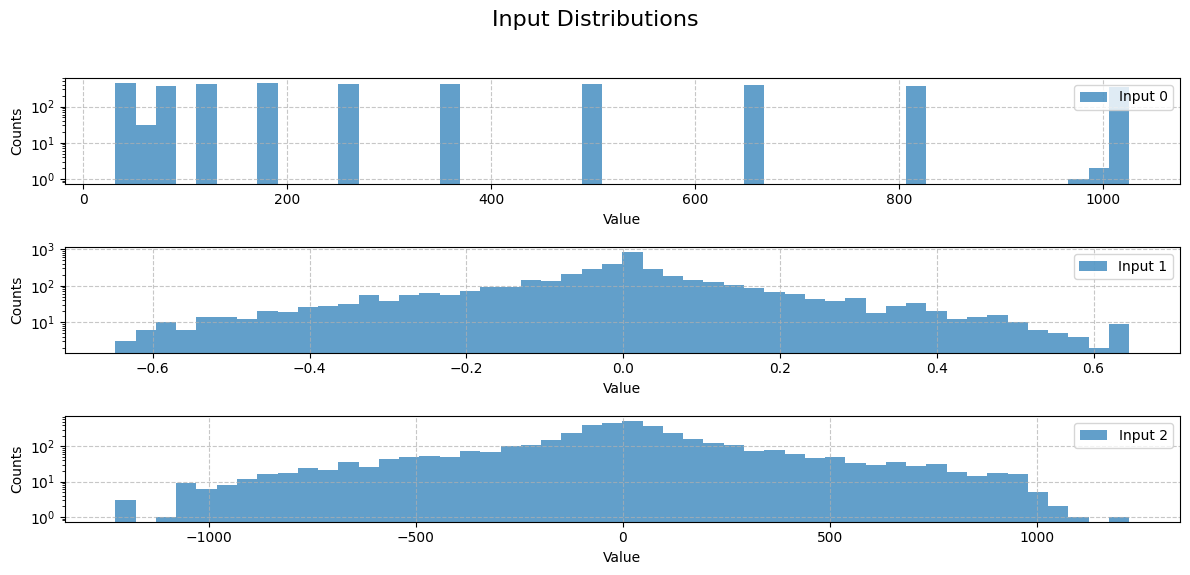

In [46]:
# Plot the distribution of the inputs
plt.figure(figsize=(12, 6))
plt.suptitle("Input Distributions", fontsize=16)

# Plot the inputs
for i in range(all_inputs.shape[0]):
    plt.subplot(all_inputs.shape[0], 1, i + 1)
    plt.hist(all_inputs[i].numpy().flatten(), bins=50, alpha=0.7, label=f"Input {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "input_distributions.png", format="png")
plt.show()

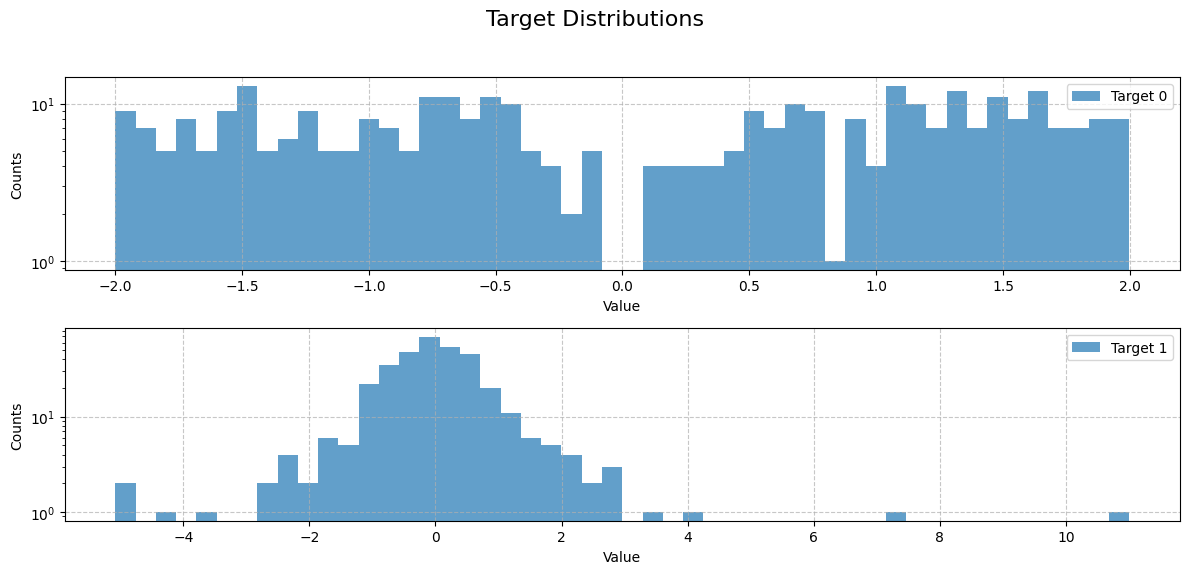

In [47]:
# Plot the distribution of the targets
plt.figure(figsize=(12, 6))
plt.suptitle("Target Distributions", fontsize=16)

# Plot the targets
for i in range(all_targets.shape[0]):
    plt.subplot(all_targets.shape[0], 1, i + 1)
    plt.hist(all_targets[i].numpy().flatten(), bins=50, alpha=0.7, label=f"Target {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(output_dir / "target_distributions.png", format="png")
plt.show()